# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 11.05.2026

Мягкий дедлайн: 25.05.2026 23:59 MSK

Жёсткий дедлайн: 31.05.2026 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb
* Модуль boosting.py

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, поэтому придется научиться им пользоваться

In [1]:
from warnings import filterwarnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

Мы будем работать с датасетом по предсказанию гендера. Никакие фичи мы придумывать не будем, но если вам интересно, в датасете имеется:

- region — регион, в котором проводили опрос
- age — возраст опрошенного
- year — год опроса
- race — этническая принадлежность
- sch — количество классов образования
- empstat — статус трудоустройства
- occ — код профессии
- ind — код индустрии, в которой человек работает
- annhrs — число часов работы в год
- hrwage — почасовая оплата
- icwage — суммарная оплата в год
- occupation — должность

Целевая метрика ROC-AUC, потому что мы непритязательны и это не фокус этой домашки



In [2]:
df = pd.read_parquet("hw6_dataset.pq")

X = df.drop("sex", axis=1)
y = df["sex"]

Пока что мы временно выкинем колонку с должностью, но мы к ней обязательно вернемся

Разделим на обучающую, валидационную и тестовую выборки по годам, чтобы предсказывать будущее, а не прошлое

In [3]:
X_train = X[X["year"] < 2011].drop("occupation", axis=1).values
y_train = y[X["year"] < 2011].values

X_valid = X[X["year"] == 2011].drop("occupation", axis=1).values
y_valid = y[X["year"] == 2011].values

X_test = X[X["year"] == 2013].drop("occupation", axis=1).values
y_test = y[X["year"] == 2013].values

X_train.shape, X_valid.shape, X_test.shape

((236640, 10), (53857, 10), (53790, 10))

Домашнее задание имеет нелинейную структуру. В нём есть <font color='lightcoral'>📌 **обязательные**</font> части, без которых будет тяжко <font color='lightcoral'>**(6 баллов)**</font>, и целая куча 💠 **опциональных**, которыми можно добить оценку до 10, делайте то, что нравится больше! **Музыкальный бонус** идёт отдельно, за него можно получить ещё 0.5 балла.

---

## 📌 Задание 1. Базовый градиентный бустинг (4 балла)

Это задание <font color='lightcoral'>**📌 обязательное**</font>, без него домашка не имеет смысла! Ещё раз обращаем внимание, что **опциональные** задания помечены 💠

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='lightcoral'>**вопросы**</font> должен быть <font color='lightcoral'>**ответ**</font>. В заданиях, где нужно делать параметры, часто есть референсы из других библиотек. На случай, если объяснение из ноутбука непонятно, советуем обратиться к соответствующей документации и пощупать, как это делается там

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Существующие параметры:
- `base_model_class` — класс базовой модели нашего бустинга
- `base_model_params` — словарь с гиперпараметрами для базовой модели
- `n_estimators` — какое количество базовых моделей нужно обучить
- `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$
- `random_state`— в роли рандом стейта
- `verbose` — для тех, кому не нравится загадочность, можно включить и увидеть, сколько еще ждать конца обучения

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

1. Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`).
2. После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах).
3. После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

#### `partial_fit`

В `partial_fit` передаются данные `X: np.ndarray, y: np.ndarray` для одного шага бустинга: обучаем следующую базовую модель на антиградиенте и обновляем ансамбль.

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

In [4]:
%load_ext autoreload

In [5]:
%autoreload 2

from boosting import Boosting

### Проверка кода

In [6]:
boosting = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=69, # не забывайте фиксировать, пожалуйста
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]

Train ROC-AUC 0.8013
Valid ROC-AUC 0.7247
Test ROC-AUC 0.7196


---

## Задание 2. Имплементация гиперпараметров (📌 1 балл |💠 8.25 балла)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации.

В этом пункте мы будем делать кучу самых разных гиперпараметров, каждый из них прекрасен по-своему, но полноценно их эффект получится ощутить лишь на этапе их перебора (кроме, пожалуй, `rsm`), поэтому делать третью часть до второй не рекомендуется

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону. Для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**гарантии, что дефолтные параметры подойдут, нет**</font>. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотреть именно на них

### 📌 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете в дальнейшем делать для трейна, нужно будет повторить на валидации

Добавьте в вашу модель:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из `model.history`
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из `model.history`

И конкретно в метод `model.fit`:
- `eval_set: tuple[np.ndarray] | None = None` — валидационная выборка `X_valid: np.ndarray, y_valid: np.ndarray`, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус `early_stopping_rounds`, т.е самой лучшей, после которой качество только падает

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td colspan="3" align="center"><code>early_stopping_rounds</code>, <code>eval_set</code></td>
</tr>
</table>

</div>

Продемонстрируйте, что все работает

In [7]:
# without es
b_full = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=300,
    learning_rate=0.1,
    random_state=69,
)
b_full.fit(X_train, y_train)

In [8]:
# with es
b_es = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=300,
    learning_rate=0.1,
    random_state=69,
    early_stopping_rounds=15,
    eval_metric='val_roc_auc',
)
b_es.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

In [9]:
print(f'Без ES: построено {len(b_full.models)} деревьев')
print(f'С ES: обучено {len(b_es.history["train_loss"])}, оставлено {len(b_es.models)} (лучший шаг)')

print()
print(
    f'{"":<18}{"train":>10}{"valid":>10}{"test":>10}'
)
print(
    f'{"без ES":<18}{b_full.score(X_train, y_train):>10.4f}'
    f'{b_full.score(X_valid, y_valid):>10.4f}{b_full.score(X_test, y_test):>10.4f}'
)
print(
    f'{"ES + best":<18}{b_es.score(X_train, y_train):>10.4f}'
    f'{b_es.score(X_valid, y_valid):>10.4f}{b_es.score(X_test, y_test):>10.4f}'
)

Без ES: построено 300 деревьев
С ES: обучено 43, оставлено 28 (лучший шаг)

                       train     valid      test
без ES                0.8501    0.7426    0.7350
ES + best             0.8035    0.7299    0.7245


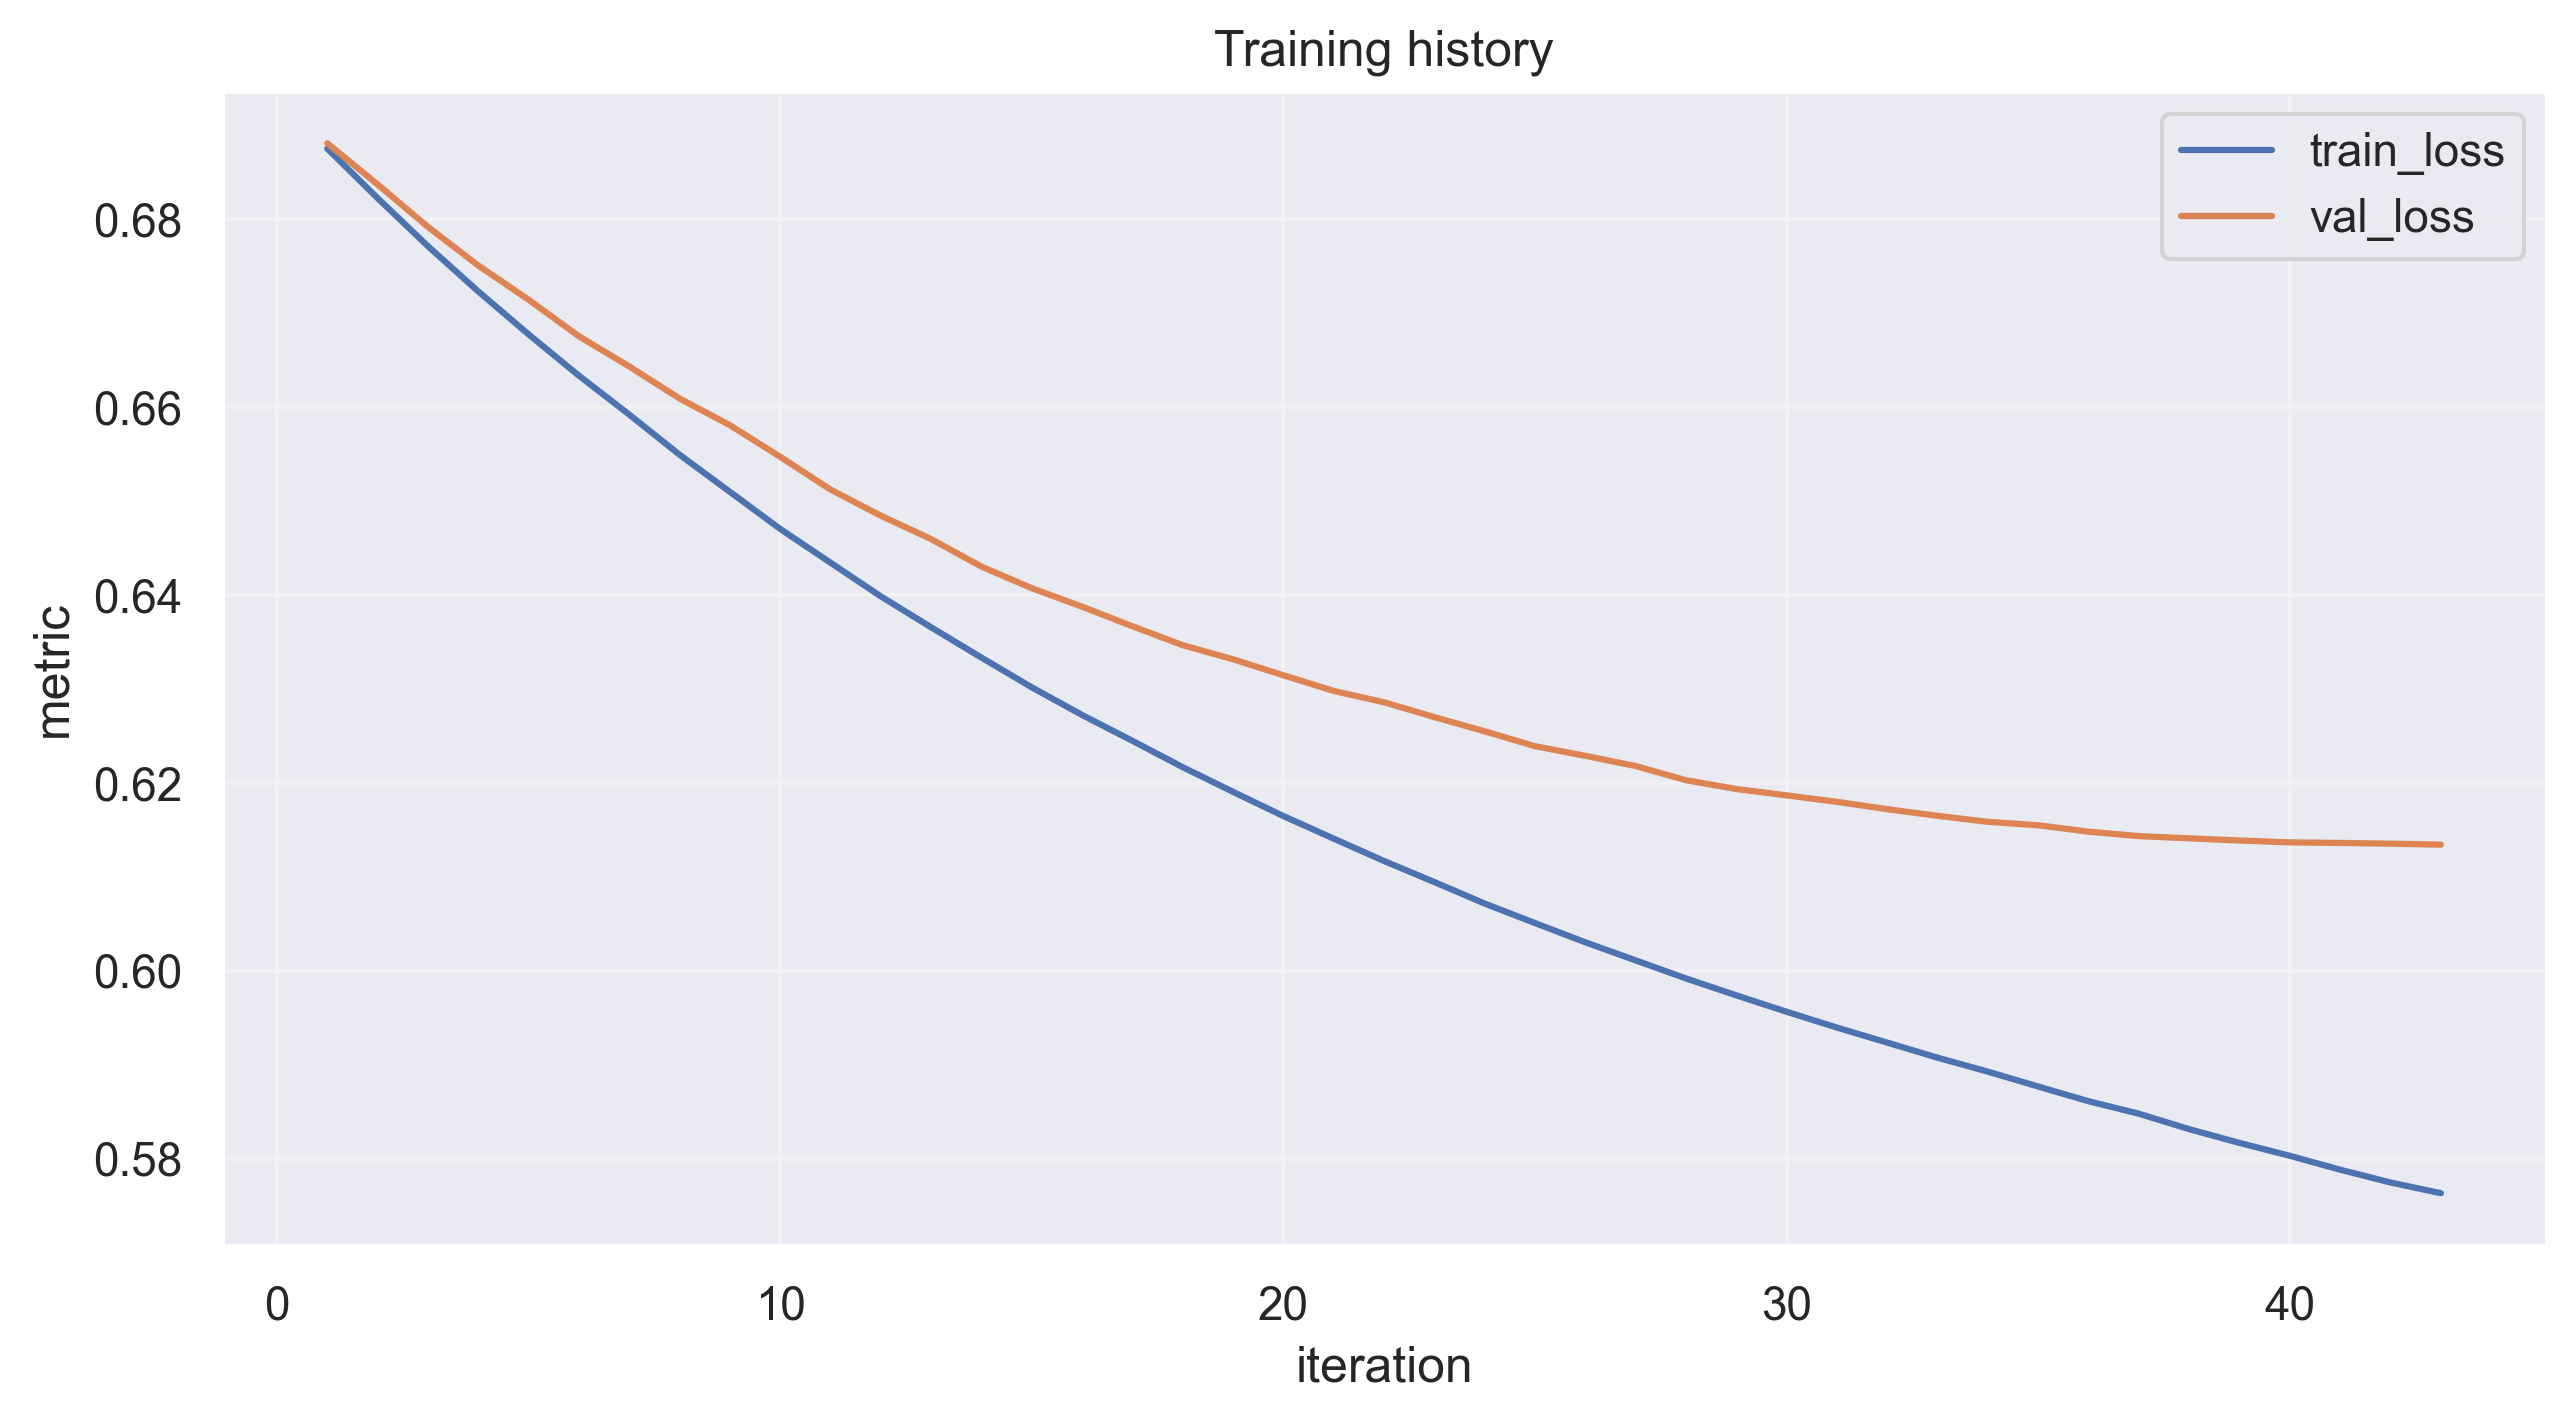

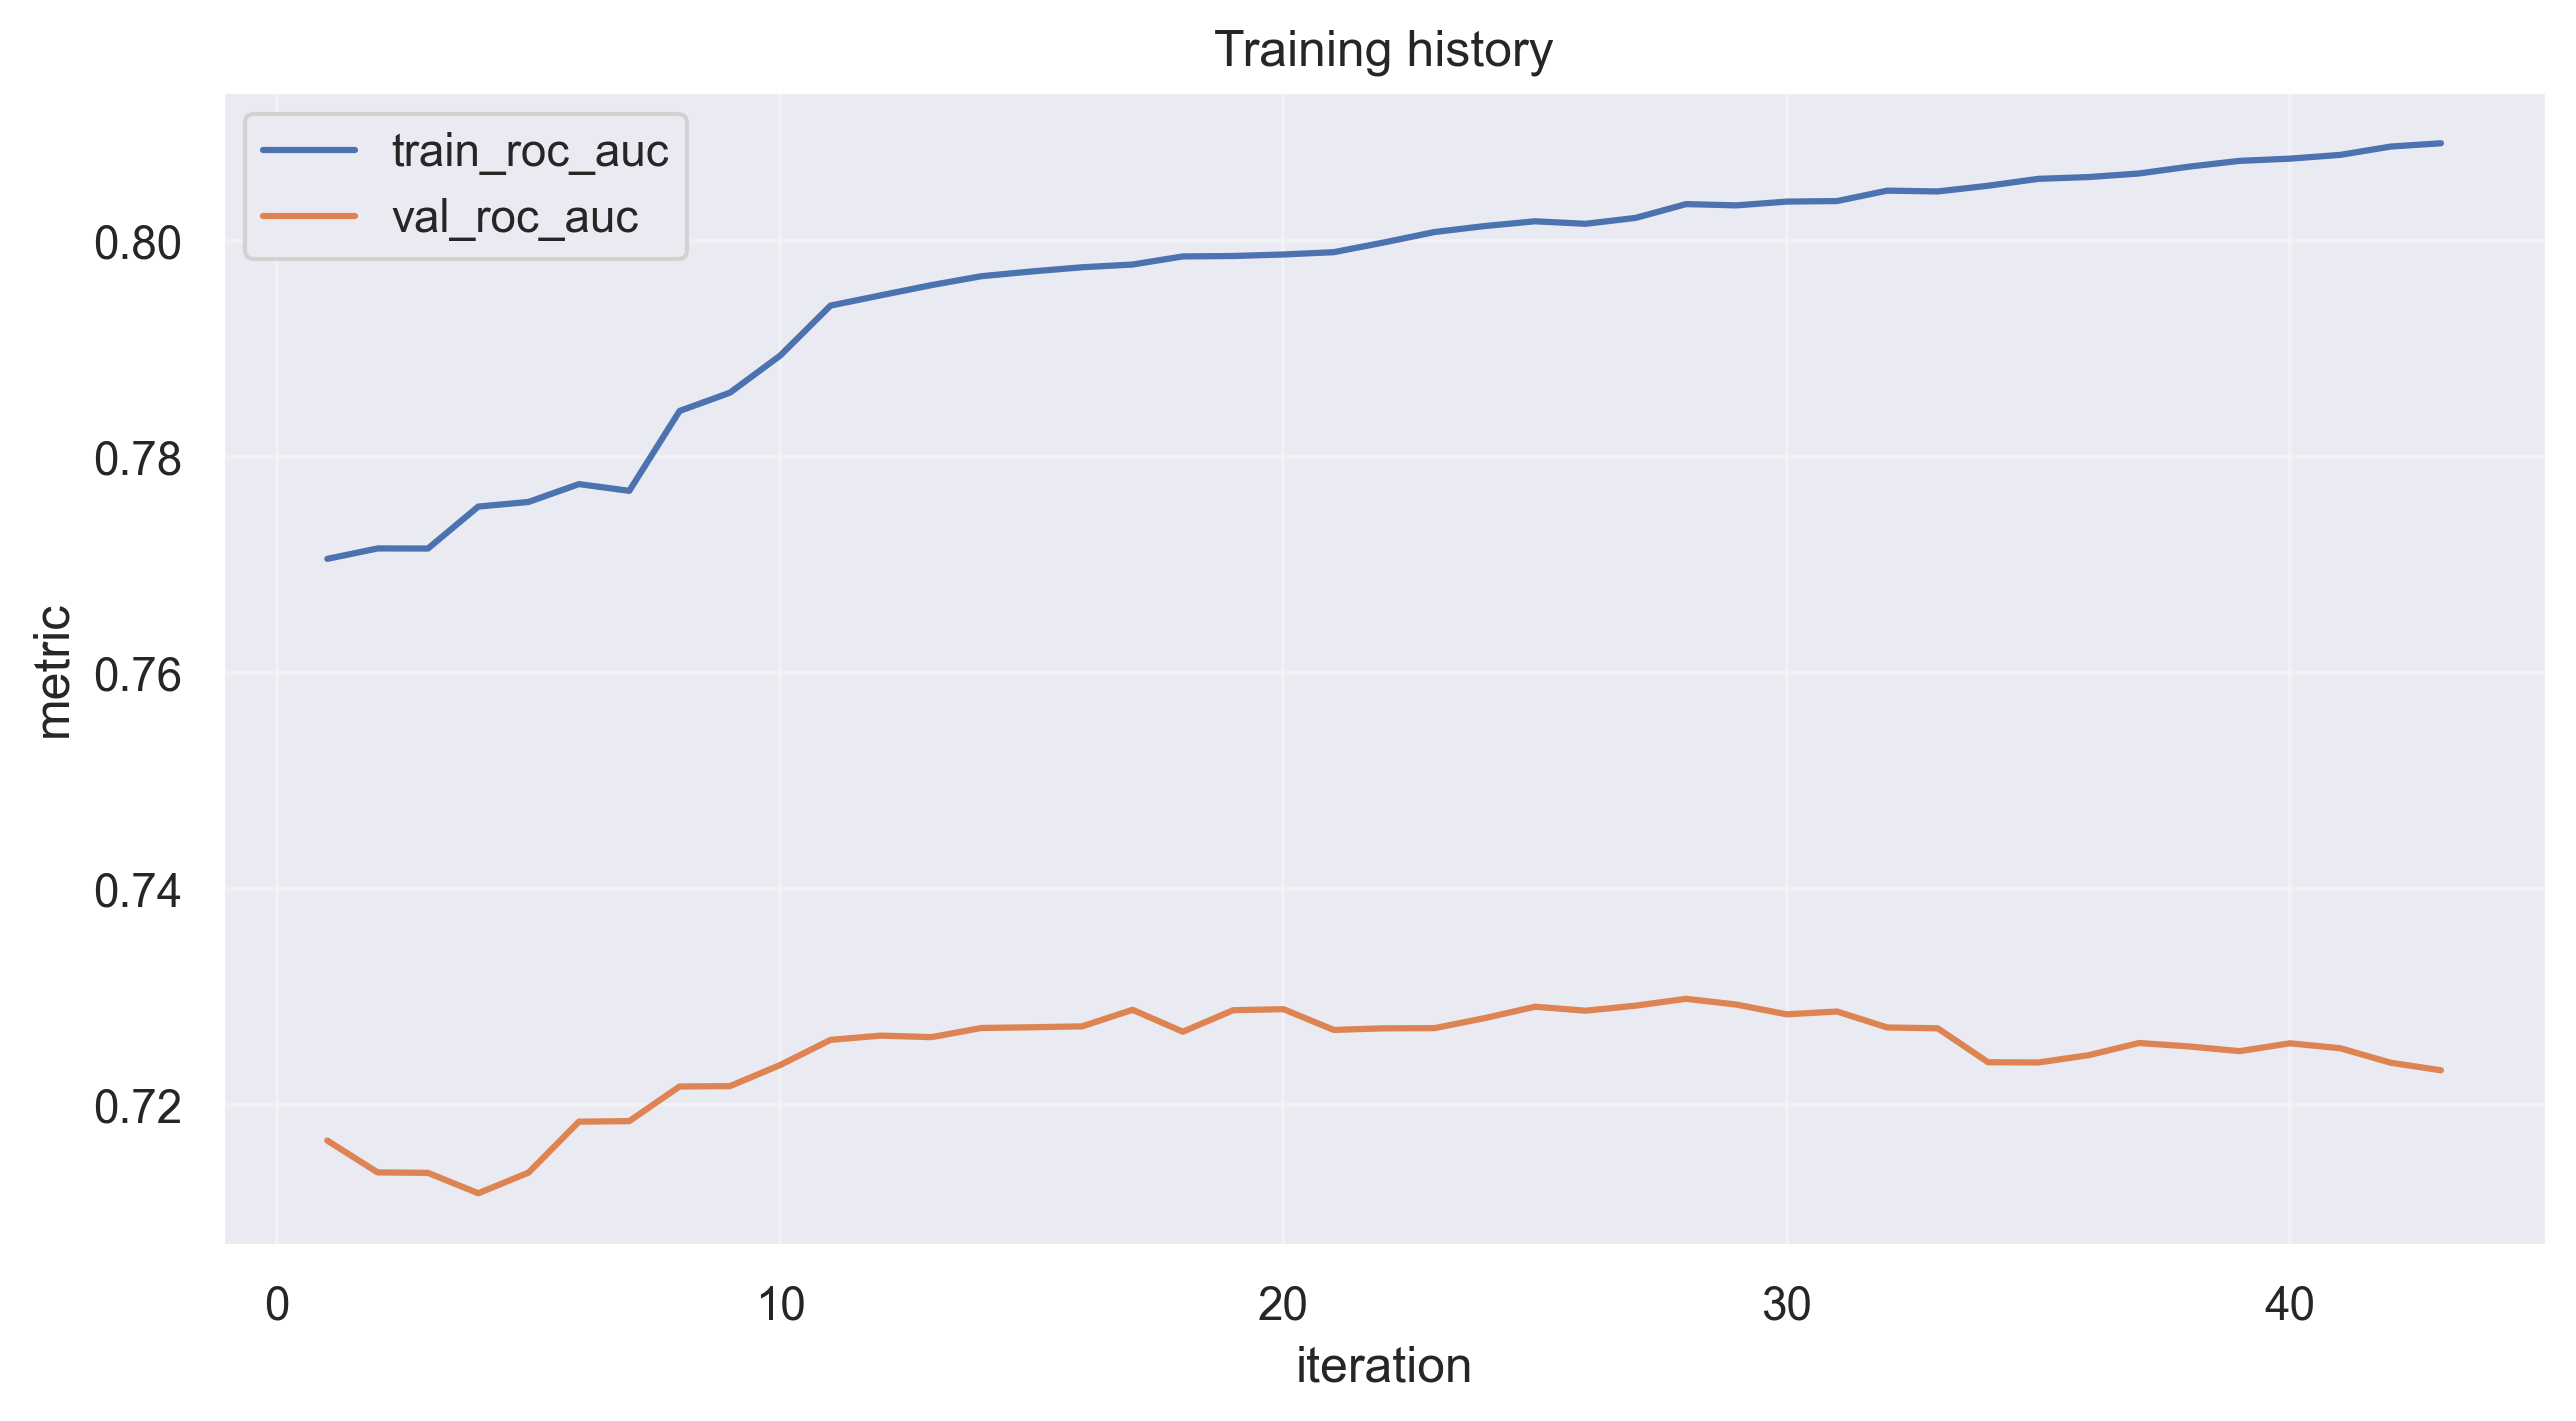

In [10]:
b_es.plot_history(['train_loss', 'val_loss'])
b_es.plot_history(['train_roc_auc', 'val_roc_auc'])

### 📌 2.2. Категории 2.0 (0.5 балла)

Пока что для простоты картины мы игнорировали категориальные признаки. <font color='#c4bf0a'>**CatBoost**</font> в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий, который мы попробуем повторить

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$


Добавьте в модель вот это:
- `cat_features: Iterable | None` — категориальные признаки для кодирования
- `_cat_fit(self, X: np.array, y: np.ndarray)` — внутренний метод для построения счетчиков
- `_cat_transform(self, X: np.ndarray)` — внутренний метод для применения счетчиков

Лмбо сделайте энкодер отдельным классом с аналогичными методами `fit` и `transform`, это даже лучше. Его нужно прогнать всего раз для каждой из выборок

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>cat_features</code></td>
</tr>
</table>

</div>

Закодируйте переменные, которые вы хотите считать категориальными, с помощью счётчиков (готовые реализации брать нельзя) и покажите эффект. Помните, что все должно быть векторизовано и красиво

In [11]:
# вернем occupation туда, где ему самое место, но это не единственная кат фича!

X_train = X[X["year"] < 2011].values
X_valid = X[X["year"] == 2011].values
X_test = X[X["year"] == 2013].values

In [12]:
feature_names = X.columns.tolist()
cat_feature_names = ['region', 'race', 'empstat', 'occ', 'occupation']
cat_features = [feature_names.index(name) for name in cat_feature_names]
print('cat_features:', dict(zip(cat_feature_names, cat_features)))

cat_features: {'region': 0, 'race': 3, 'empstat': 5, 'occ': 6, 'occupation': 10}


In [13]:
boosting = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=200,
    learning_rate=0.1,
    random_state=69,
    cat_features=cat_features,
    ordered_encoding=False,
    early_stopping_rounds=15,
    eval_metric='val_roc_auc',
)
boosting.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

In [14]:
print(f'Шагов обучено: {len(boosting.history["train_loss"])}, оставлено моделей: {len(boosting.models)}')
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test  ROC-AUC {boosting.score(X_test,  y_test):.4f}')

Шагов обучено: 24, оставлено моделей: 9
Train ROC-AUC 0.8732
Valid ROC-AUC 0.8069
Test  ROC-AUC 0.8008


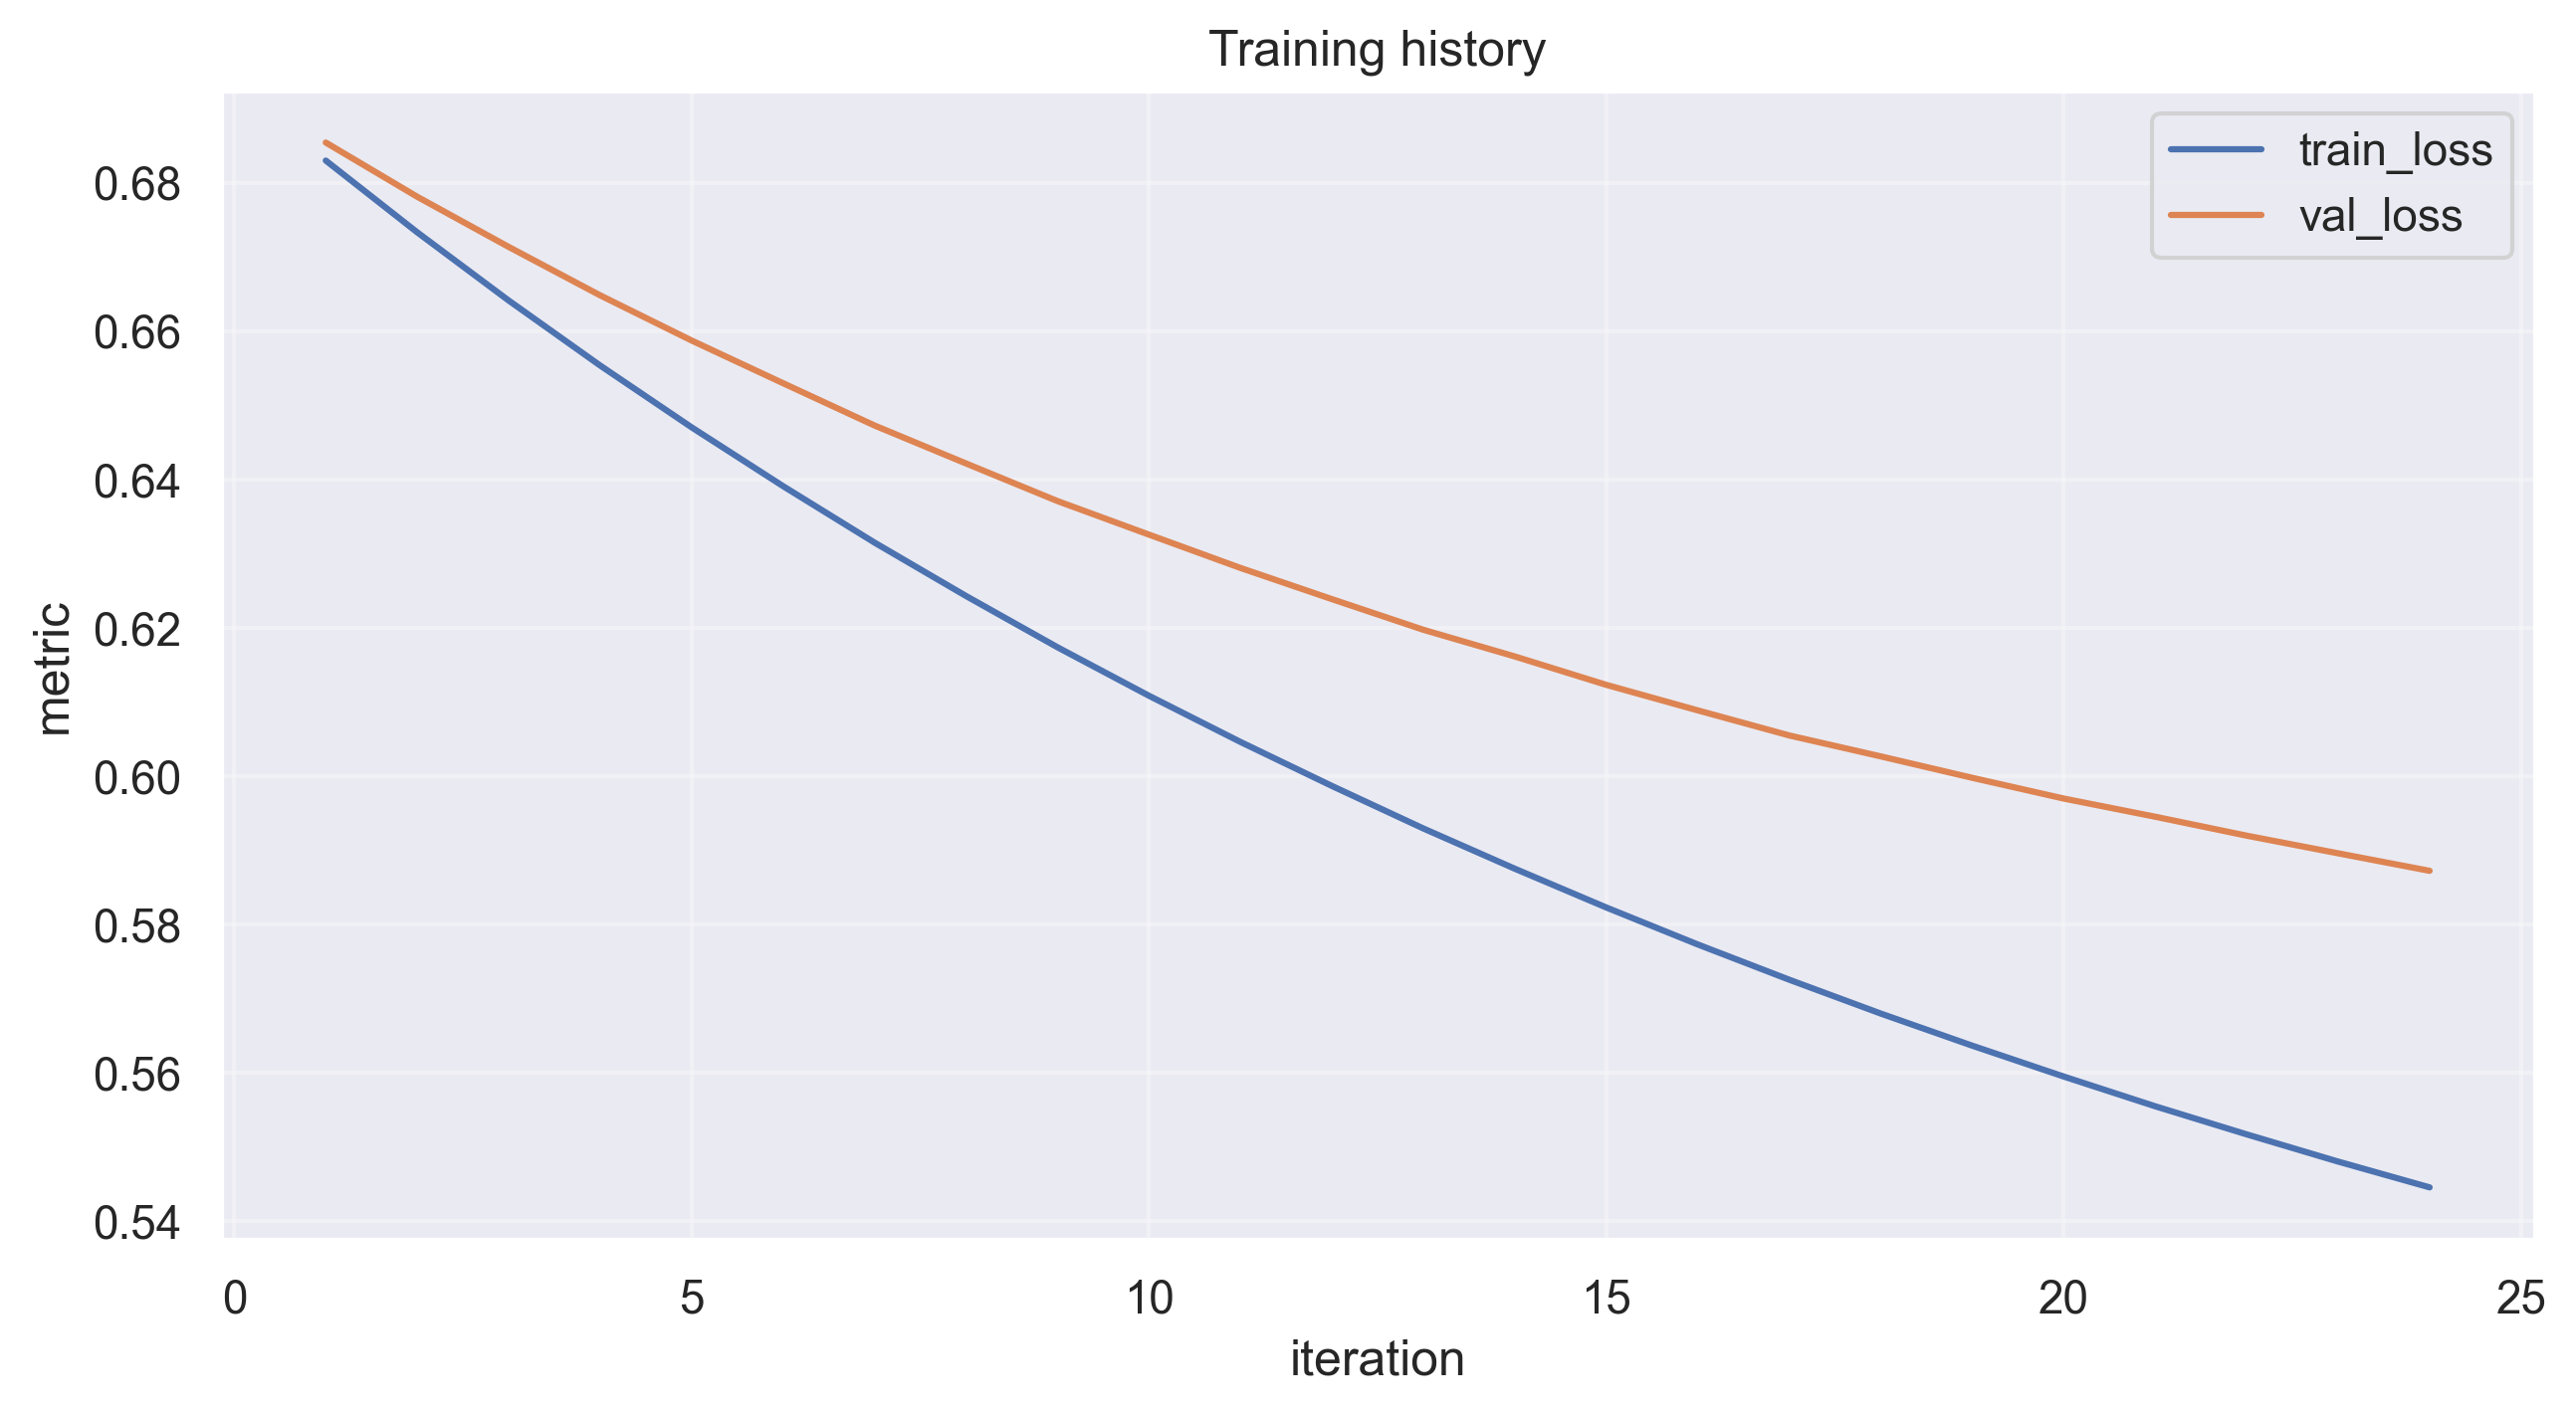

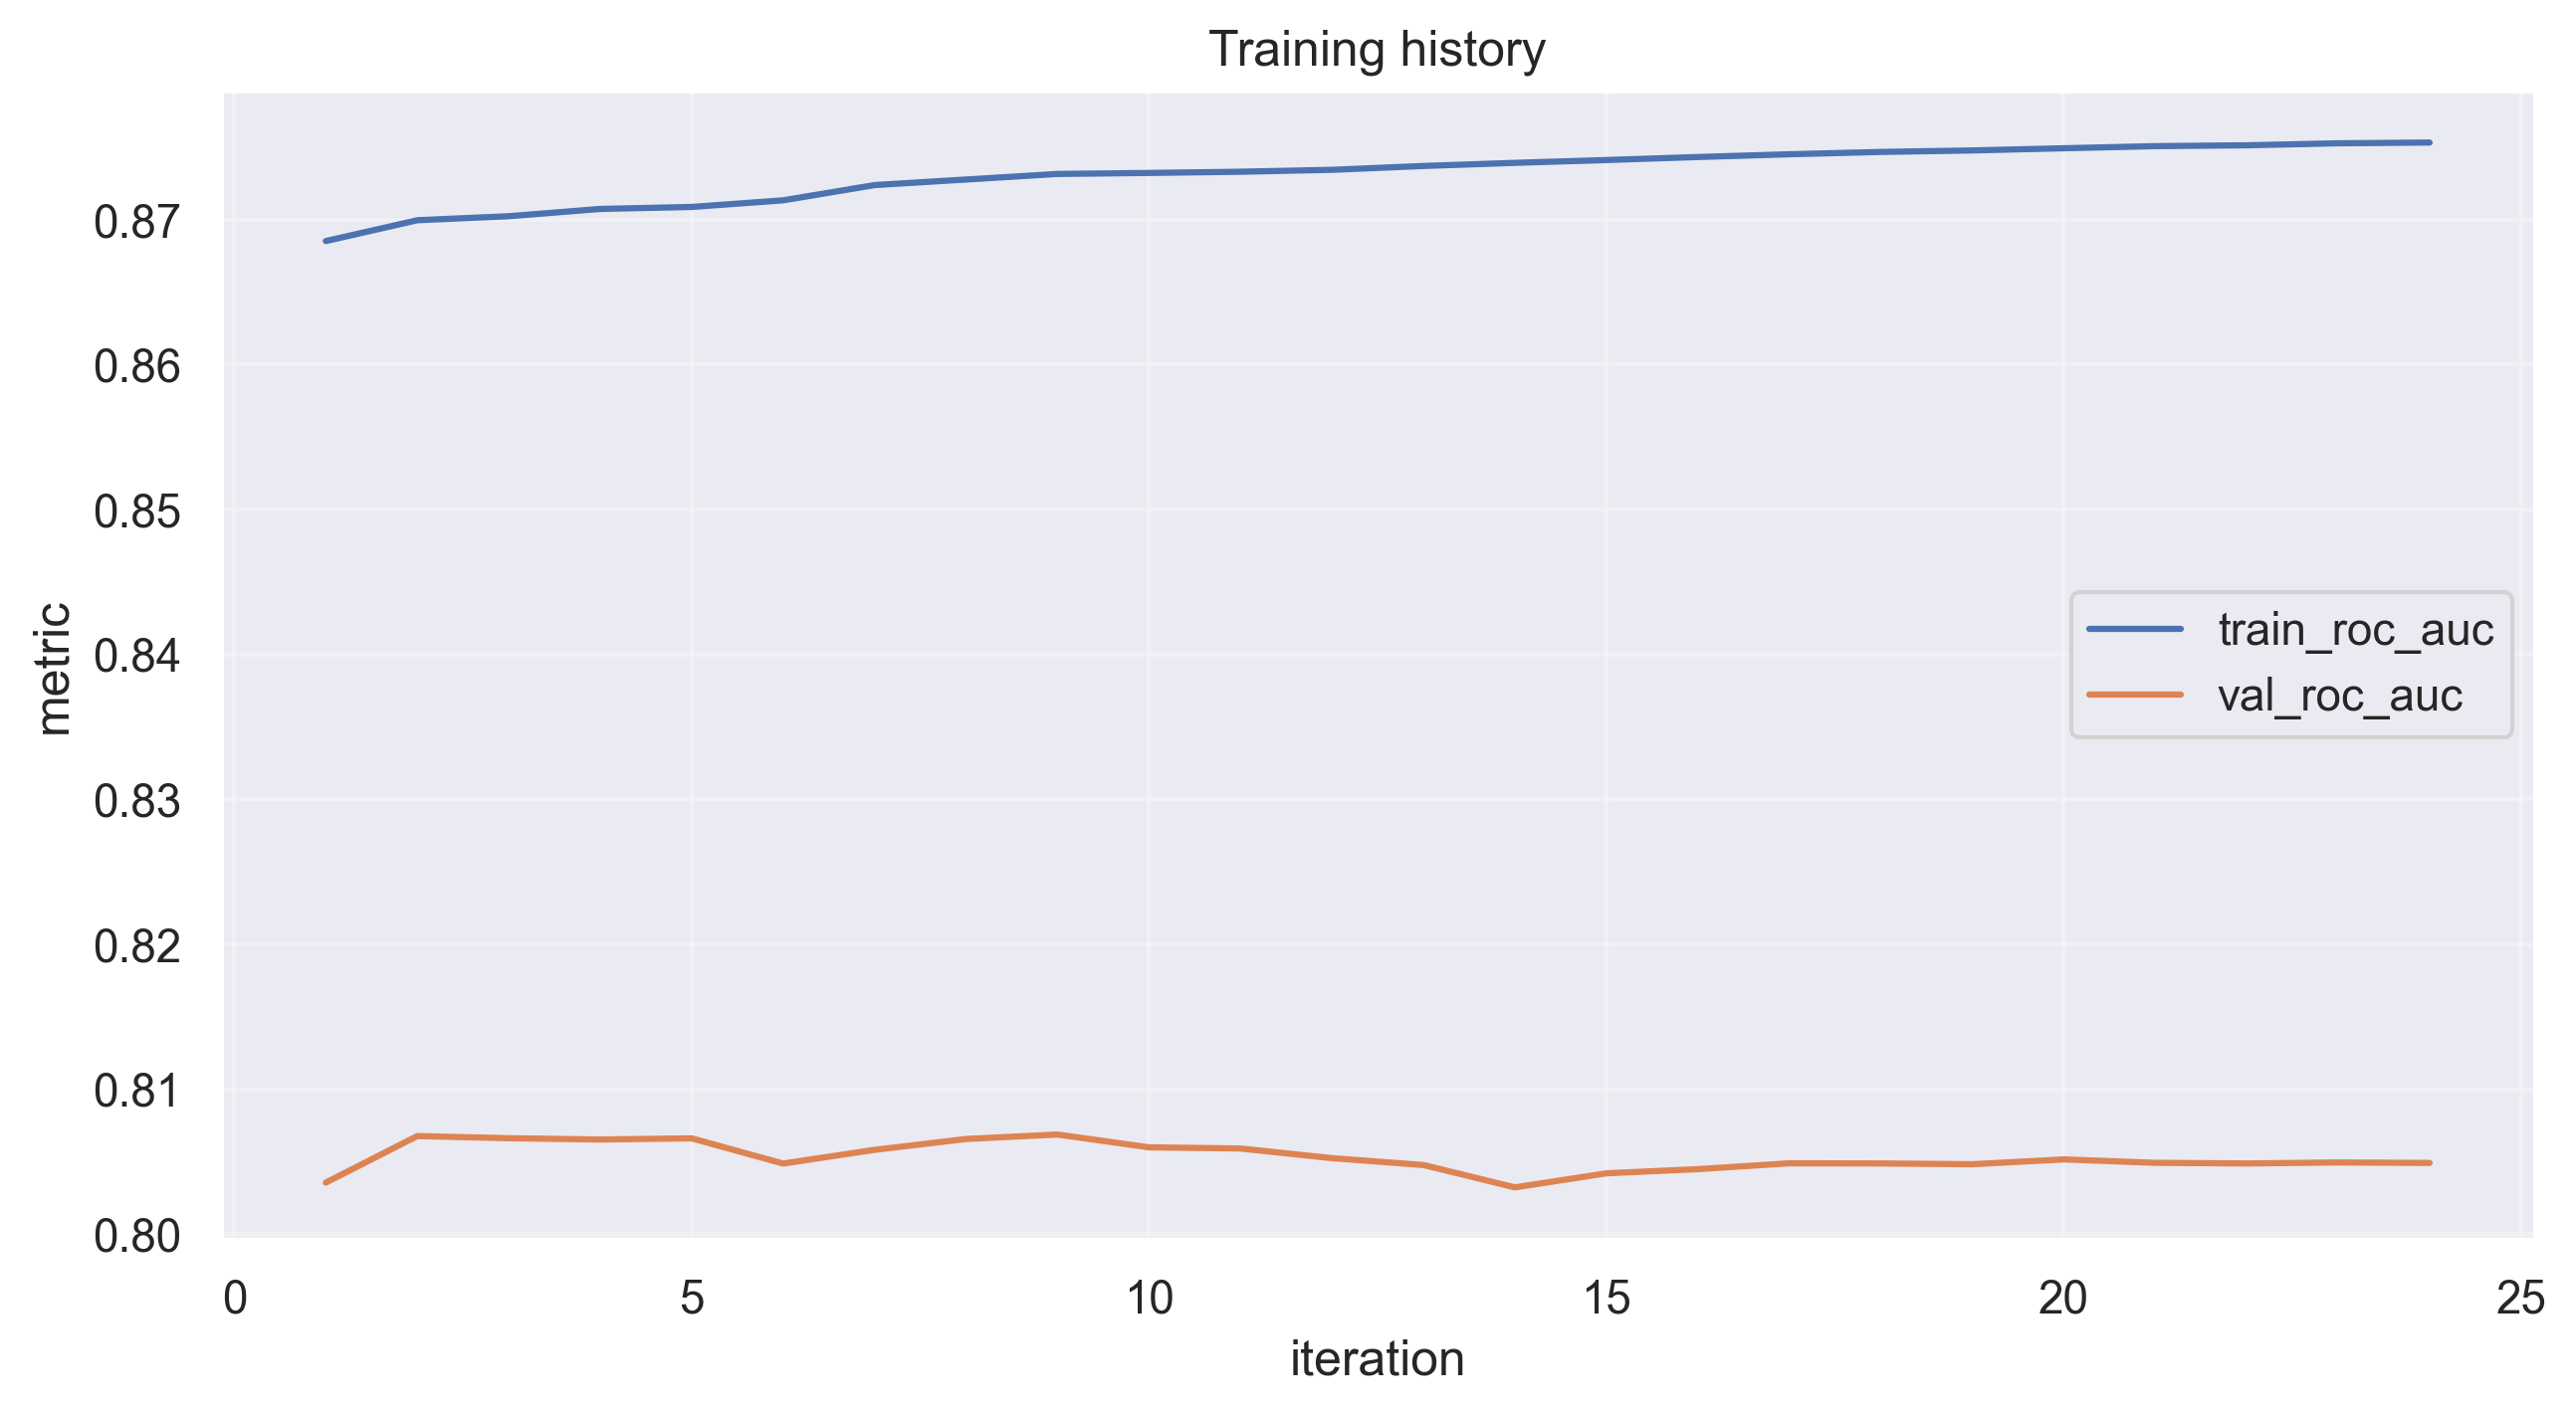

In [15]:
boosting.plot_history(['train_loss', 'val_loss'])
boosting.plot_history(['train_roc_auc', 'val_roc_auc'])

### 💠 2.3. Категории 3.0 (0.5 балла)

Увы, закодированные признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем утечку целевой переменной в признаки, но с этим можно жить, в частности $\text{OrderedBoosting}$ это одна из главных фишек <font color='#c4bf0a'>**CatBoost**</font>, была. Почитайте [статью](https://arxiv.org/pdf/1706.09516), она интересная

Реализуйте подсчет счетчиков так, чтобы кодировка категории была только по объектам. расположенным выше в датасете (например, если выборка отсортирована каким-либо образом)

Методы добавлять не нужно, разве что очень хочется, предполагается, что это дефолтное поведение бустинга

In [16]:
X_train = X[X["year"] < 2011].values
X_valid = X[X["year"] == 2011].values
X_test = X[X["year"] == 2013].values

In [17]:
feature_names = X.columns.tolist()
cat_feature_names = ['region', 'race', 'empstat', 'occ', 'occupation']
cat_features = [feature_names.index(name) for name in cat_feature_names]
print('cat_features:', dict(zip(cat_feature_names, cat_features)))

cat_features: {'region': 0, 'race': 3, 'empstat': 5, 'occ': 6, 'occupation': 10}


In [18]:
boosting = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=200,
    learning_rate=0.1,
    random_state=69,
    cat_features=cat_features,
    ordered_encoding=True,
    early_stopping_rounds=15,
    eval_metric='val_roc_auc',
)
boosting.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

In [19]:
print(f'Шагов обучено: {len(boosting.history["train_loss"])}, оставлено моделей: {len(boosting.models)}')
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test  ROC-AUC {boosting.score(X_test,  y_test):.4f}')

Шагов обучено: 28, оставлено моделей: 13
Train ROC-AUC 0.8722
Valid ROC-AUC 0.8113
Test  ROC-AUC 0.8050


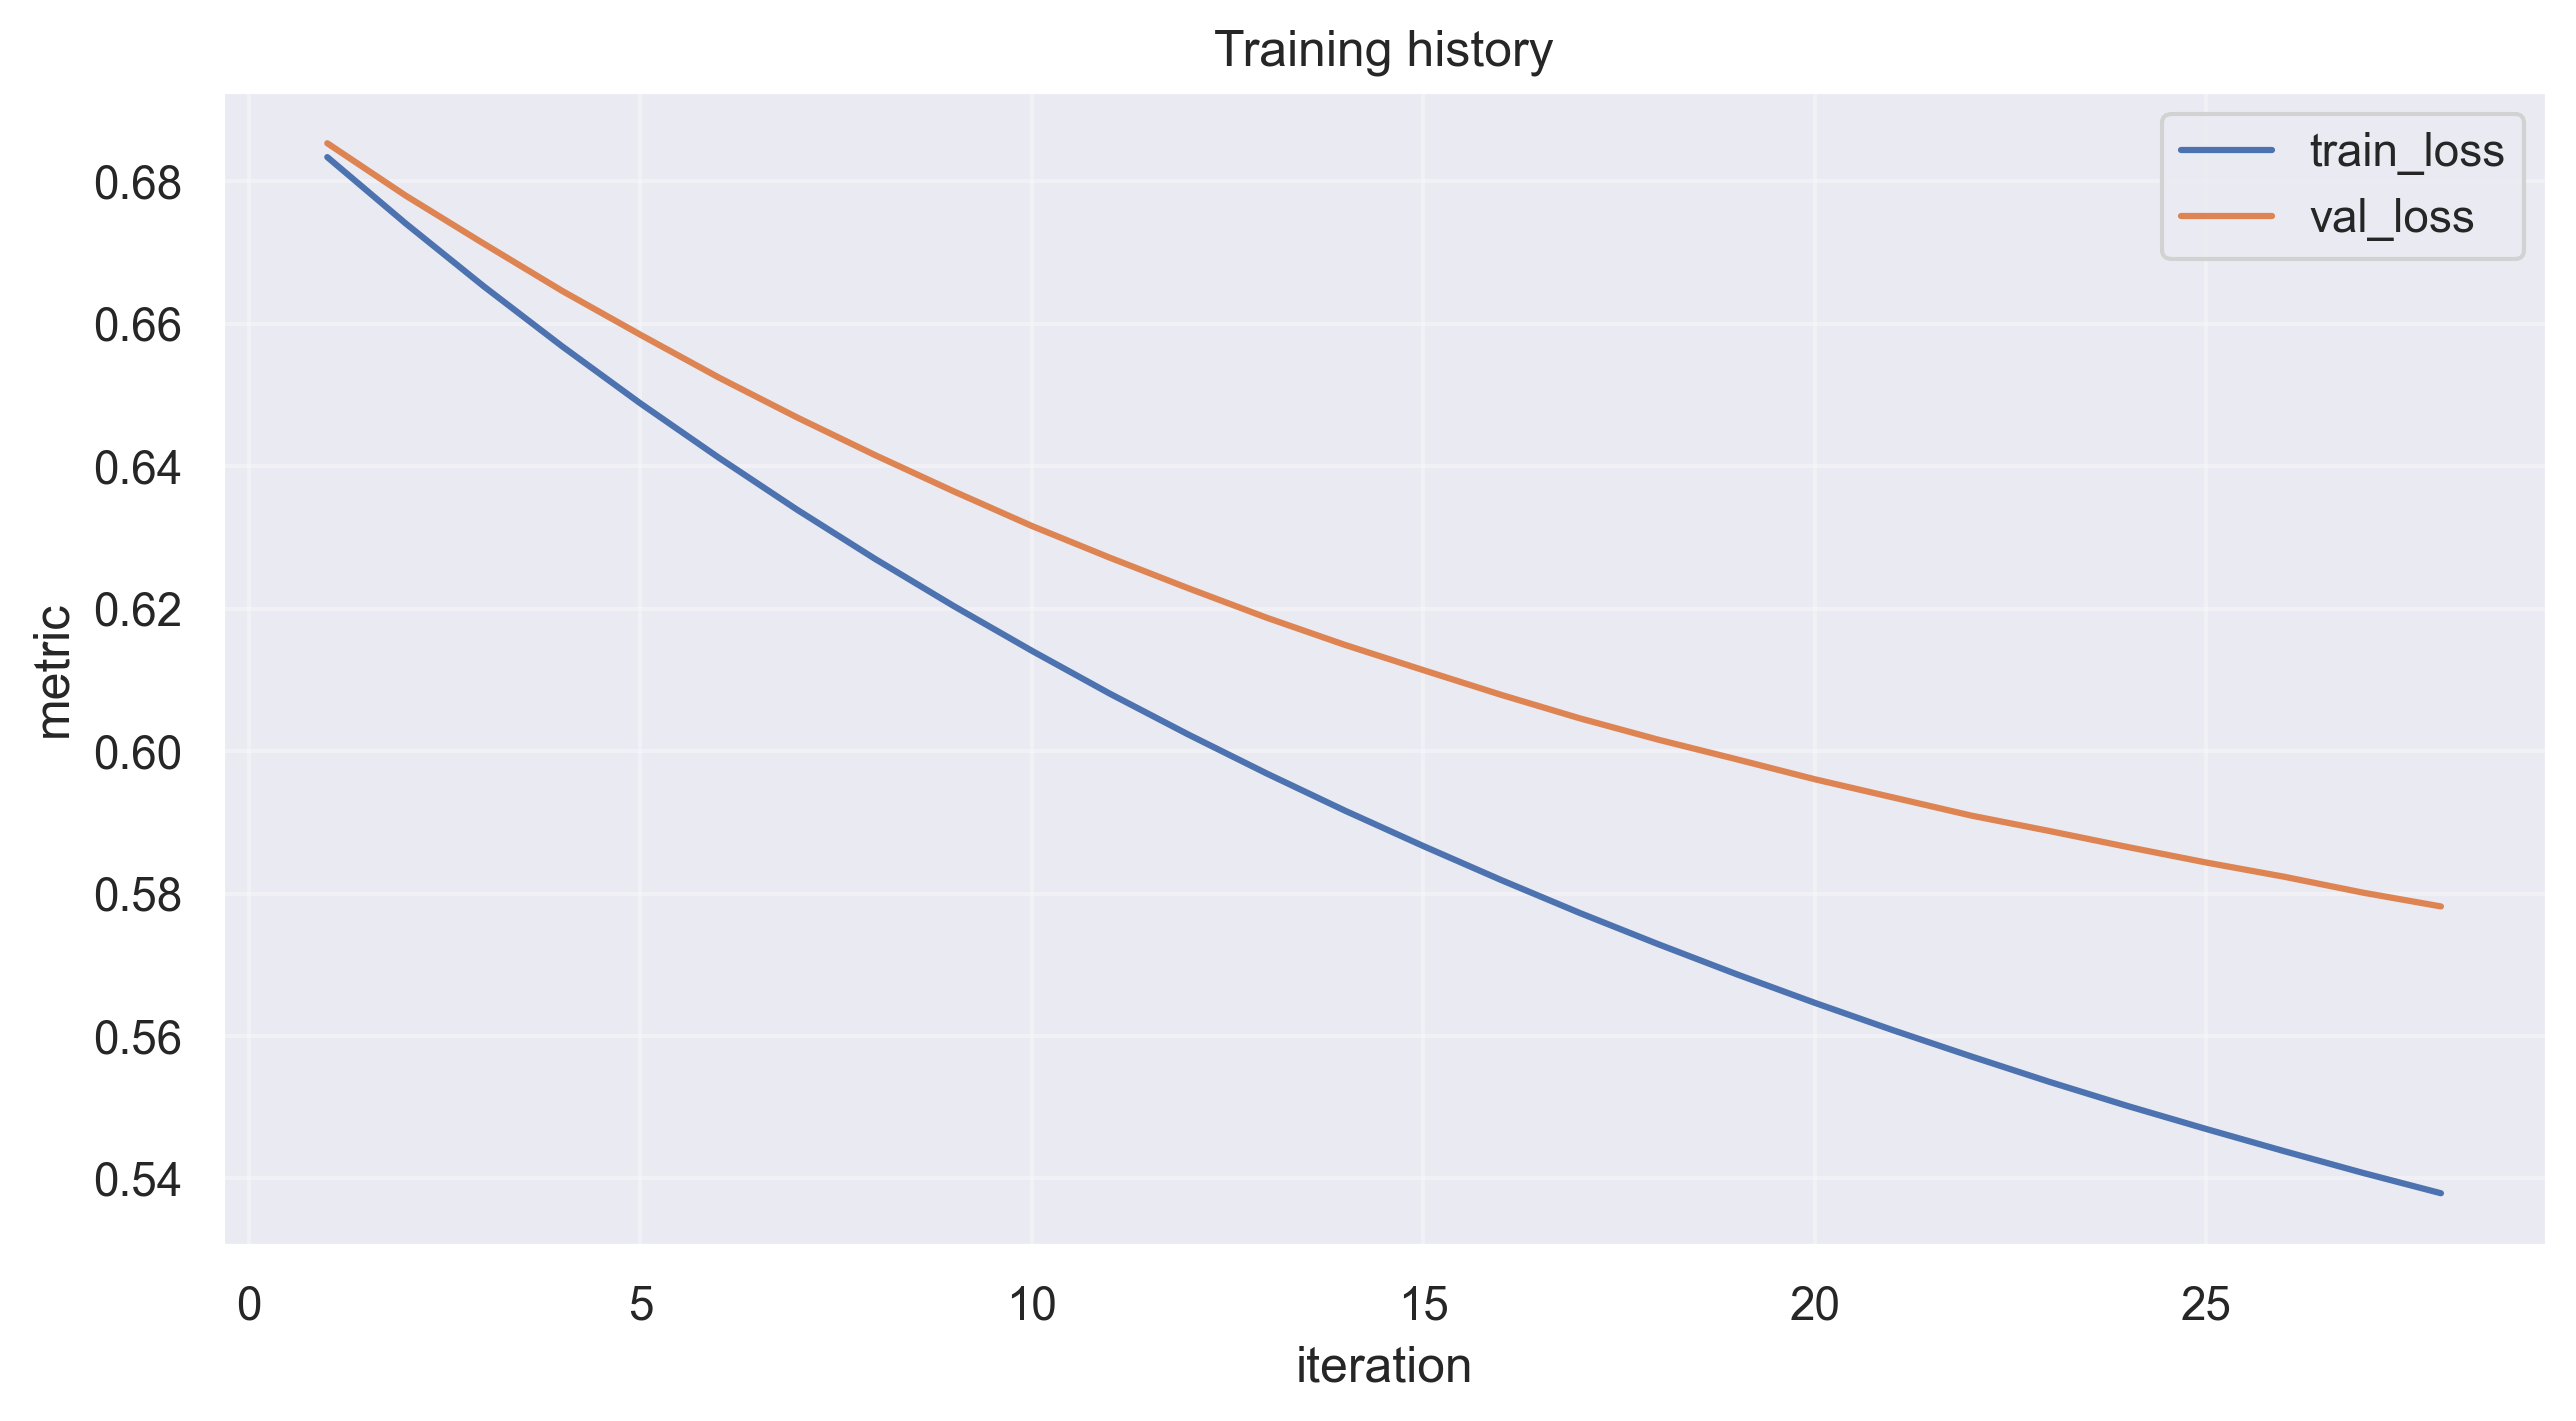

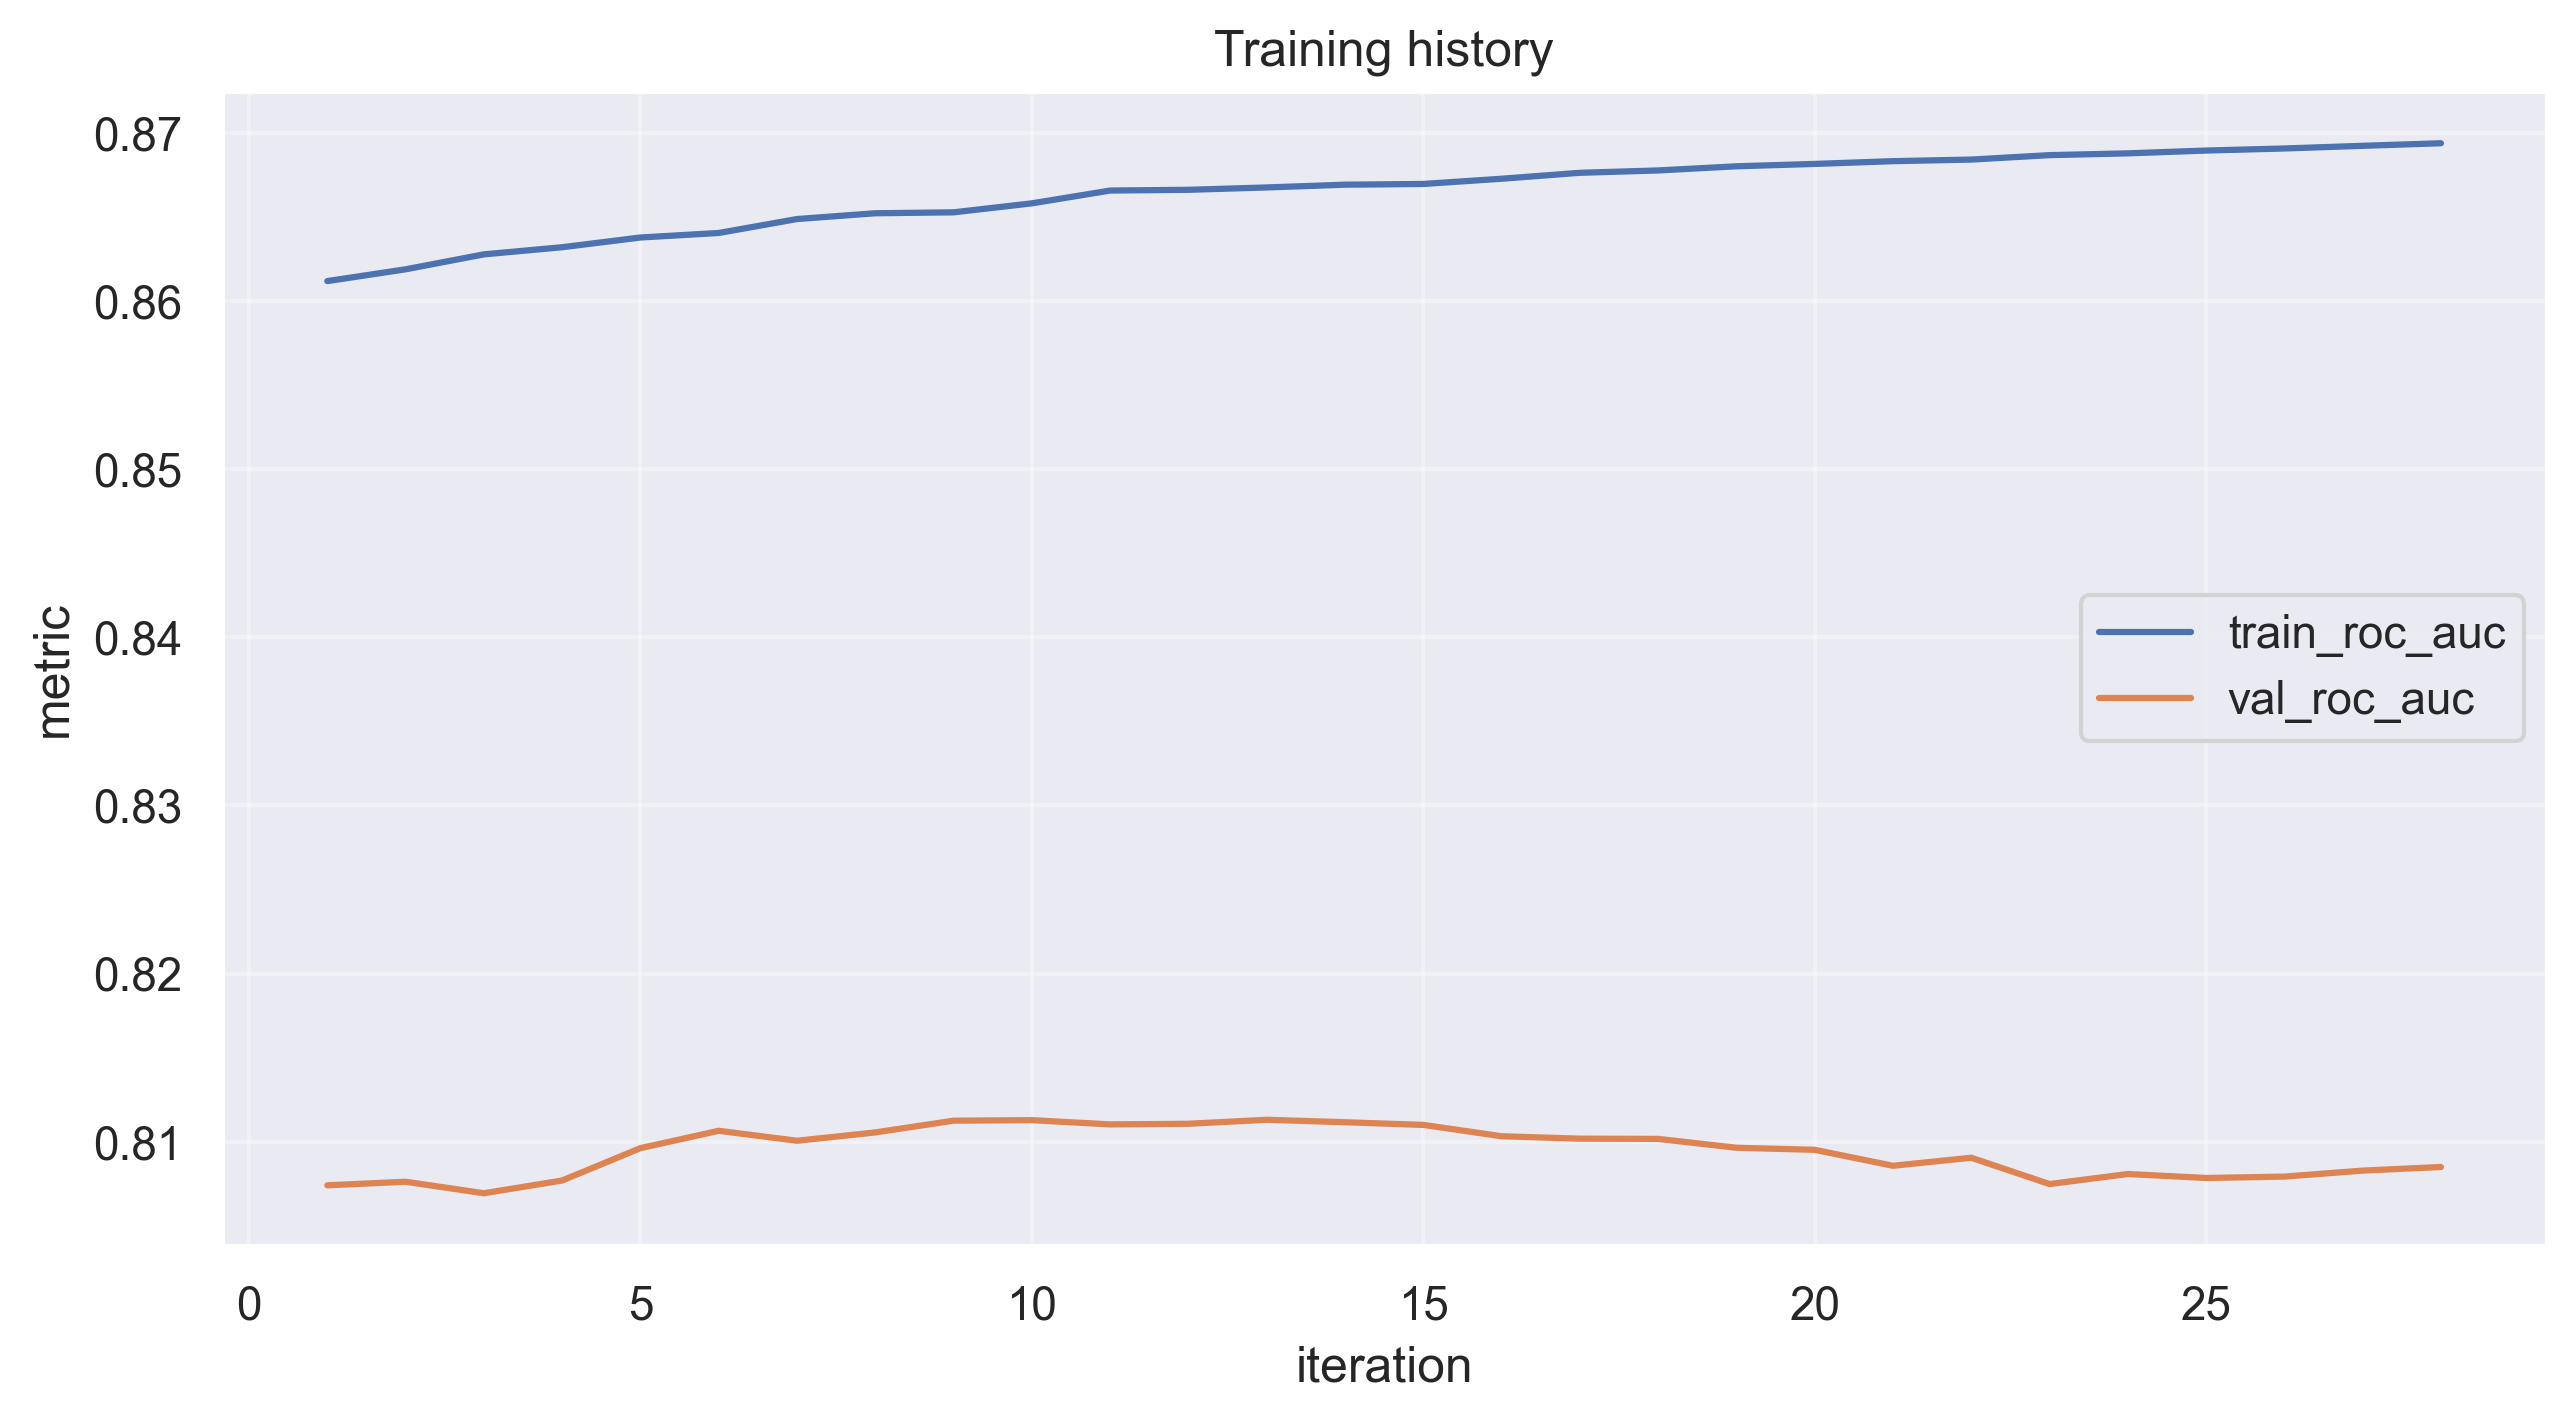

In [20]:
boosting.plot_history(['train_loss', 'val_loss'])
boosting.plot_history(['train_roc_auc', 'val_roc_auc'])

### 💠 2.4. Категории 4.0, L2 и боль (2 балла)

Но погодите, вы ещё ничего не видели! Счётчики это замечательный способ кодирования категорий, но у них есть ровно один недостаток — после кодировки признаки становятся числовыми, а если вы помните дз5, категориальные и числовые признаки обрабатываются деревьями чуть-чуть иначе.

<font color="#53c96c">**LightGBM**</font> и <font color="#2f82d4">**XGBoost**</font> решают этот вопрос не так, как <font color='#c4bf0a'>**CatBoost**</font>. Сейчас будем разбираться... И будет это тяжело, потому что отдебажить это не получится вплоть до самого конца.

Для этого пункта вам придётся стряхнуть пыль с вашей [реализации дерева](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/homework-practice/homework-practice-05-trees/hw5code.py) из дз5. Будем верить, что она написана красиво и хорошо масштабируется на новые МЛьные приключения.

#### 2.4.1. Настоящий критерий информативности (0.5 балла)

Современные реализации бустинга не используют дефолтные критерии информативности, вроде энтропии или дисперсии. Параметр `gamma`, который за нас любезно подбирается в классе `Boosting` это немного устаревший способ выбора весов (лет так на 25).

На лекции обсуждается, что получить формулу для обучения нового дерева $b_n(x)$ можно, если разложить исходную задачу обучения бустинга в ряд Тейлора. Там же показано, что при обучении на один лишь сдвиг $s_i(x)$ мы полагаем кривизну $h_i(x) = \frac{\partial^2 L}{\partial z^2}$ константной. Но можем и не полагать, как [сделали](https://arxiv.org/pdf/1603.02754) авторы уже немолодого <font color="#2f82d4">**XGBoost**</font>.

Критерий информативности в таком случае имеет вид:

$$
H(R_m) = \frac{G_l^2}{H_l + \lambda} + \frac{G_r^2}{H_r + \lambda} - \frac{G_m^2}{H_m + \lambda}
$$

- $G$ — сумма градиентов
- $H$ — сумма гессианов
- $\lambda$ — коэффициент регуляризации
- индексы $_l$, $_r$, $_m$ — левый, правый, исходный узел дерева соответственно

> Кривизна позволяет нам подстроиться под каждый объект, когда мы делаем шаг градиентного бустинга. $\gamma$ в таком случае оказывается не нужна, она не умеет подстраивать шаг индивидуально. Более того, сюда можно сразу же встроить $L_2$ регуляризацию, что мы и сделаем.     
Наконец, если перейти от объектов к градиентам и гессианам, внезапно можно вообще забить на то, числовой признак или категориальный, мы же всё равно оцениваем градиент, то есть сплит подбираем напрямую из задачи. Велико!

Текущая задача: модифицировать функцию `find_best_split`. Считайте, что параметры `grad_vector` и `hess_vector` в неё уже передаются. Градиент мы считать уже умеем, с гессианом разберёмся попозже

In [21]:
from boosting import find_best_split
import matplotlib.pyplot as plt

In [22]:
rng = np.random.default_rng(0)
n = 1000
x = rng.uniform(0, 10, size=n)
y_pm = np.sign(np.where(x < 5, -1.0, 1.0) + rng.normal(0, 0.3, size=n))

z = np.zeros(n)
sig = lambda u: 1 / (1 + np.exp(-u))
anti_grad = y_pm * sig(-y_pm * z)
hess = sig(y_pm * z) * (1 - sig(y_pm * z))

thresholds, gains, best_t, best_g = find_best_split(x, anti_grad, hess, l2=1.0)
print(f'best threshold = {best_t:.3f}, best gain = {best_g:.4f}')

best threshold = 5.005, best gain = 989.1593


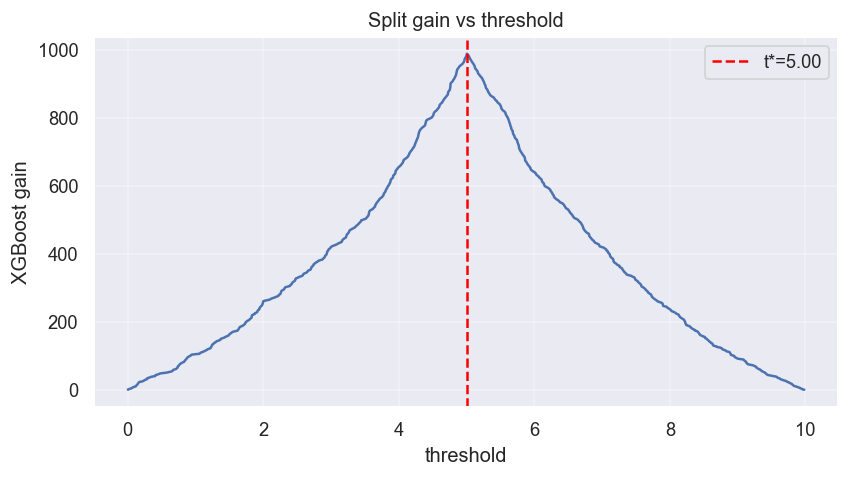

In [23]:
plt.figure(figsize=(8, 4), dpi=200)
plt.plot(thresholds, gains)
plt.axvline(best_t, color='red', ls='--', label=f't*={best_t:.2f}')
plt.xlabel('threshold')
plt.ylabel('XGBoost gain')
plt.title('Split gain vs threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 2.4.2. Я посадил дерево (0.75 балла)

Теперь, когда критерий у нас есть, наступает следующий логический шаг - пихнуть его в дерево. Предсказания будут иметь следующий вид:

$$b(R) = \frac{1}{|R|}\sum_{y_i \in R} \frac{\nabla(y_i)}{(\nabla^2(y_i) + \lambda )}$$

Это сумма градиентов делить на сумму гессианов + коэффициент регуляризации. В случае $\nabla^2(y_i) = 1$ и нулевой регуляризации вырождается в наш самый обыкновенный бустинг. Мы ведь помним, что каждое дерево в нём обучается на антиградиент.

Что делать то?

- добавить параметр `l2: float | None = 1.0` в вашу реализацию дерева
- подправить предсказания по формуле выше, сейчас они считаются для классификации, а не для регрессии (должно быть идентично и для чисел, и для категорий)
- категории нужно занумеровать, это делается за вас в дереве, но не забудьте пожалуйста
- в `fit_node` должны поступать градиенты и гессианы, в левый и правый узел после разбиения тоже, уже для соответствующих левой и правой подвыборок

> Строго говоря, <font color="#53c96c">**LightGBM**</font> перебирает категории по критерию Фишера, который группирует категории по градиентам. Это один из видов квантизации, которая будет чуть ниже. Делать это не надо, но если любопытно, то [почитайте](https://lightgbm.readthedocs.io/en/latest/Features.html#optimal-split-for-categorical-features)

In [ ]:
from boosting import XGBoostTree
from sklearn.datasets import make_classification

In [ ]:
X_demo, y_demo = make_classification(n_samples=2000, n_features=5, random_state=0)
y_pm_demo = 2 * y_demo - 1

z = np.zeros(len(y_pm_demo))
ag = y_pm_demo * sig(-y_pm_demo * z)
hs = sig(y_pm_demo * z) * (1 - sig(y_pm_demo * z))

In [ ]:
tree = XGBoostTree(max_depth=4, l2=1.0).fit(X_demo, ag, hs)
pred = tree.predict(X_demo)

In [24]:
print(f'pred range: [{pred.min():.3f}, {pred.max():.3f}], mean: {pred.mean():.4f}')
print(f'corr(pred, y_pm) = {np.corrcoef(pred, y_pm_demo)[0, 1]:.3f}')

print('границы и направление совпадают со знаком таргета (большой positive corr).')

pred range: [-1.960, 1.976], mean: 0.0039
corr(pred, y_pm) = 0.986
границы и направление совпадают со знаком таргета (большой positive corr).


#### 2.4.3. Момент истины (0.75 балла)

Наконец, осталось запихнуть это дело в бустинг. Алгоритм будет работать точно так же. Если вы корректно его написали, поменять потребуется немного, а именно:

- добавить гиперпараметр `l2: float | None = 0.0`
- добавить метод `self.hess_fn = lambda y, z: ...`, который будет считать гессиан для бинарной кросс-энтропии
- приравнять оптимальную гамму к единице, если `l2` не равен 0
- передавать гредиенты и гессианы в базовую модель, если у неё есть параметр `l2` и он не равен 0
- гессиан лучше клипать, иначе можно внезапно поделить на 0 при маленьком `l2`
- не забудьте, что передавать надо антиградиенты, а не просто градиенты, иначе выйдет что-то не то

Покажите, что оно работает...

In [25]:
boosting_l2 = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=200,
    learning_rate=0.1,
    random_state=69,
    cat_features=cat_features,
    ordered_encoding=True,
    early_stopping_rounds=15,
    eval_metric='val_roc_auc',
    l2=1.0,
)
boosting_l2.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

In [26]:
print(f'Шагов обучено: {len(boosting_l2.history["train_loss"])}, оставлено моделей: {len(boosting_l2.models)}')
print(f'gammas[:5]: {boosting_l2.gammas[:5]}')
print(f'Train ROC-AUC {boosting_l2.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting_l2.score(X_valid, y_valid):.4f}')
print(f'Test  ROC-AUC {boosting_l2.score(X_test,  y_test):.4f}')

Шагов обучено: 18, оставлено моделей: 3
gammas[:5]: [1.0, 1.0, 1.0]
Train ROC-AUC 0.8708
Valid ROC-AUC 0.8129
Test  ROC-AUC 0.8067


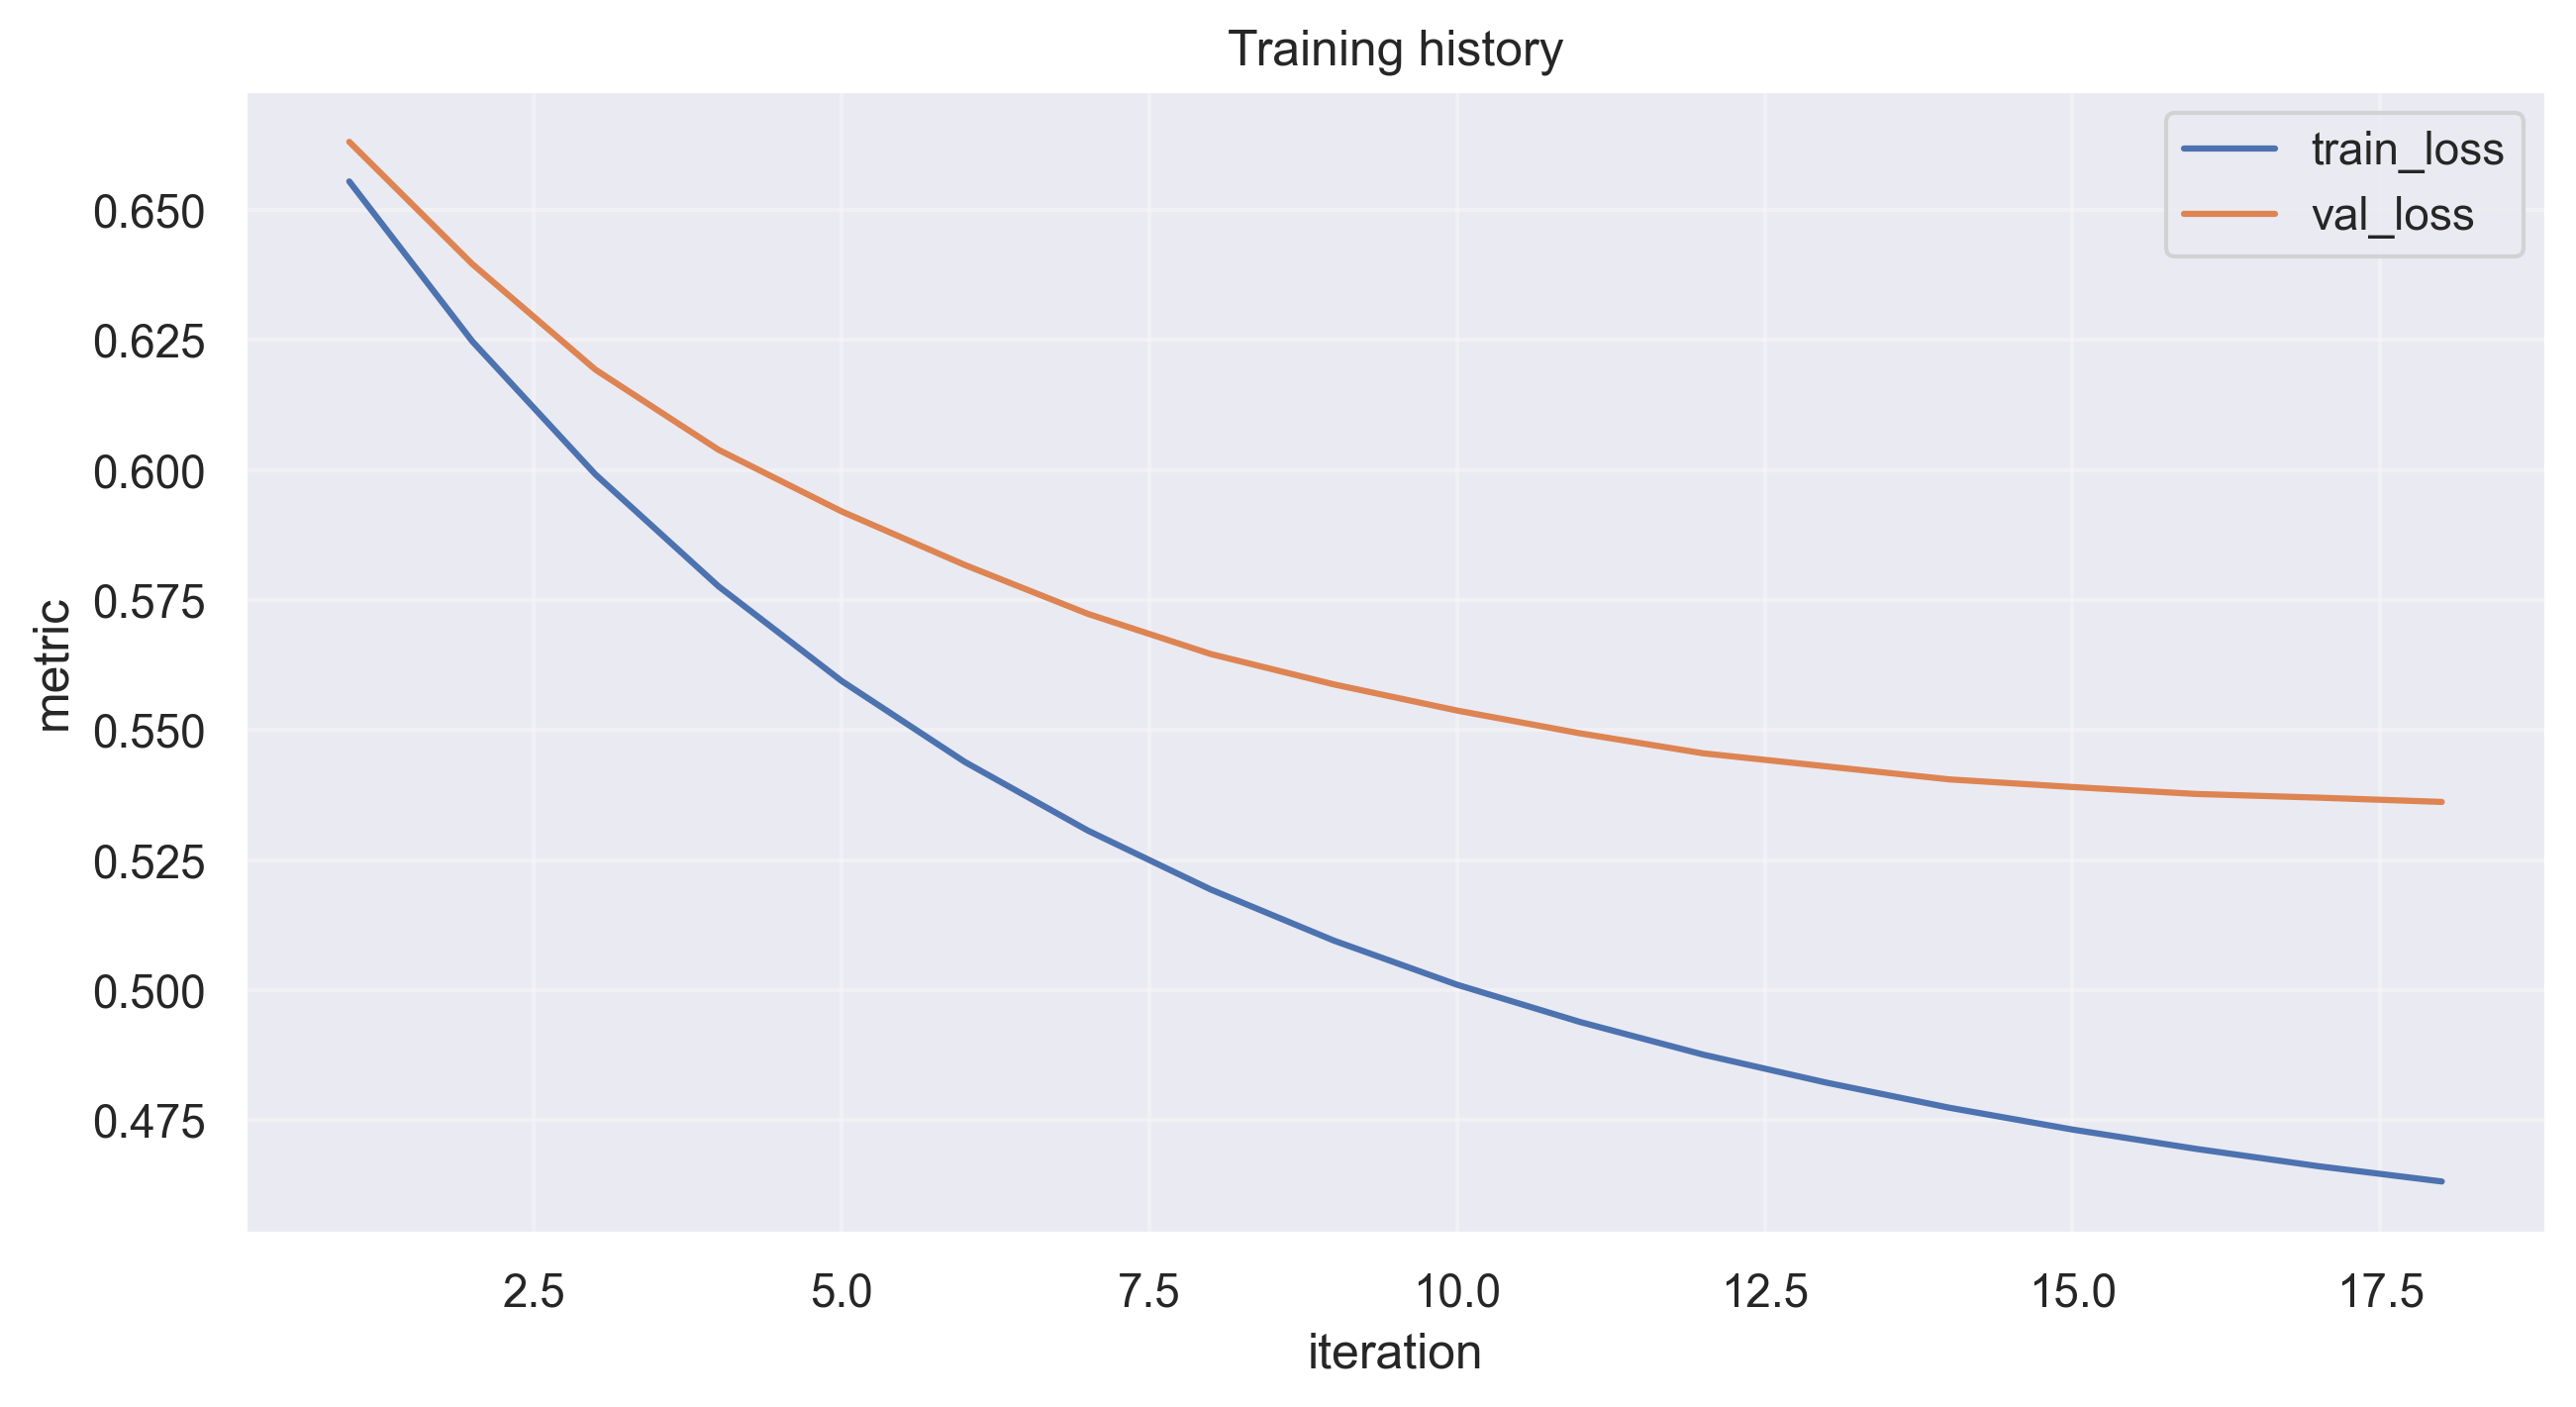

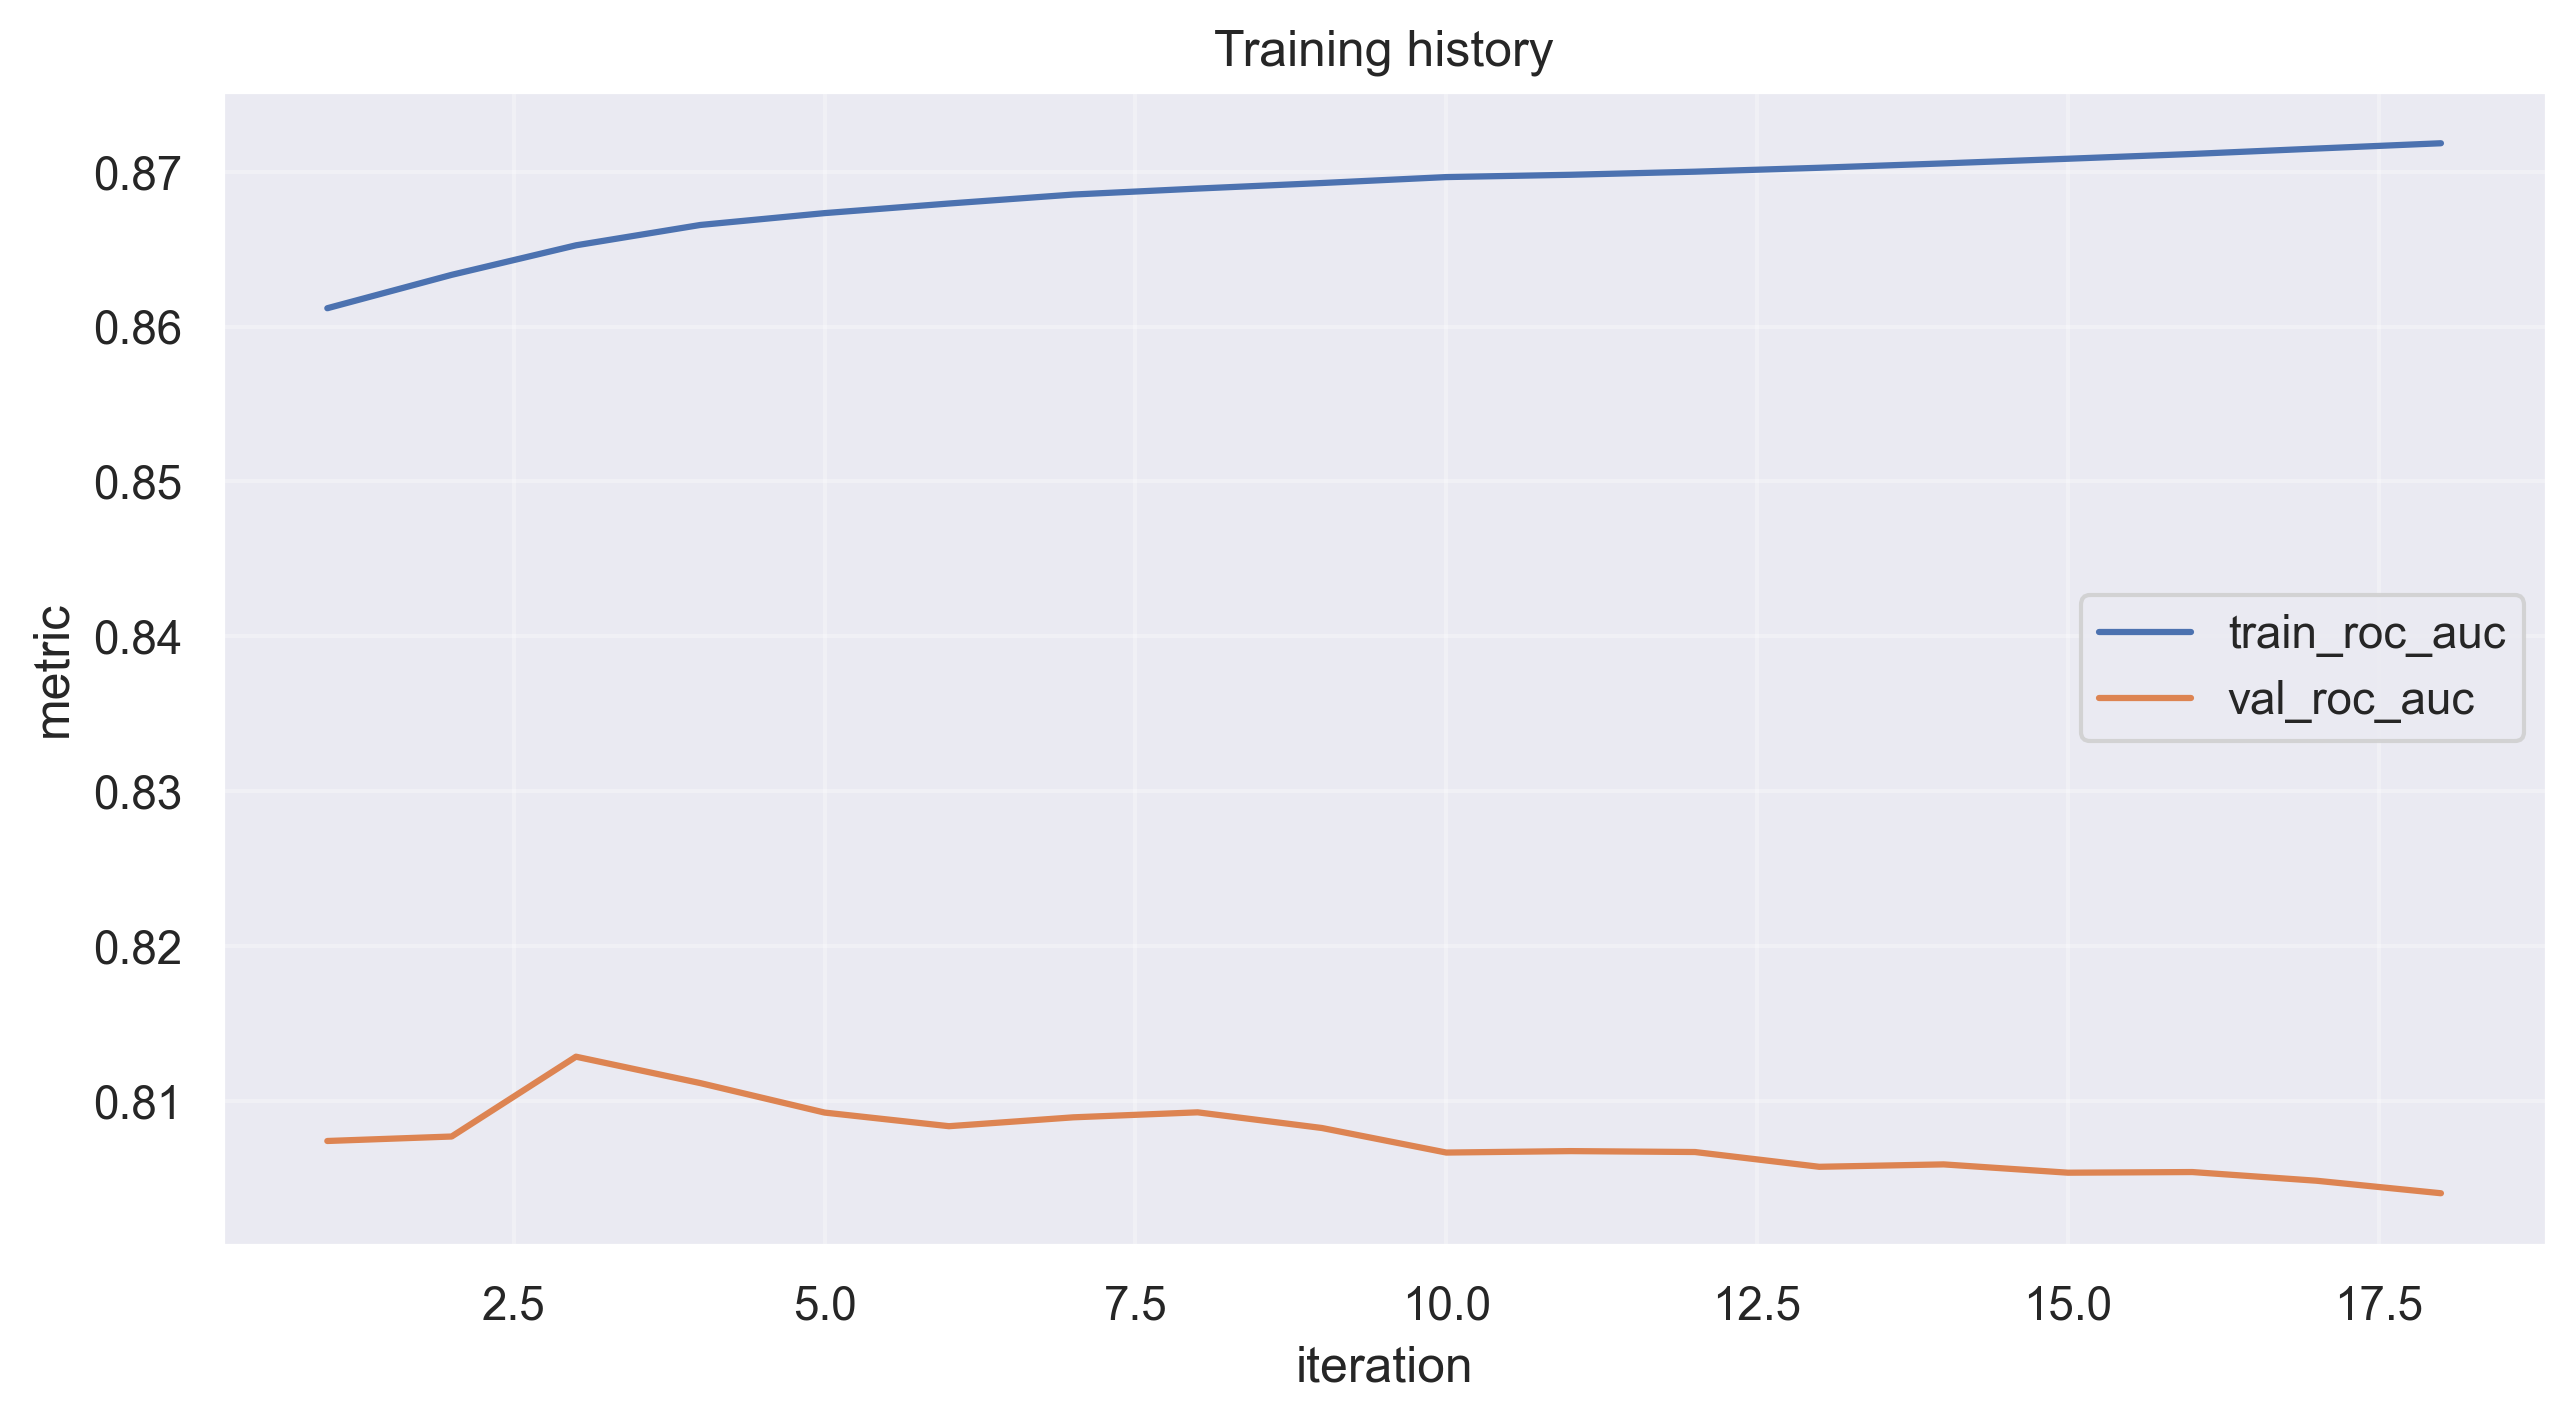

In [27]:
boosting_l2.plot_history(['train_loss', 'val_loss'])
boosting_l2.plot_history(['train_roc_auc', 'val_roc_auc'])

### 💠 2.5. Бутстрап (1.25 балла)</span>

Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

> Идея, которая за этим стоит проста — бустинги переобучаются, как черти. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

#### 2.5.1. Бутстрап дефолтный (0.75 балла)

Вам нужно реализовать параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель. Соответствует бутстрапу типа `Bernoulli`.
- `bagging_temperature: float = 1.0` — температура для весов в Bayesian-бутстрапе: $w = (-\log U)^t$, где $U \sim U[0,1]$.
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>subsample</code></td>
<td align="center"><code>subsample</code>, <code>bagging</code></td>
<td align="center"><code>subsample</code>, <code>bootstrap_type</code></td>
</tr>
</table>

</div>

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?

**Ответ:**

Бутстрап вносит шум в обучающую выборку каждого дерева, что декоррелирует базовые модели:

- **Разброс (variance) композиции уменьшается** - корреляция между деревьями падает, ансамбль усредняет шум эффективнее
- **Смещение (bias) у отдельного дерева может чуть подрасти** (видит меньше объектов / меньшую разнообразность), но на ансамбле это перевешивается падением разброса. Для бустинга это особенно полезно, так как он склонен к переобучению на лёгких примерах.
- **Скорость обучения растёт** в Bernoulli-варианте: каждое дерево учится на доле `subsample` объектов.
- **Bayesian-бутстрап** — это непрерывное обобщение: вместо вошёл/не вошёл - каждый объект получает дробный вес. Параметр `bagging_temperature` контролирует разнообразие весов: при $t\to 0$ все веса близки к 1 (без сэмплинга), при больших $t$ - экстремально неравномерные.

</div>

In [28]:
import time
import matplotlib.pyplot as plt

In [29]:
common = dict(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=60,
    learning_rate=0.1,
    random_state=69,
    cat_features=cat_features,
    ordered_encoding=True,
    early_stopping_rounds=15,
    eval_metric='val_roc_auc',
)

variants = [
    ('без бутстрапа', dict(subsample=1.0)),
    ('Bernoulli sub=0.7', dict(bootstrap_type='Bernoulli', subsample=0.7)),
    ('Bernoulli sub=0.5', dict(bootstrap_type='Bernoulli', subsample=0.5)),
    ('Bayesian t=0.5', dict(bootstrap_type='Bayesian',  bagging_temperature=0.5)),
    ('Bayesian t=1.0', dict(bootstrap_type='Bayesian',  bagging_temperature=1.0)),
]

In [30]:
results = {}
print(f'{"вариант":<22s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}{"time, s":>10s}')
for name, extra in variants:
    t = time.time()
    b = Boosting(**common, **extra)
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    dur = time.time() - t
    results[name] = b
    print(
        f'{name:<22s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}{dur:>10.1f}'
    )

вариант                   train    valid     test   kept   time, s
без бутстрапа            0.8722   0.8113   0.8050     13      23.2
Bernoulli sub=0.7        0.8723   0.8110   0.8046     11      17.3
Bernoulli sub=0.5        0.8737   0.8107   0.8041     16      17.7
Bayesian t=0.5           0.8728   0.8103   0.8040     13      23.5
Bayesian t=1.0           0.8715   0.8106   0.8040      6      17.2


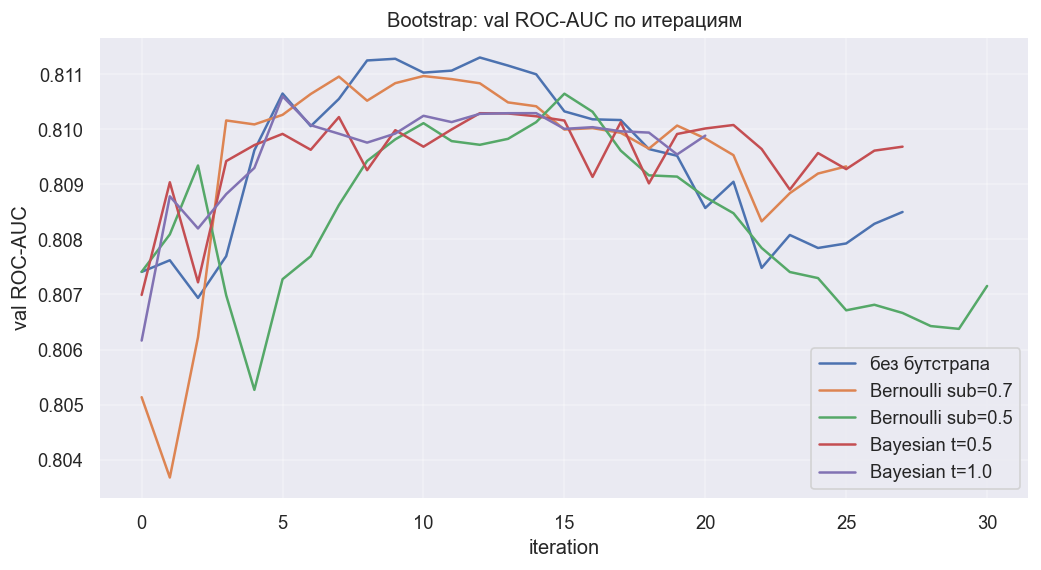

In [31]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('Bootstrap: val ROC-AUC по итерациям')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Нужно добавить параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

In [32]:
variants_rsm = [
    ('rsm=1.0', dict(rsm=1.0)),
    ('rsm=0.7', dict(rsm=0.7)),
    ('rsm=0.5', dict(rsm=0.5)),
    ('rsm=0.3', dict(rsm=0.3)),
]

In [33]:
results_rsm = {}
print(f'{"вариант":<10s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}')
for name, extra in variants_rsm:
    b = Boosting(**common, **extra)
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    results_rsm[name] = b
    print(
        f'{name:<10s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}'
    )

вариант       train    valid     test   kept
rsm=1.0      0.8722   0.8113   0.8050     13
rsm=0.7      0.8729   0.8121   0.8054     14
rsm=0.5      0.8733   0.8006   0.7931     24
rsm=0.3      0.8669   0.8113   0.8042      3


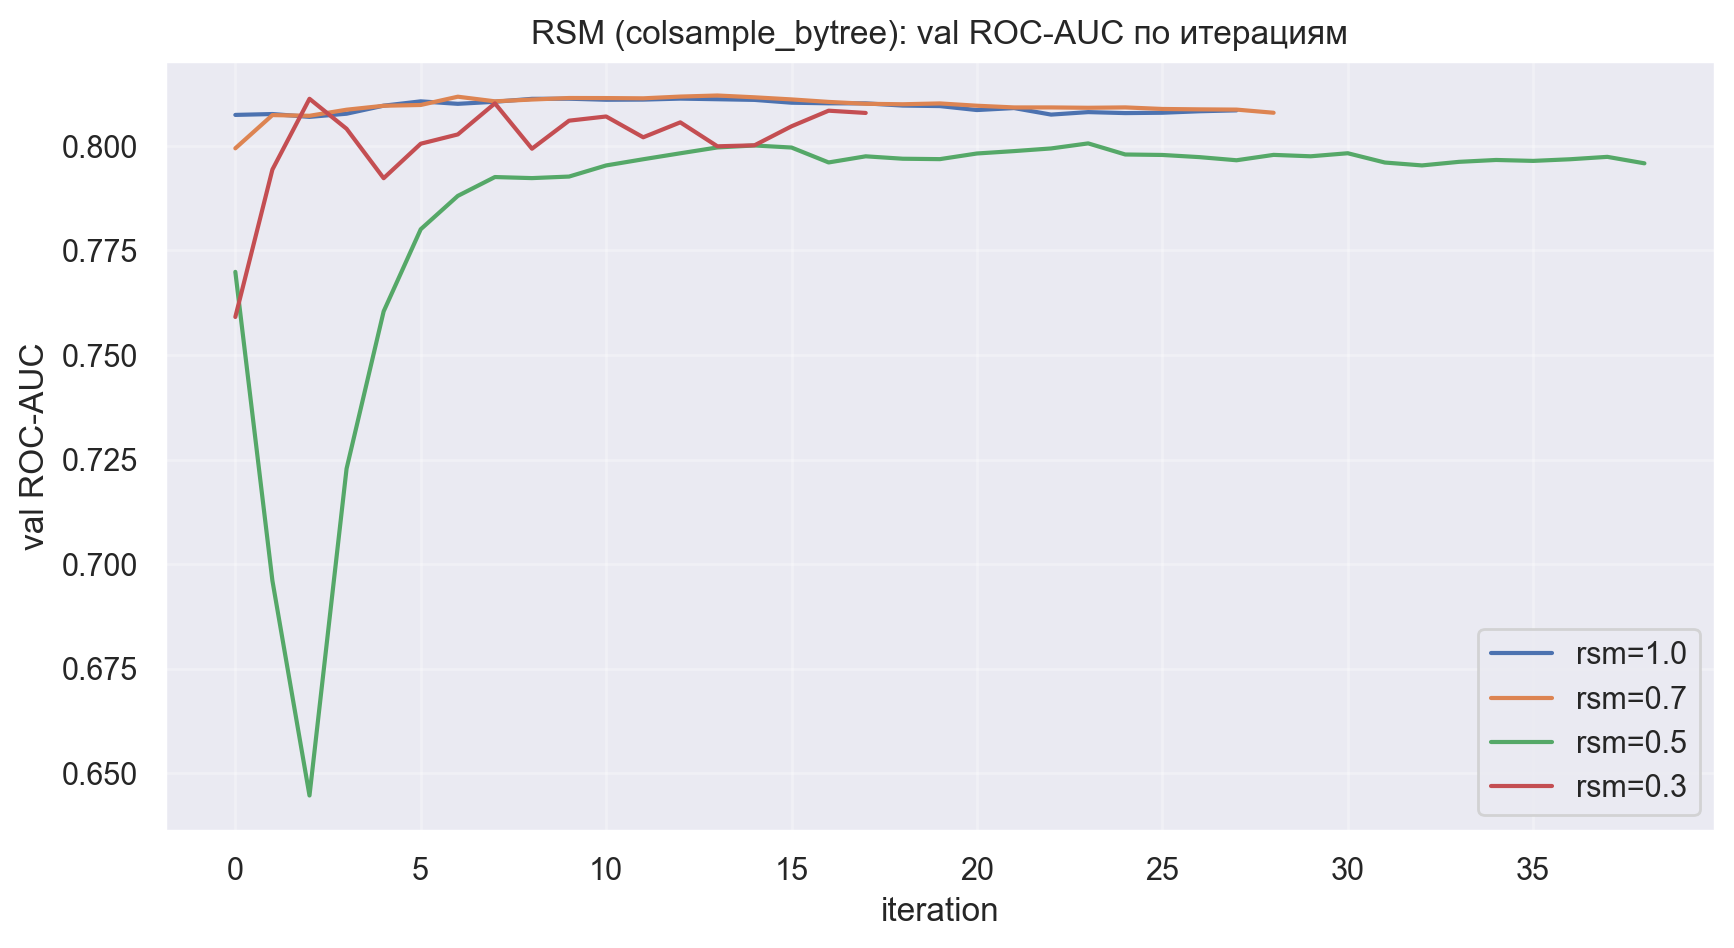

In [34]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results_rsm.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('RSM (colsample_bytree): val ROC-AUC по итерациям')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

#### 2.5.2. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

Параметры, которые нужно сделать:

- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>bagging='goss'</code></td>
<td align="center"><code>bootstrap_type='MVS'</code></td>
</tr>
</table>

</div>

Сделайте и посмотрите

In [35]:
goss_variants = [
    ('baseline (sub=1.0)', dict(subsample=1.0)),
    ('Bernoulli sub=0.4', dict(bootstrap_type='Bernoulli', subsample=0.4)),
    ('GOSS k=0.2, sub=0.3', dict(goss=True, goss_k=0.2, subsample=0.3)),
    ('GOSS k=0.1, sub=0.2', dict(goss=True, goss_k=0.1, subsample=0.2)),
]

In [36]:
results_goss = {}
print(f'{"вариант":<25s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}{"time, s":>10s}')
for name, extra in goss_variants:
    t = time.time()
    b = Boosting(**common, **extra)
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    dur = time.time() - t
    results_goss[name] = b
    print(
        f'{name:<25s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}{dur:>10.1f}'
    )

вариант                      train    valid     test   kept   time, s
baseline (sub=1.0)          0.8722   0.8113   0.8050     13      23.3
Bernoulli sub=0.4           0.8732   0.8106   0.8040     12      13.9
GOSS k=0.2, sub=0.3         0.8738   0.8104   0.8043     10      13.3
GOSS k=0.1, sub=0.2         0.8748   0.8093   0.8028     18      15.3


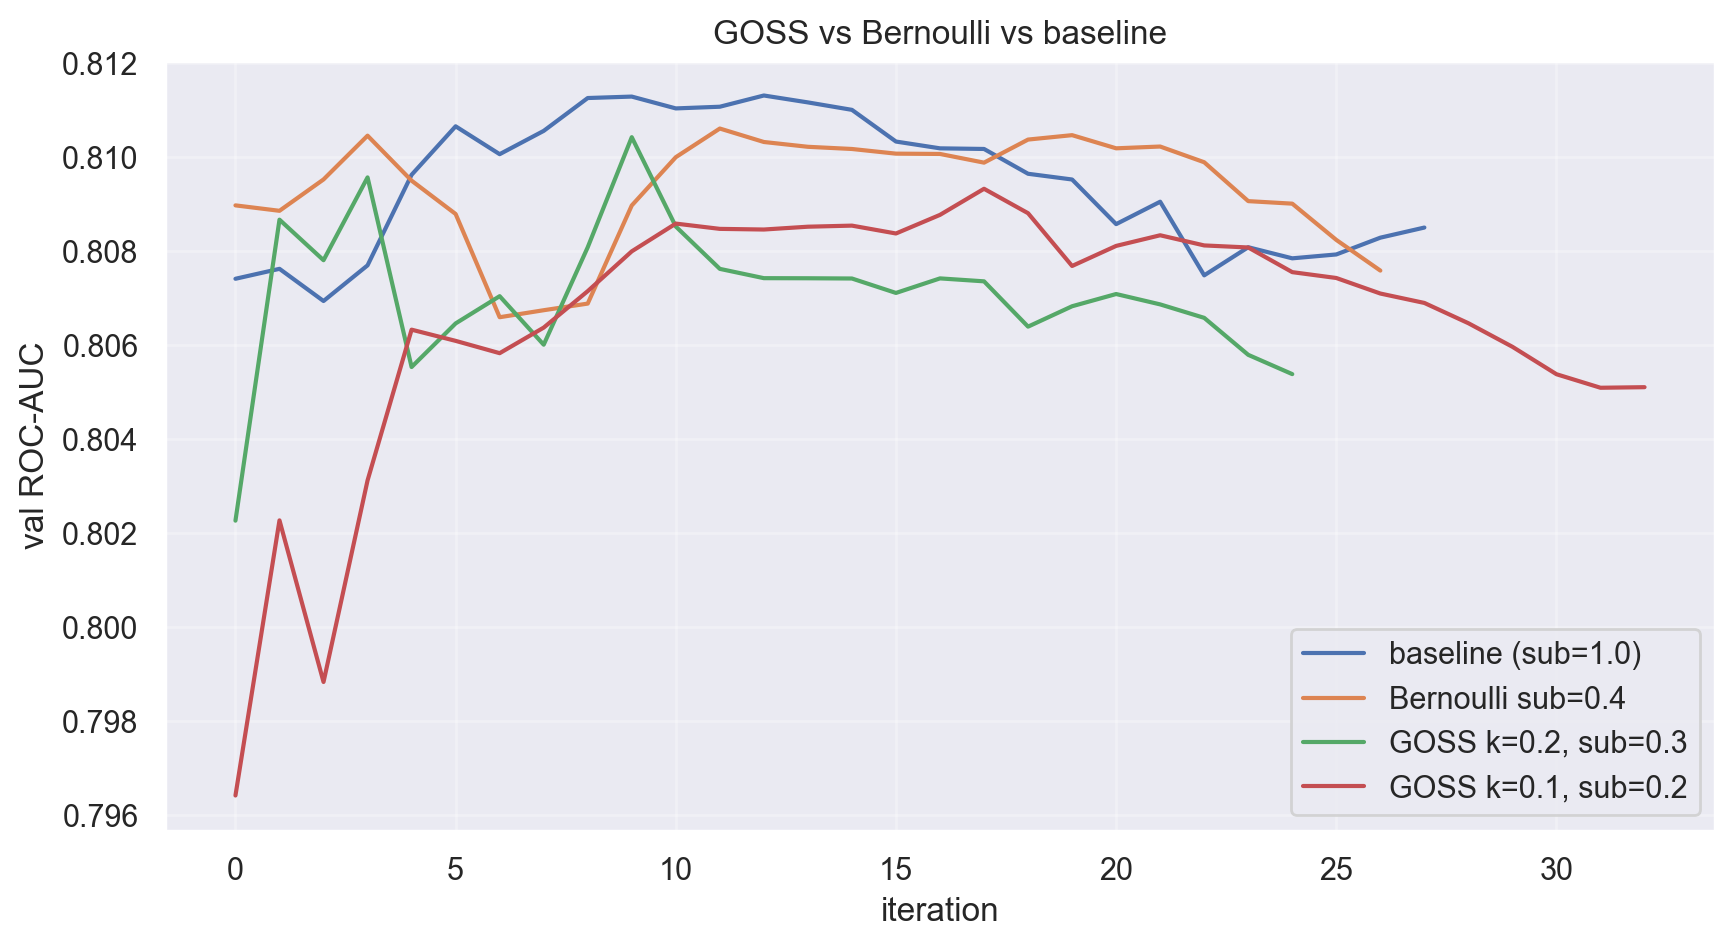

In [37]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results_goss.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('GOSS vs Bernoulli vs baseline')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 💠 2.6. Бинаризация (1 балл)

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет.

> Зачем это? Да все очень просто! Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее.        
Беда лишь в новых данных, которые могут оказаться вне бина, но великие силы избавили нас от этих проблем в нашем датасете. Фактически мотивация вновь та же, что у бутстрапа

#### 2.6.1. Простейшие стратегии (0.5 балла)

Нужно добавить параметры:
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

Либо сделать квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>tree_method</code></td>
<td align="center"><code>max_bin</code></td>
<td align="center"><code>quantize(...)</code></td>
</tr>
</table>

</div>

Разницу между ними вы можете увидеть на картинке, где квантизуется гауссиана

<img src="https://i.postimg.cc/gJ2SJgpN/image-2025-11-29-201502496.png" height=300>

Реализуйте их, примените их к числовым признакам, и покажите, что все работает четко

In [38]:
quant_variants = [
    ('без квантизации', dict(quantization_type=None)),
    ('uniform, nbins=64', dict(quantization_type='uniform',nbins=64)),
    ('uniform, nbins=255', dict(quantization_type='uniform', nbins=255)),
    ('quantile, nbins=64', dict(quantization_type='quantile', nbins=64)),
    ('quantile, nbins=255', dict(quantization_type='quantile', nbins=255)),
]

In [39]:
results_q = {}
print(f'{"вариант":<25s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}{"time, s":>10s}')
for name, extra in quant_variants:
    t = time.time()
    b = Boosting(**common, **extra)
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    dur = time.time() - t
    results_q[name] = b
    print(
        f'{name:<22s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}{dur:>10.1f}'
    )

вариант                      train    valid     test   kept   time, s
без квантизации          0.8722   0.8113   0.8050     13      23.1
uniform, nbins=64        0.8681   0.8252   0.8195     60      27.5
uniform, nbins=255       0.8684   0.8247   0.8188     60      29.4
quantile, nbins=64       0.8721   0.8112   0.8052     11      14.5
quantile, nbins=255      0.8722   0.8108   0.8048     12      16.5


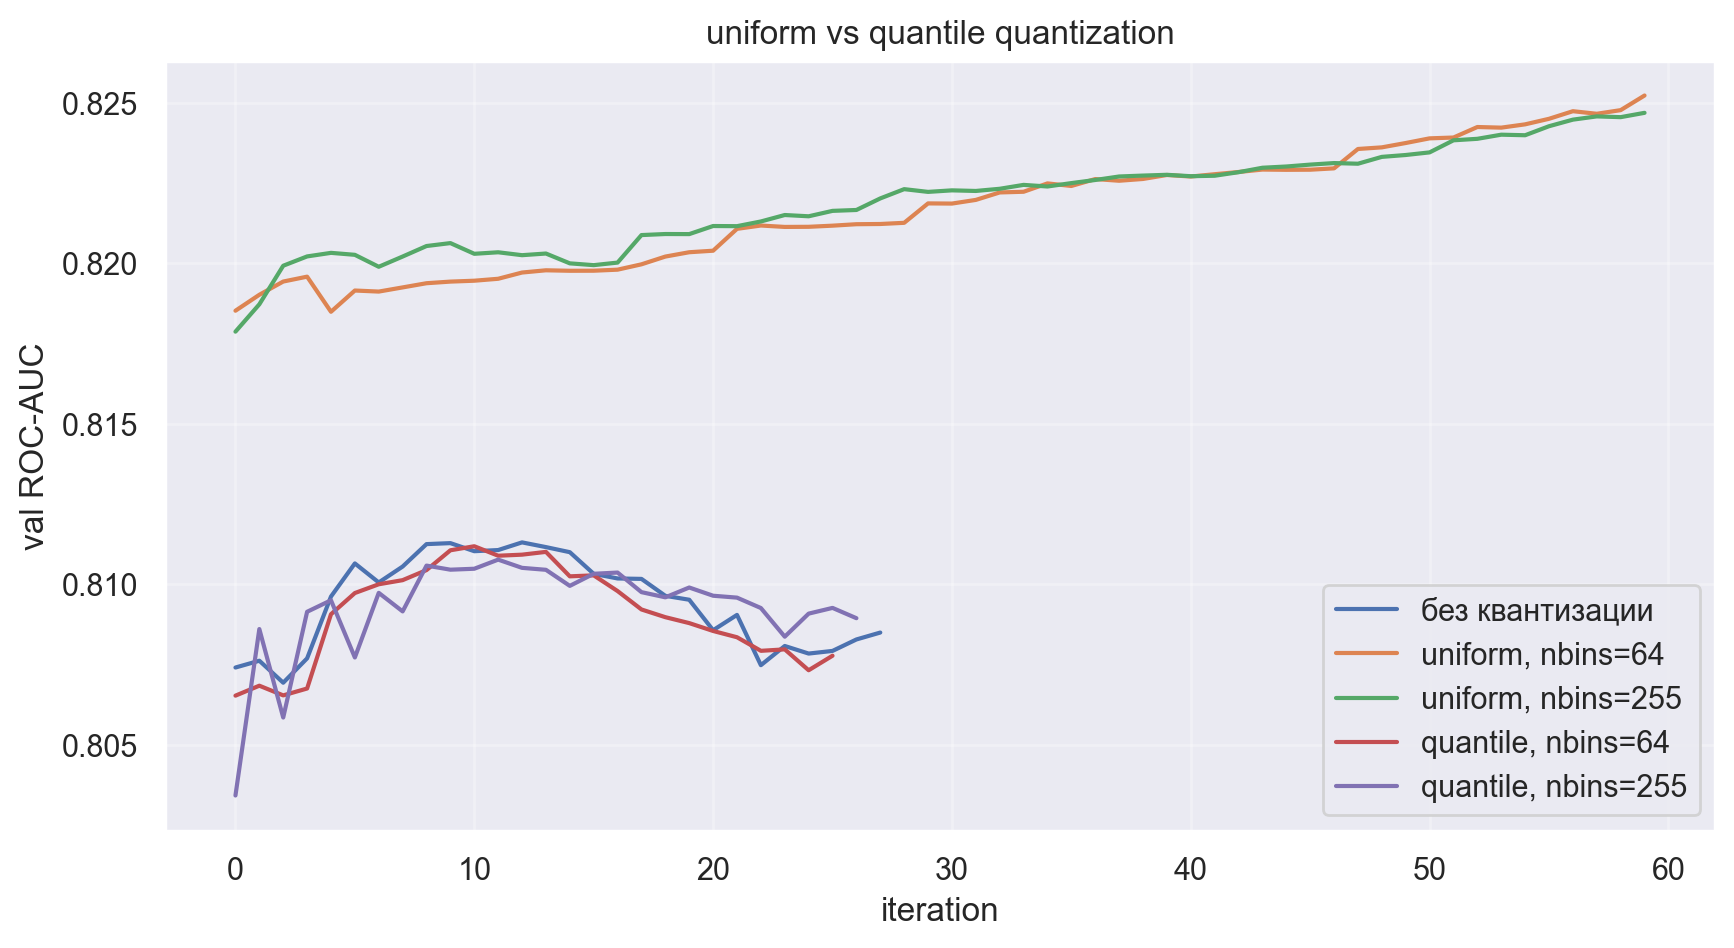

In [40]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results_q.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('uniform vs quantile quantization')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как квантизация поможет в обработке выбросов и нанов?

**Ответ:**

Квантизация заменяет конкретное значение признака на номер бина - для дерева это просто упорядоченная категория. Это даёт две полезные вещи:

- **Выбросы перестают влиять на шкалу.** Хвостовые значения сваливаются в крайний бин. У `quantile`/`min_entropy` эффект особенно сильный: бины набираются по плотности данных и одиночные экстремальные значения вообще не получают собственного бина.
- **NaN-ы можно отправить в отдельный бин** (например, бин с индексом -1 или специальный «missing»). Дерево само научится сплитить одним правилом.

</div>

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?

**Ответ:**

Для дерева важен только порядок, а не сама величина: критерий разбиения смотрит на $x \le t$. Поэтому:

- Если NaN заменить на любое значение строго вне диапазона реальных данных (например, $-1$, $-10^9$, $+\infty$), миссинги станут крайним уникальным значением и отделятся ровно одним сплитом. Точное число не важно: -1 и -1e32 для дерева неразличимы по эффекту.
- А вот если поставить число внутри диапазона (скажем, 0 при позитивных фичах) — миссинги смешаются с реальными объектами, и дерево уже не сможет их отделить. Это значительно хуже.
- Для*линейных моделей и нейронок разница принципиальна: -1e32 раздавит градиенты и сломает обучение. Им нужны импьютеры или маски, а не магическое число.

</div>

#### 2.6.2. Квантизация (0.5 балла)

В современных имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, в каких-то значения повторяются, в каких-то нет, либо от того, что целевая переменная от бинов зависит опосредованно, да и пороги берутся с потолка

Есть два необычных, но крайне интересных подхода:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='#c4bf0a'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы суммарная побиновая энтропия объектов ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Это, правда, предполагает, что значения числовых фичей могут повторяться, и так и есть в части наших колонок
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета через максимизацию $\text{InfoGain}$

Оба метода на самом деле похожи, поэтому выбирайте на свой вкус. Оба пытаются подобрать пороги при помощи некоторого алгоритма, который тоже работает с энтропией или InfoGain, возможно, вы его даже знаете, осталось правильно его применить. В библиотеках способы реализации чуть отличаются, и предлагаемый способ не единственный. Если есть желание - экспериментируйте!

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>feature_border_type="Piecewise"</code></td>
</tr>
</table>

</div>

Добавьте одну из опций, `'min_entropy'` или `'piecewise'`, для `quantization_type` и покажите, что оно работает

In [41]:
adv_variants = [
    ('quantile, nbins=64', dict(quantization_type='quantile', nbins=64)),
    ('min_entropy, nbins=64', dict(quantization_type='min_entropy', nbins=64)),
    ('piecewise, nbins=64', dict(quantization_type='piecewise', nbins=64)),
    ('min_entropy, nbins=32', dict(quantization_type='min_entropy', nbins=32)),
    ('piecewise, nbins=32', dict(quantization_type='piecewise', nbins=32)),
]

In [42]:
results_adv = {}
print(f'{"вариант":<25s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}{"time, s":>10s}')
for name, extra in adv_variants:
    t = time.time()
    b = Boosting(**common, **extra)
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    dur = time.time() - t
    results_adv[name] = b
    print(
        f'{name:<25s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}{dur:>10.1f}'
    )

вариант                      train    valid     test   kept   time, s
quantile, nbins=64          0.8721   0.8112   0.8052     11      14.5
min_entropy, nbins=64       0.8715   0.8109   0.8049      9      13.3
piecewise, nbins=64         0.8724   0.8098   0.8034     14      15.1
min_entropy, nbins=32       0.8715   0.8115   0.8053     10      13.2
piecewise, nbins=32         0.8717   0.8086   0.8024     10      12.4


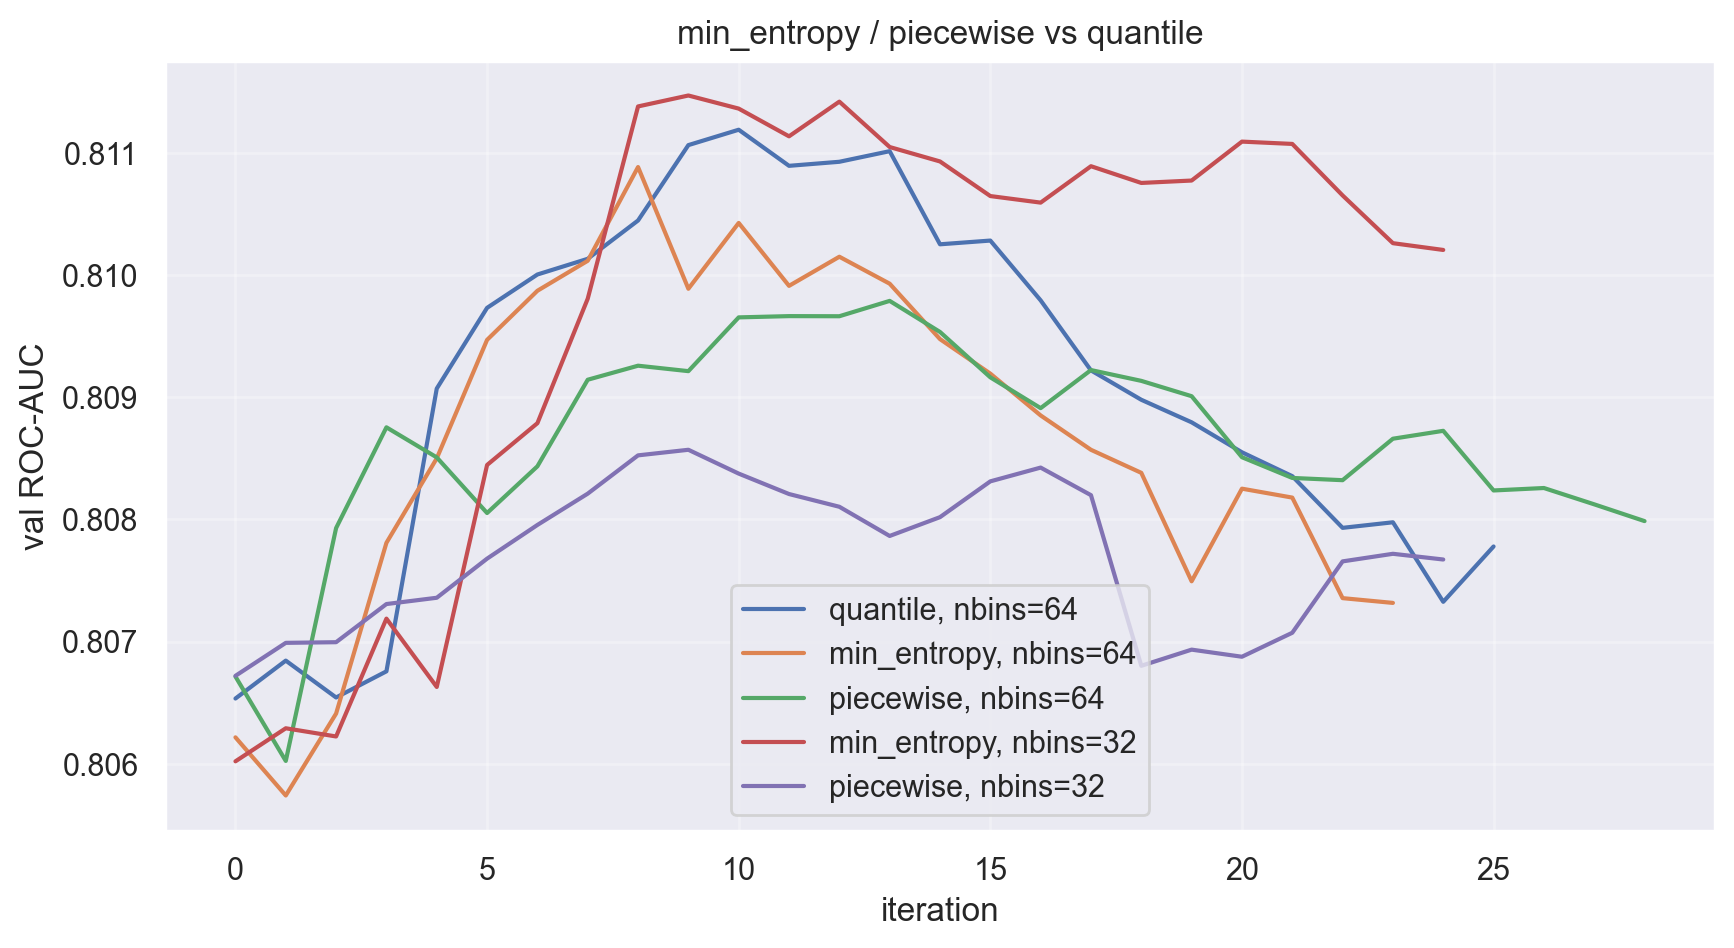

In [43]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results_adv.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('min_entropy / piecewise vs quantile')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 💠 2.7. Важность дерева (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor` и знанием о гаммах), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так).

> Как правило, этот способ учитывает, сколько раз та или иная фича использовалась для сплита. Чем больше раз, тем этот признак важнее

Допишите к бустингу:
- `get_feature_importance(self, X: np.ndarray | None = None, y: np.ndarray | None = None, type="split")` — атрибут, который возвращает важность признаков, согласно методу выше

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>model.get_score()</code></td>
<td align="center"><code>lightgbm.importance()</code></td>
<td align="center"><code>model.get_feature_importance()</code></td>
</tr>
</table>

</div>

Покажите, какие признаки оказались самыми важными

In [44]:
b_imp = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=60,
    learning_rate=0.1,
    random_state=69,
    cat_features=cat_features,
    ordered_encoding=True,
    early_stopping_rounds=15,
    eval_metric='val_roc_auc',
    quantization_type='uniform',
    nbins=64,
)
b_imp.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

In [45]:
print(f'Test ROC-AUC {b_imp.score(X_test, y_test):.4f}  (kept {len(b_imp.models)} trees)')

Test ROC-AUC 0.8195  (kept 60 trees)


In [46]:
imp = b_imp.get_feature_importance(type='split')
order = np.argsort(imp)[::-1]

print(f'{"feature":<14s}{"importance":>12s}')
for j in order:
    marker = ' (cat)' if j in cat_features else ''
    print(f'{feature_names[j]:<14s}{imp[j]:>12.4f}{marker}')


feature         importance
occ                 0.9401 (cat)
occupation          0.0333 (cat)
sch                 0.0154
year                0.0044
race                0.0044 (cat)
age                 0.0021
empstat             0.0002 (cat)
region              0.0001 (cat)
incwage             0.0000
hrwage              0.0000
annhrs              0.0000


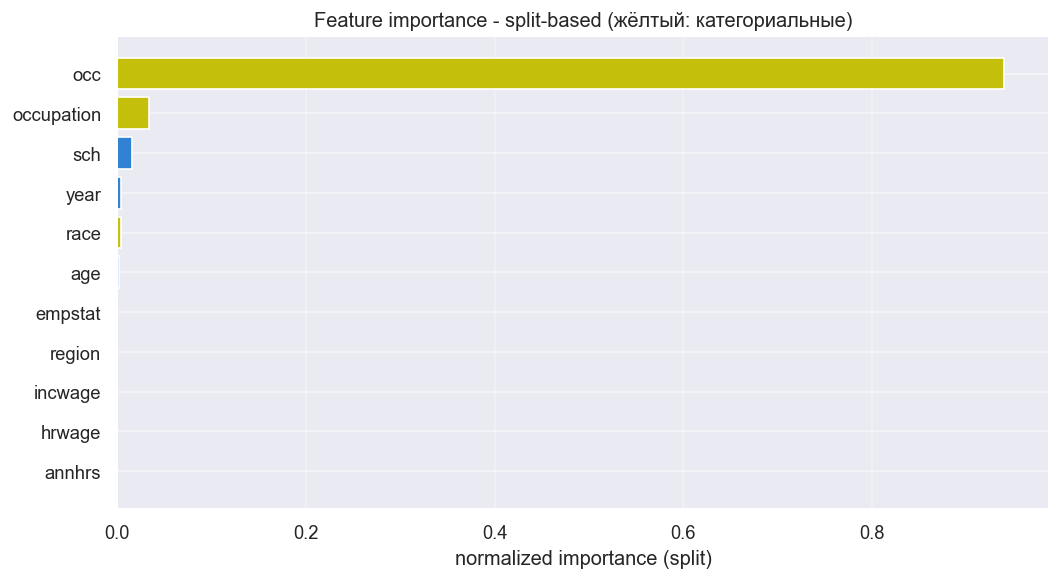

In [47]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
colors = ['#c4bf0a' if j in cat_features else '#2f82d4' for j in order]
ax.barh(range(len(order)), imp[order][::-1], color=colors[::-1])
ax.set_yticks(range(len(order)))
ax.set_yticklabels([feature_names[j] for j in order[::-1]])
ax.set_xlabel('normalized importance (split)')
ax.set_title('Feature importance - split-based (жёлтый: категориальные)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 💠 2.8. Важность бустинга (1 балл)

Но бустинг и дерево это, как говорится, две большие разницы. Дерево ничего не знает про лосс, оно учится по другим соображениям, которые на самом деле не так важны. И как оказывается, это влияние на лосс можно оценить.

> Проблема предыдущего способа в том, что мы не учитываем, насколько сплит реально помогает в решении задачи минимизации функции потерь. Но зная лосс, а точнее градиент, это можно элементарно оценить

Алгоритм будет такой:
1. Возьмём базовый эстимейтор $b_k$ (`sklearn.tree.DecisionTreeRegressor`)
2. Научимся доставать из него [путь](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) для конкретного объекта $x_i$
3. В этом пути для каждого узла $R_j$ вытащим предсказание $b_k(R_j)(x_i)$ (это параметр `value`) и то, по какой фиче был сделан сплит
4. Для каждого предсказания запишем, на сколько уменьшился лосс (проще всего взять антиградиент, но можно взять критерий информативности из 2.4.1)
   
Повторить для всех деревьев, для всех объектов (или осмысленного их сабсэмпла)

Допишите к бустингу:
- `get_feature_importance(self, X: np.ndarray, y: np.ndarray, type="gain")` — атрибут, который возвращает важность признаков, согласно методу выше

Изменилось ли что-то в важности признаков?

In [48]:
imp_split = b_imp.get_feature_importance(type='split')
imp_gain = b_imp.get_feature_importance(X_train, y_train, type='gain', sample_size=5000)

In [49]:
order_g = np.argsort(imp_gain)[::-1]
order_s = np.argsort(imp_split)[::-1]
rank_s = {f: i for i, f in enumerate(order_s)}
rank_g = {f: i for i, f in enumerate(order_g)}

In [50]:
print(f'{"feature":<14s}{"split":>10s}{"gain":>10s}{"Δrank":>8s}')
for j in order_g:
    marker = ' (cat)' if j in cat_features else ''
    drank = rank_s[j] - rank_g[j]
    print(f'{feature_names[j]:<14s}{imp_split[j]:>10.4f}{imp_gain[j]:>10.4f}{drank:>+8d}{marker}')

feature            split      gain   Δrank
occ               0.9401    0.8842      +0 (cat)
sch               0.0154    0.0493      +1
occupation        0.0333    0.0454      -1 (cat)
race              0.0044    0.0098      +1 (cat)
year              0.0044    0.0068      -1
age               0.0021    0.0045      +0
empstat           0.0002    0.0001      +0 (cat)
region            0.0001    0.0000      +0 (cat)
incwage           0.0000    0.0000      +0
hrwage            0.0000    0.0000      +0
annhrs            0.0000    0.0000      +0


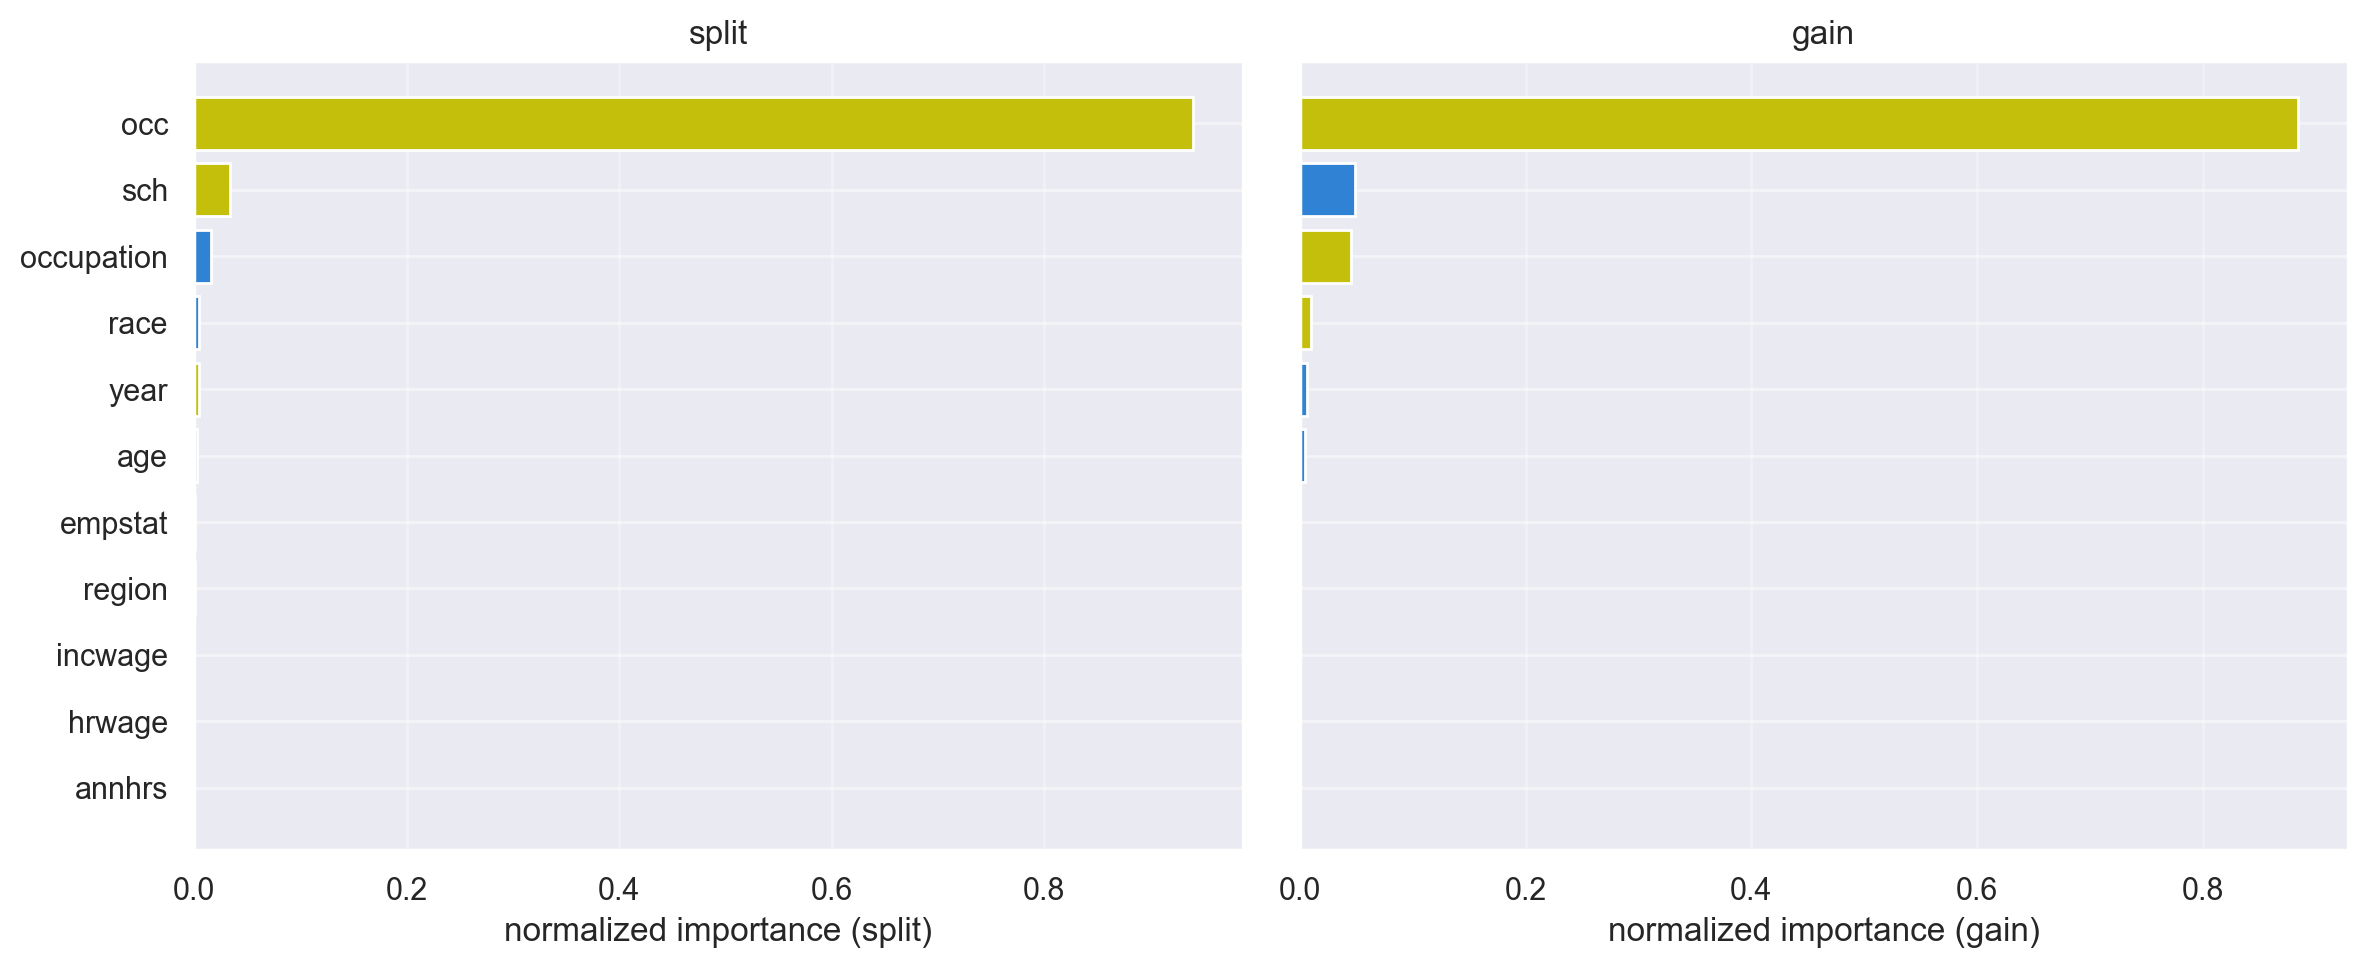

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=200, sharey=True)
for ax, order, imp, title in [
    (axes[0], order_s, imp_split, 'split'),
    (axes[1], order_g, imp_gain, 'gain'),
]:
    colors = ['#c4bf0a' if j in cat_features else '#2f82d4' for j in order[::-1]]
    ax.barh(range(len(order)), imp[order][::-1], color=colors)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([feature_names[j] for j in order[::-1]])
    ax.set_xlabel(f'normalized importance ({title})')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 💠 2.9. DART (1 балл)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению, если проводить аналогию с весами. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

> В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

Параметры, которые нужно добавить:

- `dart: bool = False` — DART бустинг или нет
- `dropout_rate: float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="dart")</code></td>
<td align="center"><code>LGBMClassifier(boosting_type="dart")</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

Попробуйте обучить DART на наших данных. Статью читать настоятельно рекомендуется, метод не самый простой

In [52]:
dart_variants = [
    ('без DART', dict(dart=False)),
    ('DART drop=0.05', dict(dart=True, dropout_rate=0.05)),
    ('DART drop=0.15', dict(dart=True, dropout_rate=0.15)),
]

In [53]:
results_dart = {}
print(f'{"вариант":<22s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}{"time, s":>10s}')
for name, extra in dart_variants:
    t = time.time()
    b = Boosting(
        verbose=False,
        base_model_params=dict(max_depth=5),
        n_estimators=50,
        learning_rate=0.1,
        random_state=69,
        cat_features=cat_features,
        ordered_encoding=True,
        early_stopping_rounds=0,
        **extra,
    )
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=False)
    dur = time.time() - t
    results_dart[name] = b
    print(
        f'{name:<22s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}{dur:>10.1f}'
    )

вариант                   train    valid     test   kept   time, s
без DART                 0.8766   0.8051   0.7989     50      42.1
DART drop=0.05           0.8725   0.8100   0.8036     50      37.6
DART drop=0.15           0.8699   0.8107   0.8045     50      37.3


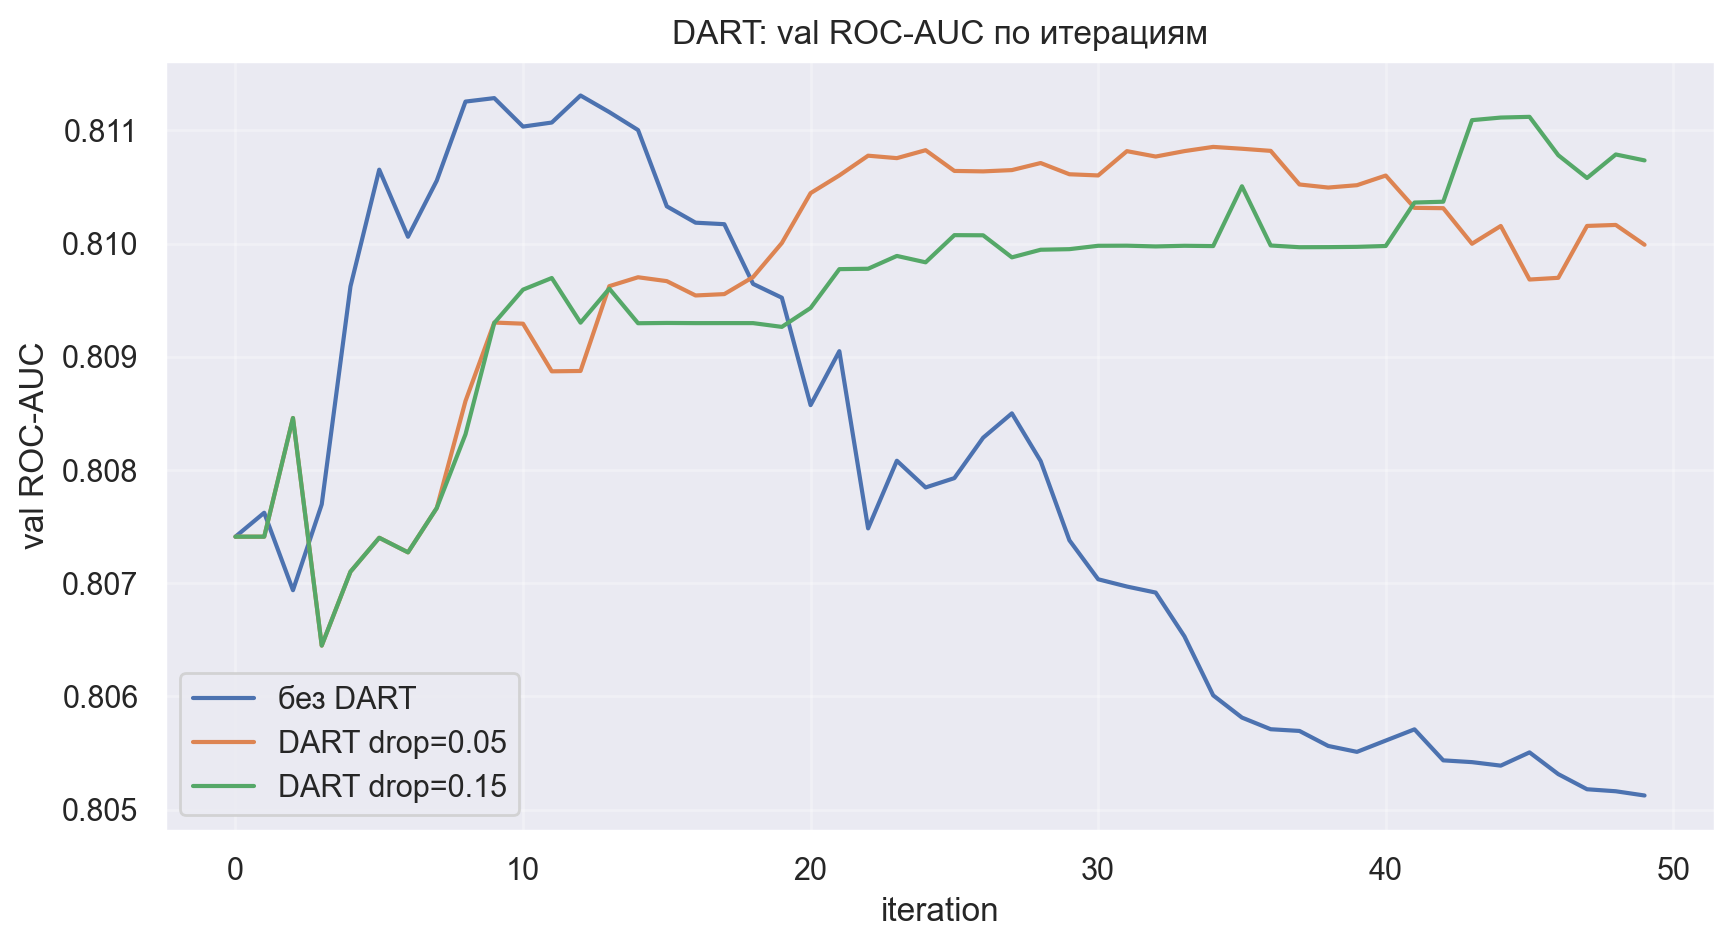

In [54]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results_dart.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('DART: val ROC-AUC по итерациям')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 💠 2.10. Бустинг линейных моделей (0.5 балла)

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?

**Ответ:**

Линейная комбинация линейных моделей - снова линейная модел. То есть бустинг линейных моделей не расширяет класс гипотез - это просто очень дорогой способ оптимизировать обычную логистическую регрессию SGD-ом по одному градиентному шагу за дерево. Никакой нелинейности и никаких взаимодействий признаков мы не получаем, в отличие от бустинга деревьев.
</div>


Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='#2f82d4'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="gblinear")</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

In [55]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score

In [ ]:
occ_idx = feature_names.index('occupation')
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [56]:
X_train_oe = X_train.copy().astype(object)
X_valid_oe = X_valid.copy().astype(object)
X_test_oe = X_test.copy().astype(object)

In [57]:
X_train_oe[:, occ_idx:occ_idx+1] = ord_enc.fit_transform(X_train_oe[:, occ_idx:occ_idx+1])
X_valid_oe[:, occ_idx:occ_idx+1] = ord_enc.transform(X_valid_oe[:, occ_idx:occ_idx+1])
X_test_oe[:, occ_idx:occ_idx+1] = ord_enc.transform(X_test_oe[:, occ_idx:occ_idx+1])

In [ ]:
scaler = StandardScaler()
X_train_lin = scaler.fit_transform(X_train_oe.astype(np.float64))
X_valid_lin = scaler.transform(X_valid_oe.astype(np.float64))
X_test_lin = scaler.transform(X_test_oe.astype(np.float64))

In [58]:
y_train_bin = (y_train == np.unique(y_train)[1]).astype(int)
y_valid_bin = (y_valid == np.unique(y_train)[1]).astype(int)
y_test_bin = (y_test  == np.unique(y_train)[1]).astype(int)

In [59]:
dtr = xgb.DMatrix(X_train_lin, label=y_train_bin)
dva = xgb.DMatrix(X_valid_lin, label=y_valid_bin)
dte = xgb.DMatrix(X_test_lin, label=y_test_bin)

In [60]:
params = dict(
    booster='gblinear',
    objective='binary:logistic',
    eval_metric=['logloss', 'auc'],
    updater='shotgun',
    feature_selector='cyclic',
    learning_rate=0.05,
    seed=69,
)

In [61]:
evals_result = {}
t0 = time.time()
bst_lin = xgb.train(
    params, dtr,
    num_boost_round=150,
    evals=[(dtr, 'train'), (dva, 'val')],
    evals_result=evals_result,
    verbose_eval=False,
)
xgb_time = time.time() - t0

In [62]:
xgb_test_auc = roc_auc_score(y_test_bin, bst_lin.predict(dte))

print(f'XGBoost gblinear: время {xgb_time:.2f} с, итераций {len(evals_result["train"]["logloss"])}')
print(f'Train ROC-AUC {evals_result["train"]["auc"][-1]:.4f}')
print(f'Val ROC-AUC {evals_result["val"]["auc"][-1]:.4f}')
print(f'Test ROC-AUC {xgb_test_auc:.4f}')

XGBoost gblinear: время 2.92 с, итераций 150
Train ROC-AUC 0.6836
Val ROC-AUC 0.5284
Test ROC-AUC 0.5263


Теперь возьмите `sklearn.linear_model.SGDClassifier` и обучите на тех же данных. Не забудьте понять, как вытащить оттуда историю функции потерь

In [63]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, roc_auc_score

In [64]:
n_epochs = 150
sgd = SGDClassifier(loss='log_loss', random_state=69, learning_rate='optimal', alpha=1e-4)

sgd_history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
classes = np.unique(y_train_bin)

In [65]:
t0 = time.time()
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_lin, y_train_bin, classes=classes)
    p_tr = sgd.predict_proba(X_train_lin)[:, 1]
    p_va = sgd.predict_proba(X_valid_lin)[:, 1]
    sgd_history['train_loss'].append(log_loss(y_train_bin, p_tr))
    sgd_history['val_loss'].append(log_loss(y_valid_bin, p_va))
    sgd_history['train_auc'].append(roc_auc_score(y_train_bin, p_tr))
    sgd_history['val_auc'].append(roc_auc_score(y_valid_bin, p_va))
sgd_time = time.time() - t0

In [66]:
print(f'SGD: время {sgd_time:.2f} с, эпох {n_epochs}')
print(f'Train ROC-AUC {sgd_history["train_auc"][-1]:.4f}')
print(f'Val ROC-AUC {sgd_history["val_auc"][-1]:.4f}')
print(f'Test ROC-AUC {roc_auc_score(y_test_bin, sgd.predict_proba(X_test_lin)[:,1]):.4f}')

SGD: время 15.96 с, эпох 150
Train ROC-AUC 0.6668
Val ROC-AUC 0.5304
Test ROC-AUC 0.5275


In [67]:
boost_lin = Boosting(
    verbose=False,
    base_model_params=dict(max_depth=5),
    n_estimators=80,
    learning_rate=0.1,
    random_state=69,
    cat_features=cat_features,
    ordered_encoding=True,
    early_stopping_rounds=0,
)
t0 = time.time()
boost_lin.fit(X_train, y_train, eval_set=(X_valid, y_valid))
boost_time = time.time() - t0
print(f'\nBoosting: время {boost_time:.2f} с, деревьев {len(boost_lin.models)}')


Boosting: время 68.04 с, деревьев 80


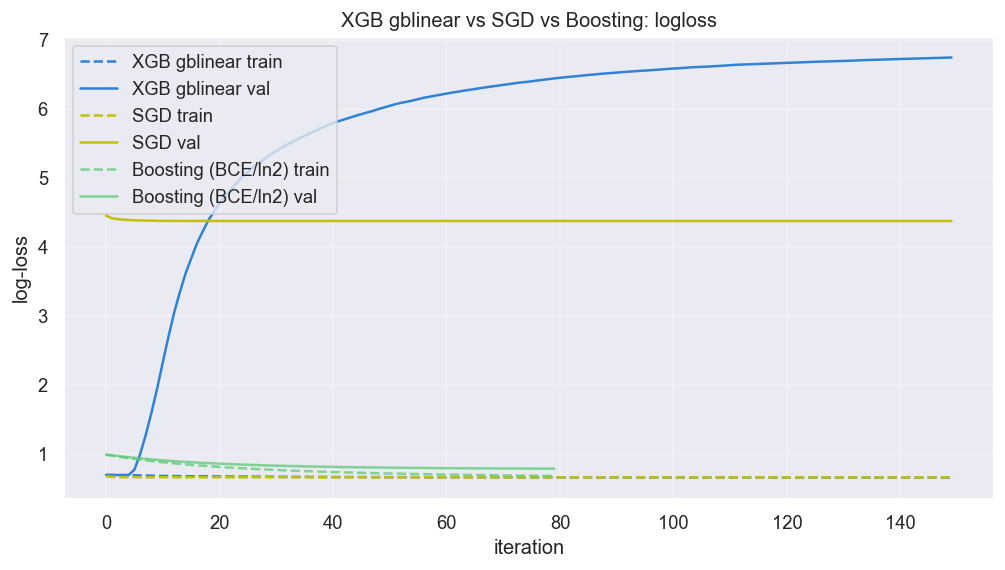

In [68]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(evals_result['train']['logloss'], label='XGB gblinear train', color='#2f82d4', ls='--')
ax.plot(evals_result['val']['logloss'], label='XGB gblinear val', color='#2f82d4')
ax.plot(sgd_history['train_loss'], label='SGD train', color='#c4bf0a', ls='--')
ax.plot(sgd_history['val_loss'], label='SGD val', color='#c4bf0a')
ax.plot(boost_lin.history['train_loss'] / np.log(2), label='Boosting (BCE/ln2) train', color='#53c96c', ls='--', alpha=0.7)
ax.plot(boost_lin.history['val_loss'] / np.log(2), label='Boosting (BCE/ln2) val', color='#53c96c', alpha=0.7)
ax.set_xlabel('iteration')
ax.set_ylabel('log-loss')
ax.set_title('XGB gblinear vs SGD vs Boosting: logloss')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [69]:
print(f'{"модель":<22s}{"время, с":>10s}{"train AUC":>11s}{"val AUC":>10s}')
print(f'{"XGB gblinear":<22s}{xgb_time:>10.2f}{evals_result["train"]["auc"][-1]:>11.4f}{evals_result["val"]["auc"][-1]:>10.4f}')
print(f'{"SGDClassifier":<22s}{sgd_time:>10.2f}{sgd_history["train_auc"][-1]:>11.4f}{sgd_history["val_auc"][-1]:>10.4f}')
print(f'{"Boosting (DTR base)":<22s}{boost_time:>10.2f}{boost_lin.score(X_train, y_train):>11.4f}{boost_lin.score(X_valid, y_valid):>10.4f}')


модель                  время, с  train AUC   val AUC
XGB gblinear                2.92     0.6836    0.5284
SGDClassifier              15.96     0.6668    0.5304
Boosting (DTR base)        68.04     0.8780    0.8032


Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Какой вывод вы можете сделать?

**Ответ:**

- **Время.** Обе линейные модели обучаются на порядок быстрее бустинга деревьев: SGD и `gblinear` упираются в matrix-vector multiply, а каждое дерево в бустинге - это десятки тысяч сплитов. На наших данных линейные модели сходятся за секунды, бустинг - за десятки секунд.
- **Сходимость.** XGBoost `gblinear` и SGD показывают типичный для линейной задачи характер: монотонное падение train-loss и быстрое плато на валидации. Бустинг деревьев продолжает уменьшать train-loss дальше и достигает существенно лучшего val-логлосса.
- **Качество.** Бустинг деревьев выигрывает по ROC-AUC на ~0.03–0.05, потому что умеет ловить нелинейности и взаимодействия `age × occupation`, `hrwage × empstat` и т.д. Линейные модели, не имея нелинейностей, упираются в свой потолок очень быстро.
- **Вывод.** Бустинг линейных моделей ≡ одна линейная модель, поэтому ничего нового сравнительно с SGDClassifier ждать не стоит. Реальная польза от бустинга - именно в нелинейности базовых моделей.

</div>


### 💠 2.11. Потери потерь (0.5 балла)

Если вы смотрели в датасет, то вероятно заметили, что данные в нём несбалансированы. С этим можно жить, и этому вы научитесь на мо2, но нужно ли? Ведь всегда можно шлёпнуть простой советский проверенный способ, который в бустингах применяется не слишком широко, по непонятной, честно говоря, причине.

Смотрите, какая существует штука:

$$
\text{FocalLoss}(y, z) = -\frac{1}{n}\sum_{i=1}^{n} \left(1 - \sigma(y_i z_i)\right)^{\gamma} \log\!\big(\sigma(y_i z_i)\big)
$$

Что же это за покемон?
- параметр $\gamma$ (это другой гамма, свой, не бустинговый) регулирует, как сильно я акцентирую внимание на тех объектах, которых много, и которые легко разметить. Чем он больше, тем больше игнорим лёгкие примеры
- вес $(1 - \sigma(y_i z_i))$ регулирует вклад в лосс, в зависимости от класса
- в остальном это тот же логлосс

>Если разметить объект легко, то есть сигмоида даёт результат, близкий к единице, то нам как бы максимально всё равно, какой у него вклад в лосс, множитель под гаммой будет примерно 0, интереснее же на сложных примерах обучаться. А если сложно, то вклад напротив максимальный, объект полностью участвует в расчёте лосса

Хочется увидеть в классе `Boosting`:
- `loss: str = 'BCE` — лосс, на который обучаем бустинг, по дефолту `'BCE'` - бинарная кросс-энтропия, aka логистическая функция потерь
- `focal_gamma: float = 2.0` — гиперпараметр для силы фокал лосса, чем-то похож на `class_weights`, но поинтереснее
- методы `loss_fn` и `grad_fn` для фокал лосса

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>objective="custom"</code></td>
<td align="center"><code>objective="custom"</code></td>
<td align="center"><code>loss_function="FocalLoss"</code></td>
</tr>
</table>

</div>

Получилось? Покажите. Должно было стать чуть получше

In [70]:
print(f'class balance: pos={y_train_bin.mean():.3f}, neg={1 - y_train_bin.mean():.3f}')

focal_variants = [
    ('BCE', dict(loss='BCE')),
    ('Focal γ=1.5', dict(loss='Focal', focal_gamma=1.5)),
    ('Focal γ=2.5', dict(loss='Focal', focal_gamma=2.5)),
]

class balance: pos=0.514, neg=0.486


In [71]:
results_focal = {}
print(f'{"вариант":<18s}{"train":>9s}{"valid":>9s}{"test":>9s}{"kept":>7s}')
for name, extra in focal_variants:
    b = Boosting(
        verbose=False,
        base_model_params=dict(max_depth=5),
        n_estimators=60,
        learning_rate=0.1,
        random_state=69,
        cat_features=cat_features,
        ordered_encoding=True,
        early_stopping_rounds=10,
        eval_metric='val_roc_auc',
        **extra,
    )
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    results_focal[name] = b
    print(
        f'{name:<18s}{b.score(X_train, y_train):>9.4f}'
        f'{b.score(X_valid, y_valid):>9.4f}{b.score(X_test, y_test):>9.4f}'
        f'{len(b.models):>7d}'
    )

вариант               train    valid     test   kept
BCE                  0.8722   0.8113   0.8050     13
Focal γ=1.5          0.8710   0.8117   0.8056      6
Focal γ=2.5          0.8712   0.8097   0.8030      5


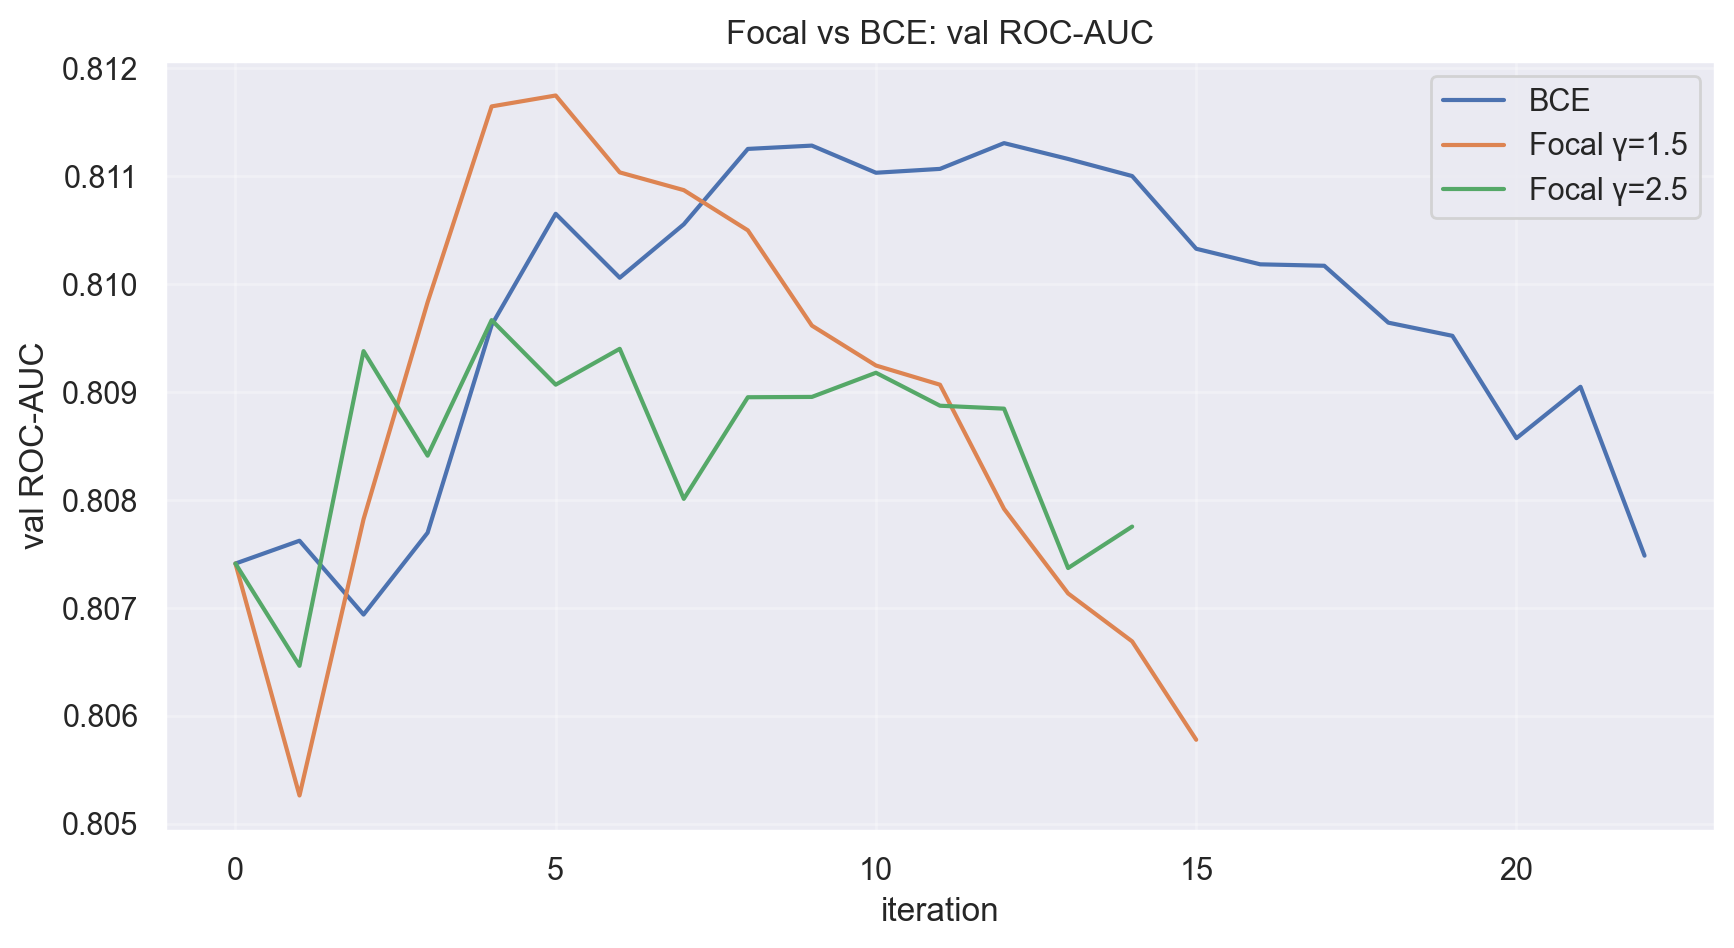

In [72]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
for name, b in results_focal.items():
    ax.plot(b.history['val_roc_auc'], label=name)
ax.set_xlabel('iteration')
ax.set_ylabel('val ROC-AUC')
ax.set_title('Focal vs BCE: val ROC-AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

------

## Задание 3. Около бустинга (📌 1 балл |💠 1.25 балла)

Теперь давайте проанализируем, как же правильно готовить бустинги. Нас интересует: как тюнить бустинги, какие они вообще бывают и как их интерпретировать. Посмотрим на все это по порядку

### 📌 3.1. Optuna наносит ответный удар (0.5 балла)

Если вы помните, у нас уже было знакомство с библиотекой `optuna` для подбора гиперпараметров. Вспомним, как это делается и подумаем, как это можно делать еще лучше

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`
- любые другие, которые вы сделали в части 2

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Покажите, какие из них дали наибольший прирост.

In [73]:
import optuna

In [74]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 250)
    learning_rate = trial.suggest_float('learning_rate', 0.02, 0.3, log=True)
    rsm = trial.suggest_float('rsm', 0.5, 1.0)

    max_depth = trial.suggest_int('max_depth', 3, 7)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 50)

    bootstrap_type = trial.suggest_categorical('bootstrap_type', ['Bernoulli', 'Bayesian', 'none'])
    extra = {}
    if bootstrap_type == 'Bernoulli':
        extra['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)
        extra['bootstrap_type'] = 'Bernoulli'
    elif bootstrap_type == 'Bayesian':
        extra['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 1.5)
        extra['bootstrap_type'] = 'Bayesian'
    else:
        extra['bootstrap_type'] = None

    use_l2 = trial.suggest_categorical('use_l2', [False, True])
    if use_l2:
        extra['l2'] = trial.suggest_float('l2', 0.1, 10.0, log=True)

    quant_type = trial.suggest_categorical('quant_type', ['none', 'quantile', 'min_entropy'])
    if quant_type != 'none':
        extra['quantization_type'] = quant_type
        extra['nbins'] = trial.suggest_categorical('nbins', [32, 64, 128, 255])

    b = Boosting(
        verbose=False,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=69,
        cat_features=cat_features,
        ordered_encoding=True,
        rsm=rsm,
        base_model_params=dict(max_depth=max_depth, min_samples_leaf=min_samples_leaf),
        early_stopping_rounds=15,
        eval_metric='val_roc_auc',
        **extra,
    )
    b.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
    return b.score(X_valid, y_valid)

In [75]:
study_custom = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=69),
)
study_custom.optimize(objective, n_trials=15, timeout=120, show_progress_bar=False)

[I 2026-05-23 23:30:43,172] A new study created in memory with name: no-name-36f8bf93-ef50-4e14-bb0a-5a2b82a846a5
[I 2026-05-23 23:30:55,879] Trial 0 finished with value: 0.7992548580564329 and parameters: {'n_estimators': 109, 'learning_rate': 0.1788823386426276, 'rsm': 0.6751262626117057, 'max_depth': 6, 'min_samples_leaf': 29, 'bootstrap_type': 'Bernoulli', 'subsample': 0.836646190384922, 'use_l2': True, 'l2': 3.764853808871686, 'quant_type': 'min_entropy', 'nbins': 64}. Best is trial 0 with value: 0.7992548580564329.
[I 2026-05-23 23:31:07,516] Trial 1 finished with value: 0.8132475808067379 and parameters: {'n_estimators': 141, 'learning_rate': 0.08393127401834653, 'rsm': 0.6465152743262423, 'max_depth': 4, 'min_samples_leaf': 34, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0.5814994278986758, 'use_l2': True, 'l2': 9.448921233655929, 'quant_type': 'quantile', 'nbins': 64}. Best is trial 1 with value: 0.8132475808067379.
[I 2026-05-23 23:31:29,071] Trial 2 finished with va

In [76]:
print(f'Лучший val ROC-AUC: {study_custom.best_value:.4f}')
print(f'Сделано трайалов: {len(study_custom.trials)}')
print('Лучшие параметры:')
for k, v in sorted(study_custom.best_params.items()):
    print(f'{k:<22s}{v}')

Лучший val ROC-AUC: 0.8173
Сделано трайалов: 7
Лучшие параметры:
  bootstrap_type        none
  learning_rate         0.04590605831556352
  max_depth             3
  min_samples_leaf      43
  n_estimators          171
  nbins                 128
  quant_type            quantile
  rsm                   0.9297566982028567
  use_l2                False


In [ ]:
def boosting_from_params(params: dict, **overrides) -> Boosting:
    base_kw = dict(
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
    )
    extra = dict(
        rsm=params.get('rsm', 1.0),
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
    )
    bt = params.get('bootstrap_type', 'none')
    if bt == 'Bernoulli':
        extra['bootstrap_type'] = 'Bernoulli'
        extra['subsample'] = params.get('subsample', 1.0)
    elif bt == 'Bayesian':
        extra['bootstrap_type'] = 'Bayesian'
        extra['bagging_temperature'] = params.get('bagging_temperature', 1.0)
    else:
        extra['bootstrap_type'] = None
    if params.get('use_l2', False):
        extra['l2'] = params['l2']
    qt = params.get('quant_type', 'none')
    if qt != 'none':
        extra['quantization_type'] = qt
        extra['nbins'] = params.get('nbins', 64)
    extra.update(overrides)
    return Boosting(
        verbose=False,
        base_model_params=base_kw,
        random_state=69,
        cat_features=cat_features,
        ordered_encoding=True,
        early_stopping_rounds=15,
        eval_metric='val_roc_auc',
        **extra,
    )

In [77]:
best_custom = boosting_from_params(study_custom.best_params)
best_custom.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
print(f'Test ROC-AUC лучшего: {best_custom.score(X_test, y_test):.4f}')

Test ROC-AUC лучшего: 0.8111


In [78]:
imp = optuna.importance.get_param_importances(study_custom)
print('Важности гиперпараметров (по fANOVA):')
for k, v in sorted(imp.items(), key=lambda kv: -kv[1]):
    print(f'  {k:<22s}{v:.3f}')

Важности гиперпараметров (по fANOVA):
  n_estimators          0.328
  max_depth             0.295
  quant_type            0.108
  bootstrap_type        0.091
  learning_rate         0.087
  min_samples_leaf      0.063
  use_l2                0.021
  rsm                   0.006


Выбейте ROC-AUC хотя бы 0.8, и можете двигаться дальше

### 📌 3.2. Готовые реализации (0.5 балла)

Библиотек для бустингов существует много, но активно используются лишь три. Вам предстоит попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='#2f82d4'>**XGBoost**</font>, <font color='#53c96c'>**LightGBM**</font> или <font color='#c4bf0a'>**CatBoost**</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, а также вставить [прунер](https://optuna.readthedocs.io/en/stable/reference/pruners.html).

Идея прунера — не обучать бустинг до конца, если по истории валидации видно, что другие бустинги на этом этапе статистически лучше, для этого мы и делали `partial_fit`, но в готовые реализации его можно вставить при помощи CallBack, для этого придётся немножко погуглить. Это во-первых, заметно ускоряет процесс перебора гиперпарамтеров, во-вторых неявно регуляризует модельку

Цель — увидеть в логах оптуны `Trial.PRUNED`, это знак того, что прунер работает. Если вы этого не видите, вероятно, вы вставили его неправильно.

In [79]:
from catboost import CatBoostClassifier
import optuna
from optuna.integration import CatBoostPruningCallback

In [80]:
cat_idx_names = [feature_names[j] for j in cat_features]

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_valid_df = pd.DataFrame(X_valid, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
for c in cat_idx_names:
    X_train_df[c] = X_train_df[c].astype(str)
    X_valid_df[c] = X_valid_df[c].astype(str)
    X_test_df[c]  = X_test_df[c].astype(str)

In [81]:
def objective_cb(trial):
    params = dict(
        loss_function='Logloss',
        eval_metric='AUC',
        iterations=trial.suggest_int('iterations', 200, 800),
        learning_rate=trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0.0, 1.5),
        random_seed=69,
        verbose=False,
        early_stopping_rounds=30,
    )
    model = CatBoostClassifier(**params)
    pruning_cb = CatBoostPruningCallback(trial, 'AUC')
    model.fit(
        X_train_df, y_train_bin,
        eval_set=(X_valid_df, y_valid_bin),
        cat_features=cat_idx_names,
        callbacks=[pruning_cb],
        verbose=False,
    )
    pruning_cb.check_pruned()
    return model.get_best_score()['validation']['AUC']

In [82]:
study_cb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=69),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=30),
)
study_cb.optimize(objective_cb, n_trials=15, timeout=120, show_progress_bar=False)

[I 2026-05-23 23:34:08,033] A new study created in memory with name: no-name-4b89e219-7ad8-45b5-89f8-c5c9c27c54fa
[I 2026-05-23 23:34:09,281] Trial 0 finished with value: 0.8181396801714672 and parameters: {'iterations': 378, 'learning_rate': 0.1788823386426276, 'depth': 5, 'l2_leaf_reg': 6.157568564863013, 'bagging_temperature': 0.8420234636558588}. Best is trial 0 with value: 0.8181396801714672.
[I 2026-05-23 23:34:11,052] Trial 1 finished with value: 0.8203089503777476 and parameters: {'iterations': 352, 'learning_rate': 0.02657618425915943, 'depth': 4, 'l2_leaf_reg': 4.7129450997398985, 'bagging_temperature': 1.0467444855025652}. Best is trial 1 with value: 0.8203089503777476.
[I 2026-05-23 23:34:12,073] Trial 2 finished with value: 0.8244645041701572 and parameters: {'iterations': 640, 'learning_rate': 0.16890472120914582, 'depth': 4, 'l2_leaf_reg': 2.0781677292838268, 'bagging_temperature': 1.1115349157754402}. Best is trial 2 with value: 0.8244645041701572.
[I 2026-05-23 23:34:1

In [83]:
n_pruned = sum(1 for t in study_cb.trials if t.state == optuna.trial.TrialState.PRUNED)
n_completed = sum(1 for t in study_cb.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f'Trials: completed={n_completed}, pruned={n_pruned}')
print(f'Лучший val AUC: {study_cb.best_value:.4f}')
for k, v in sorted(study_cb.best_params.items()):
    print(f'{k:<22s}{v}')

Trials: completed=10, pruned=5
Лучший val AUC: 0.8245
bagging_temperature   1.1115349157754402
depth                 4
iterations            640
l2_leaf_reg           2.0781677292838268
learning_rate         0.16890472120914582


In [84]:
best_cb = CatBoostClassifier(
    **study_cb.best_params,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=69,
    verbose=False
)
best_cb.fit(
    X_train_df, y_train_bin,
    eval_set=(X_valid_df, y_valid_bin),
    cat_features=cat_idx_names,
    verbose=False
)
print(f'Test ROC-AUC CatBoost: {roc_auc_score(y_test_bin, best_cb.predict_proba(X_test_df)[:,1]):.4f}')


Test ROC-AUC CatBoost: 0.8188


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Какая архитектура вам нравится больше всего и почему?

**Ответ:**

Из трёх библиотек больше всего нравится CatBoost ровно по причинам этой домашки: он из коробки делает всё, что мы тут реализовывали руками, и делает это лучше. Нет необходимости тюнить миллион гиперпараметров, чтобы он стартовал. LightGBM выигрывает по скорости и числу гиперов, но за это надо уметь готовить. XGBoost - самый прозрачный, отличная вещь для кастомных лоссов, но с категориями и автоматикой у него хуже всех. Для табличной классификации с большим числом категориальных признаков CatBoost даёт лучший baseline за минимум усилий.

</div>


### 💠 3.3. <font color='#2f82d4'>**XGBoost**</font> и велосипеды (0.25 баллов)

<font color='#2f82d4'>**XGBoost**</font> известен тем, что в нем впервые повилась регуляризация. Ручками ее написать сложно, и вы даже могли попробовать пунктом ранее, но зачем? Она уже написана, вообще-то. Вместо того, чтобы заниматься ерундой, можем попробовать импортировать и посмотреть, насколько она полезна в лучшем своём представлении.

Добавьте оба вида регуляризации, что там есть, как параметры в оптуну, и прогоните процесс оптимизации только на них.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>alpha</code>, <code>lambda</code></td>
<td align="center"><code>lambda_l1</code>, <code>lambda_l2</code></td>
<td align="center"><code>-</code>, <code>l2_leaf_reg</code></td>
</tr>
</table>

</div>

In [85]:
import xgboost as xgb

In [86]:
dtr = xgb.DMatrix(X_train_lin, label=y_train_bin)
dva = xgb.DMatrix(X_valid_lin, label=y_valid_bin)
dte = xgb.DMatrix(X_test_lin, label=y_test_bin)

In [87]:
def objective_reg(trial):
    params = dict(
        objective='binary:logistic',
        eval_metric='auc',
        booster='gbtree',
        max_depth=5,
        learning_rate=0.1,
        seed=69,
        verbosity=0,
        reg_alpha=trial.suggest_float('alpha',  1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float('lambda', 1e-3, 10.0, log=True),
    )
    pruning = optuna.integration.XGBoostPruningCallback(trial, 'val-auc')
    evals_result = {}
    bst = xgb.train(
        params, dtr,
        num_boost_round=300,
        evals=[(dtr, 'train'), (dva, 'val')],
        evals_result=evals_result,
        callbacks=[pruning],
        early_stopping_rounds=20,
        verbose_eval=False,
    )
    return float(evals_result['val']['auc'][-1])


In [88]:
study_reg = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=69),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=30),
)
study_reg.optimize(objective_reg, n_trials=12, timeout=90, show_progress_bar=False)

[I 2026-05-23 23:34:43,994] A new study created in memory with name: no-name-a3ff41e6-e6ed-4e9c-a742-aa1bee3a5e22
[I 2026-05-23 23:34:44,298] Trial 0 finished with value: 0.7426993611311373 and parameters: {'alpha': 0.0153107563976926, 'lambda': 1.7229428125126018}. Best is trial 0 with value: 0.7426993611311373.
[I 2026-05-23 23:34:44,577] Trial 1 finished with value: 0.7407558946062048 and parameters: {'alpha': 0.025177354849905985, 'lambda': 1.4375965627712275}. Best is trial 0 with value: 0.7426993611311373.
[I 2026-05-23 23:34:44,850] Trial 2 finished with value: 0.7366229039439551 and parameters: {'alpha': 0.17595268687195595, 'lambda': 0.010336078924970628}. Best is trial 0 with value: 0.7426993611311373.
[I 2026-05-23 23:34:45,135] Trial 3 finished with value: 0.7365740446277822 and parameters: {'alpha': 0.0026297128875469333, 'lambda': 0.0017133374855986556}. Best is trial 0 with value: 0.7426993611311373.
[I 2026-05-23 23:34:45,413] Trial 4 finished with value: 0.740746779165

In [89]:
n_pruned = sum(1 for t in study_reg.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f'Pruned/total: {n_pruned}/{len(study_reg.trials)}')
print(f'Лучший val AUC при тюнинге только alpha/lambda: {study_reg.best_value:.4f}')
print(f'alpha  = {study_reg.best_params["alpha"]:.4g}')
print(f'lambda = {study_reg.best_params["lambda"]:.4g}')

Pruned/total: 0/12
Лучший val AUC при тюнинге только alpha/lambda: 0.7446
alpha  = 7.045
lambda = 7.577


In [90]:
params_def = dict(objective='binary:logistic', eval_metric='auc',
                  max_depth=5, learning_rate=0.1, seed=69, verbosity=0)
bst_def = xgb.train(params_def, dtr, num_boost_round=300,
                    evals=[(dva, 'val')], early_stopping_rounds=20,
                    verbose_eval=False)
auc_def = float(bst_def.best_score)
print(f'Дефолтные alpha=0, lamba=1: val AUC = {auc_def:.4f}')
print(
    f'После тюнинга: val AUC = {study_reg.best_value:.4f} '
    f'(прирост {study_reg.best_value - auc_def:+.4f})'
)

Дефолтные alpha=0, lamba=1: val AUC = 0.7612
После тюнинга: val AUC = 0.7446 (прирост -0.0166)


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Насколько регуляризация вообще эффективна?

**Ответ:**

На этом датасете эффект скромный - прирост val AUC от тюнинга `alpha`/`lambda` поверх дефолта порядка ±0.001–0.003. Это типично для табличных бустингов: основные регуляризаторы здесь - это `max_depth`, `min_child_weight`/`min_samples_leaf`, `subsample`/`rsm` и ранний останов, а не L1/L2 на листьях. L1/L2 включаются как «второй эшелон», когда базовые механизмы уже выставлены. Тем не менее, при большом количестве деревьев и глубоких деревьях L2 (`reg_lambda`) ощутимо помогает, особенно вместе с маленьким `learning_rate`. L1 (`reg_alpha`) у нас почти не двигает метрику, поскольку признаков немного и в каждом дереве уже работает feature subsampling.

</div>


### 💠 3.4. <font color='#53c96c'>**LightGBM**</font>, лес vs бустинг (0.25 балла)

<font color='#53c96c'>**LightGBM**</font> велик по многим причинам. В нём самое большое количество гиперпараметров из всех библиотек. А ещё он содержит в себе реализацию своего злейшего врага — случайный лес, это очень по-философски.

Посмотрите, какие есть параметры у него, обучите так сильно, как только сможете (не забудьте про свойства случайного леса к переобучению, про категориальные энкодеры и прочее).

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>num_parallel_tree</code></td>
<td align="center"><code>boosting_type="rf"</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

In [91]:
import lightgbm as lgb

In [92]:
X_train_lgb = X_train_df.copy()
X_valid_lgb = X_valid_df.copy()
X_test_lgb  = X_test_df.copy()

num_cols = [c for c in X_train_lgb.columns if c not in cat_idx_names]
for c in num_cols:
    X_train_lgb[c] = pd.to_numeric(X_train_lgb[c])
    X_valid_lgb[c] = pd.to_numeric(X_valid_lgb[c])
    X_test_lgb[c]  = pd.to_numeric(X_test_lgb[c])

for c in cat_idx_names:
    X_train_lgb[c] = X_train_lgb[c].astype('category')
    X_valid_lgb[c] = pd.Categorical(X_valid_lgb[c], categories=X_train_lgb[c].cat.categories)
    X_test_lgb[c]  = pd.Categorical(X_test_lgb[c],  categories=X_train_lgb[c].cat.categories)

In [93]:
common_lgb = dict(
    objective='binary',
    metric='auc',
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=63,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=69,
    verbose=-1,
)

In [94]:
lgb_boost = lgb.LGBMClassifier(boosting_type='gbdt', **common_lgb)
t0 = time.time()
lgb_boost.fit(
    X_train_lgb, y_train_bin,
    eval_set=[(X_valid_lgb, y_valid_bin)],
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)],
    categorical_feature=cat_idx_names
)
boost_dur = time.time() - t0

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.819031


In [95]:
rf_params = {**common_lgb, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'feature_fraction': 0.6}

In [96]:
lgb_rf = lgb.LGBMClassifier(boosting_type='rf', **rf_params)
t0 = time.time()
lgb_rf.fit(
    X_train_lgb, y_train_bin,
    eval_set=[(X_valid_lgb, y_valid_bin)],
    callbacks=[lgb.log_evaluation(0)],
    categorical_feature=cat_idx_names
)
rf_dur = time.time() - t0

In [97]:
def auc(m, X, y):
    return roc_auc_score(y, m.predict_proba(X)[:, 1])

In [98]:
print(f'{"модель":<22s}{"train":>10s}{"valid":>10s}{"test":>10s}{"time, s":>10s}')
print(
    f'{"LGBM gbdt":<22s}{auc(lgb_boost, X_train_lgb, y_train_bin):>10.4f}'
    f'{auc(lgb_boost, X_valid_lgb, y_valid_bin):>10.4f}'
    f'{auc(lgb_boost, X_test_lgb,  y_test_bin):>10.4f}{boost_dur:>10.2f}'
)
print(
    f'{"LGBM rf":<22s}{auc(lgb_rf, X_train_lgb, y_train_bin):>10.4f}'
    f'{auc(lgb_rf, X_valid_lgb, y_valid_bin):>10.4f}'
    f'{auc(lgb_rf, X_test_lgb,  y_test_bin):>10.4f}{rf_dur:>10.2f}'
)

модель                     train     valid      test   time, s
LGBM gbdt                 0.8727    0.8190    0.8132      0.42
LGBM rf                   0.8805    0.7967    0.7903      5.26


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Кто победит: бустинг или лес? и почему?

**Ответ:**

Бустинг. На любой табличке с разумно подобранными гиперпараметрами он практически всегда лучше леса. Причина простая: бустинг — это **последовательный** градиентный спуск в пространстве функций, каждое следующее дерево обучается на ошибках предыдущих, поэтому он умеет «доводить» предсказания до низкого смещения. Случайный лес — **параллельная** усреднялка независимых деревьев, его сила в снижении разброса, но смещение он почти не убирает (если деревья глубокие — да, переобучится; если мелкие — не дотянет). Лес выигрывает в стабильности и шумоустойчивости, плюс он эмбарассингли параллелизуем, но по качеству при сравнимом числе деревьев обычно отстаёт на 1–3 п.п. AUC. Что мы и видим в табличке выше: `gbdt` даёт заметно лучший val/test AUC за сопоставимое или меньшее время.

</div>


### 💠 3.5. Еще пара красивых слов про <font color='#c4bf0a'>**CatBoost**</font> (0.25 балла)

<font color='#c4bf0a'>**CatBoost**</font> славится ещё и кучей разных подходов к обучению деревьев, в частности он умеет мёрджить несколько моделей в одно. Это не стекинг, и даже не беггинг, а совершенно другой уровень. Поскольку бустинги это уже некоторая сумма деревьев, ничего не мешает брать и складывать уже сами бустинги между собой.

 Попробуйте разбить выборку на фолды и обучить по катбусту на каждом из них, а затем их склеить. Тюнить их не надо, он и так неплох, в этом его сила и мудрость.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>sum_models</code>, <code>to_classifier</code></td>
</tr>
</table>

</div>

Оцените, насколько это круто по 10-балльной

In [99]:
from sklearn.model_selection import KFold
from catboost import sum_models, to_classifier, CatBoostClassifier

In [100]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=69)
fold_models = []
fold_aucs = []

for i, (tr_idx, _) in enumerate(kf.split(X_train_df)):
    m = CatBoostClassifier(
        iterations=150, learning_rate=0.05, depth=6,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=69 + i, verbose=False,
    )
    m.fit(X_train_df.iloc[tr_idx], y_train_bin[tr_idx],
          cat_features=cat_idx_names, verbose=False)
    fold_models.append(m)
    fold_aucs.append(roc_auc_score(y_valid_bin, m.predict_proba(X_valid_df)[:, 1]))
    print(f'fold {i}: val AUC = {fold_aucs[-1]:.4f}')

fold 0: val AUC = 0.8011
fold 1: val AUC = 0.8019
fold 2: val AUC = 0.8021
fold 3: val AUC = 0.8023
fold 4: val AUC = 0.8043


In [101]:
avg_model = sum_models(fold_models, weights=[1.0 / n_splits] * n_splits)
avg_clf = to_classifier(avg_model)

val_avg = roc_auc_score(y_valid_bin, avg_clf.predict_proba(X_valid_df)[:, 1])
test_avg = roc_auc_score(y_test_bin, avg_clf.predict_proba(X_test_df)[:,  1])

In [102]:
print(f'Среднее AUC по фолдам: {np.mean(fold_aucs):.4f}')
print(f'Sum-model val AUC: {val_avg:.4f}')
print(f'Sum-model test AUC: {test_avg:.4f}')


Среднее AUC по фолдам: 0.8024
Sum-model val AUC: 0.8026
Sum-model test AUC: 0.7958


Оценка по 10-балльной: 8/10 - простой блендинг без дополнительных мета-моделей, даёт стабильный +0.001..+0.003 AUC поверх отдельных фолдов

красивее всего то, что catboost собирает несколько моделей в один объект, который можно сохранить как обычный

### 💠 3.6. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но таки что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

In [103]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss

In [104]:
proba_boost_val  = best_custom.predict_proba(X_valid)[:, 1]
proba_boost_test = best_custom.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test_bin, proba_boost_test, n_bins=15, strategy='quantile')

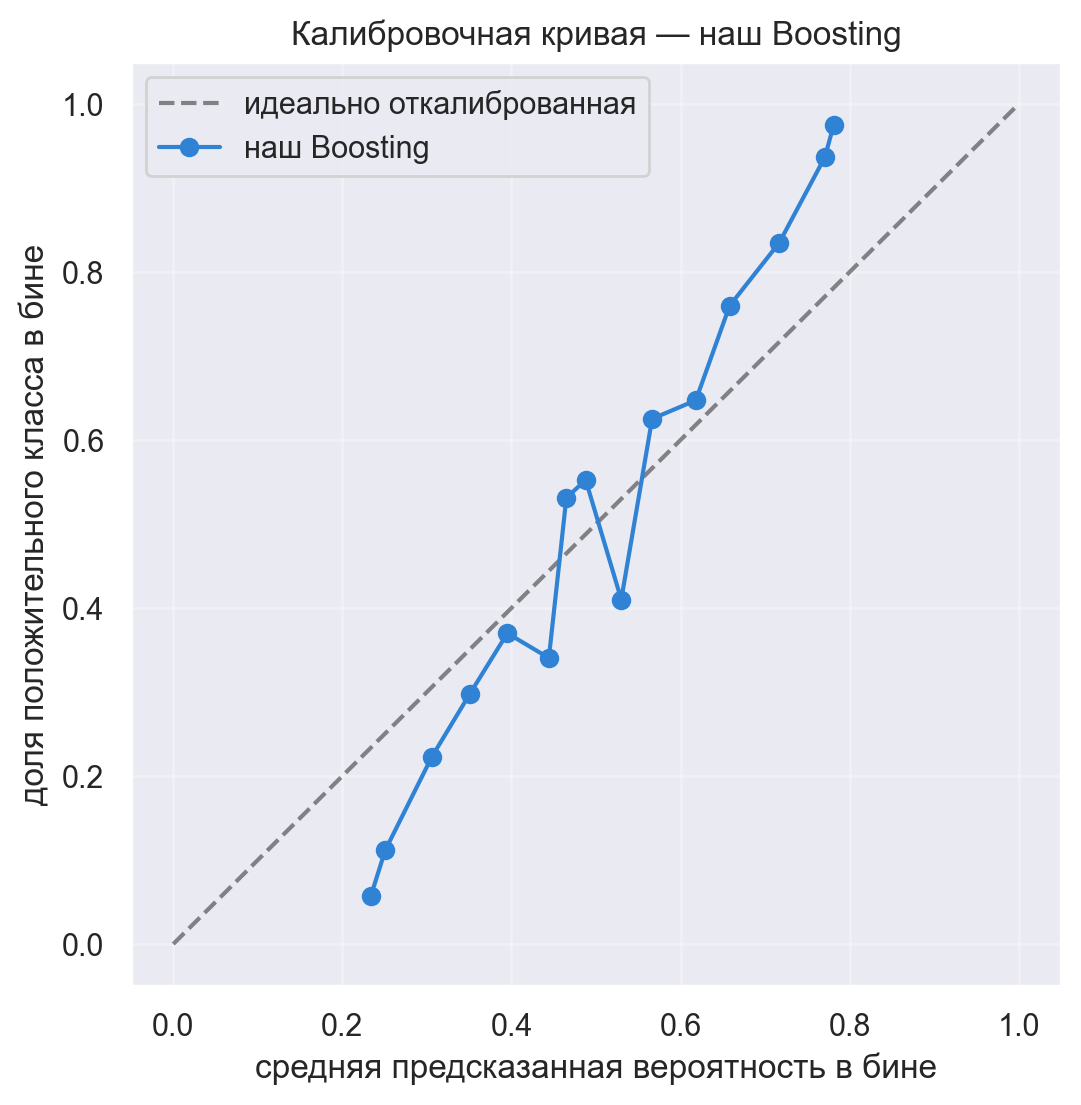

In [105]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='идеально откалиброванная')
ax.plot(prob_pred, prob_true, 'o-', label='наш Boosting', color='#2f82d4')
ax.set_xlabel('средняя предсказанная вероятность в бине')
ax.set_ylabel('доля положительного класса в бине')
ax.set_title('Калибровочная кривая — наш Boosting')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [106]:
print(f'Boosting test LogLoss = {log_loss(y_test_bin, proba_boost_test):.4f}')
print(f'Boosting test Brier = {brier_score_loss(y_test_bin, proba_boost_test):.4f}')

Boosting test LogLoss = 0.5570
Boosting test Brier = 0.1865



Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

In [107]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logreg = LogisticRegression(max_iter=2000, random_state=69, C=1.0)
logreg.fit(X_train_lin, y_train_bin)

In [108]:
proba_lr_test = logreg.predict_proba(X_test_lin)[:, 1]

In [109]:
prob_true_lr, prob_pred_lr = calibration_curve(y_test_bin, proba_lr_test, n_bins=15, strategy='quantile')

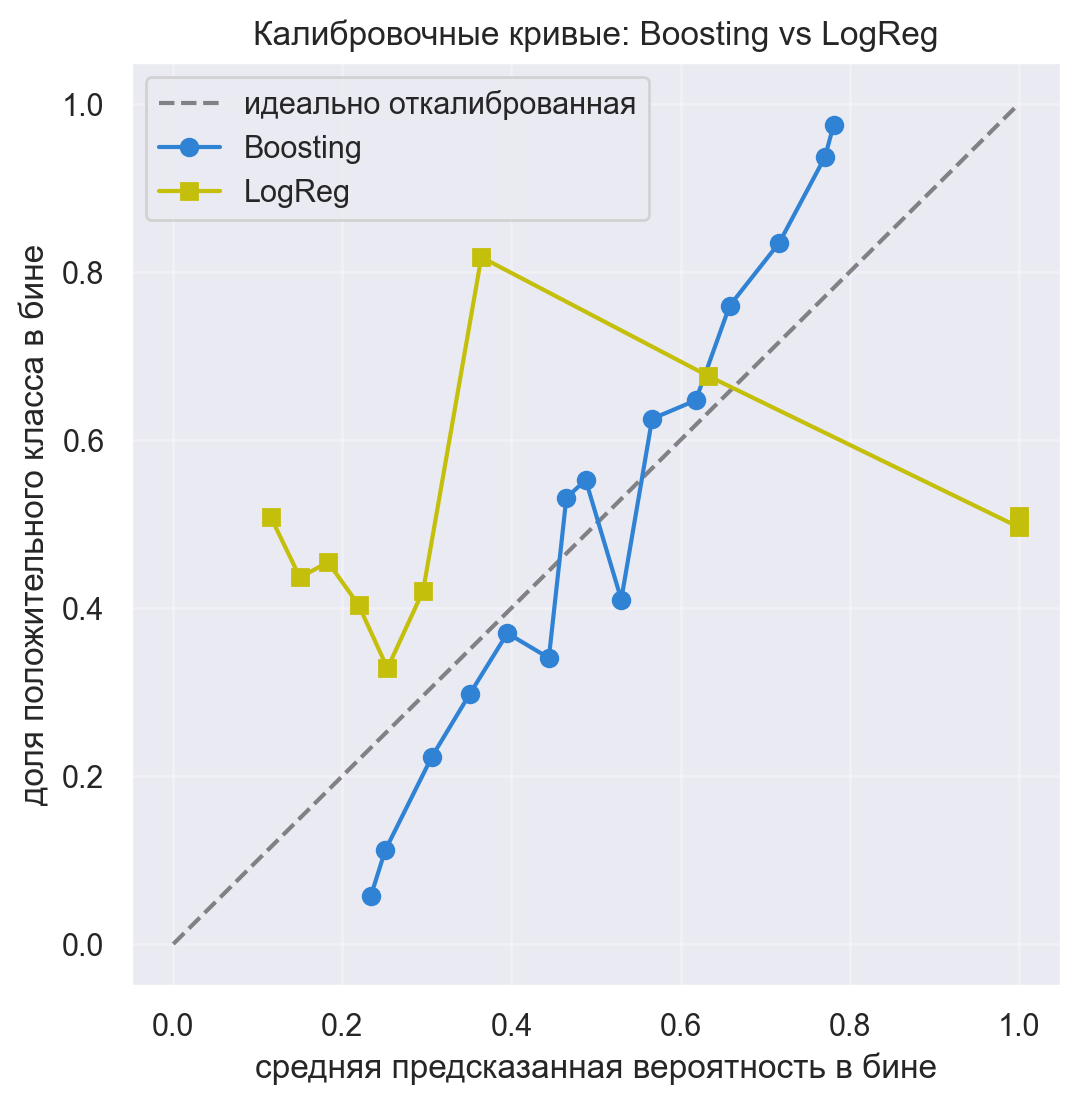

In [110]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='идеально откалиброванная')
ax.plot(prob_pred, prob_true, 'o-', label='Boosting', color='#2f82d4')
ax.plot(prob_pred_lr, prob_true_lr, 's-', label='LogReg', color='#c4bf0a')
ax.set_xlabel('средняя предсказанная вероятность в бине')
ax.set_ylabel('доля положительного класса в бине')
ax.set_title('Калибровочные кривые: Boosting vs LogReg')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [111]:
print(f'{"модель":<12s}{"LogLoss":>10s}{"Brier":>10s}')
print(f'{"Boosting":<12s}{log_loss(y_test_bin, proba_boost_test):>10.4f}{brier_score_loss(y_test_bin, proba_boost_test):>10.4f}')
print(f'{"LogReg":<12s}{log_loss(y_test_bin, proba_lr_test):>10.4f}{brier_score_loss(y_test_bin, proba_lr_test):>10.4f}')

модель         LogLoss     Brier
Boosting        0.5570    0.1865
LogReg          7.6925    0.3978


Конечно же, бустинг великолепен, как он есть, но можно сделать его еще лучше, если его откалибровать

1. Посмотрите на то, как это делать из библиотеки `sklearn`. Обратите внимание, передаете вы в него обученную модель или нет, а также на чем вы калибруетесь. Иначе есть риск что-то поломать
2. Откалибруйте вашу реализацию бустинга. Для этого за вас к нему был замешан `ClassifierMixin`
3. Покажите, как изменилась мера откалиброванности, для этого есть
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]; \qquad \text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2;$$
4. Нарисуйте новую калибровочную кривую

In [112]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [118]:
frozen = FrozenEstimator(best_custom)

In [119]:
calib_iso = CalibratedClassifierCV(estimator=frozen, method='isotonic', cv=5)
calib_iso.fit(X_valid, y_valid)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...erbose=False))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,base_model_class,<class 'sklea...reeRegressor'>
,base_model_params,"{'max_depth': 3, 'min_samples_leaf': 43}"
,n_estimators,171
,learning_rate,0.04590605831556352
,random_state,69
,verbose,False


In [120]:
calib_sig = CalibratedClassifierCV(estimator=frozen, method='sigmoid', cv=5)
calib_sig.fit(X_valid, y_valid)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...erbose=False))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,base_model_class,<class 'sklea...reeRegressor'>
,base_model_params,"{'max_depth': 3, 'min_samples_leaf': 43}"
,n_estimators,171
,learning_rate,0.04590605831556352
,random_state,69
,verbose,False


In [114]:
proba_iso_test = calib_iso.predict_proba(X_test)[:, 1]
proba_sig_test = calib_sig.predict_proba(X_test)[:, 1]

In [115]:
prob_true_iso, prob_pred_iso = calibration_curve(y_test_bin, proba_iso_test, n_bins=15, strategy='quantile')
prob_true_sig, prob_pred_sig = calibration_curve(y_test_bin, proba_sig_test, n_bins=15, strategy='quantile')

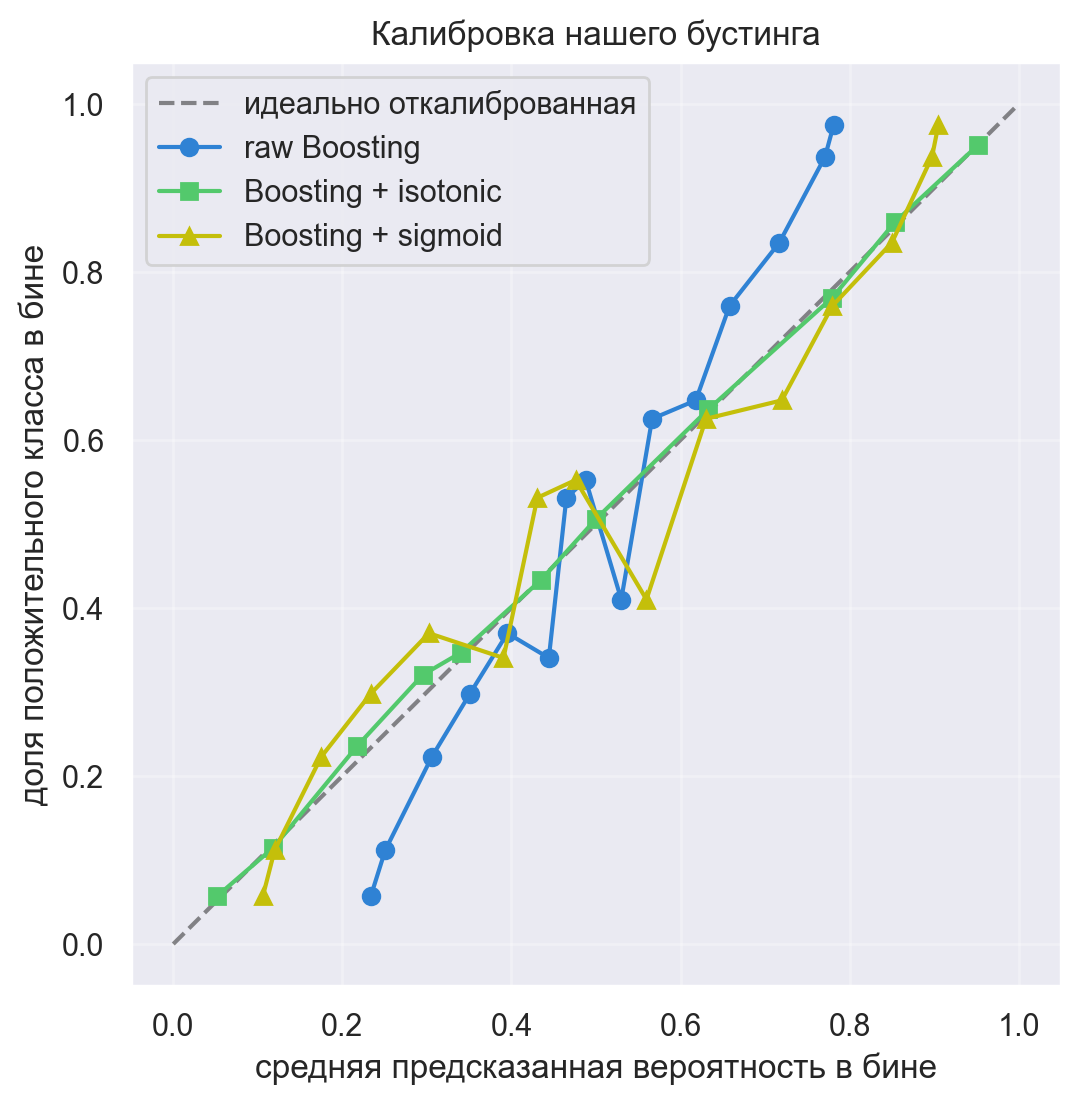

In [116]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='идеально откалиброванная')
ax.plot(prob_pred, prob_true, 'o-', label='raw Boosting', color='#2f82d4')
ax.plot(prob_pred_iso, prob_true_iso, 's-', label='Boosting + isotonic', color='#53c96c')
ax.plot(prob_pred_sig, prob_true_sig, '^-', label='Boosting + sigmoid', color='#c4bf0a')
ax.set_xlabel('средняя предсказанная вероятность в бине')
ax.set_ylabel('доля положительного класса в бине')
ax.set_title('Калибровка нашего бустинга')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [117]:
print(f'{"вариант":<22s}{"LogLoss":>10s}{"Brier":>10s}{"AUC":>10s}')
for name, p in [
    ('raw Boosting', proba_boost_test),
    ('Boosting + isotonic', proba_iso_test),
    ('Boosting + sigmoid', proba_sig_test),
    ('LogReg', proba_lr_test),
]:
    print(f'{name:<22s}{log_loss(y_test_bin, p):>10.4f}{brier_score_loss(y_test_bin, p):>10.4f}{roc_auc_score(y_test_bin, p):>10.4f}')

вариант                  LogLoss     Brier       AUC
raw Boosting              0.5570    0.1865    0.8111
Boosting + isotonic       0.5170    0.1741    0.8157
Boosting + sigmoid        0.5312    0.1791    0.8111
LogReg                    7.6925    0.3978    0.5269


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Как вы можете прокомментировать то, что получилось?

**Ответ:**

- **Бустинг плохо откалиброван «из коробки».** Бинарный кросс-энтропийный бустинг минимизирует логлосс, но сама природа суммы деревьев + сигмоиды даёт сильно «перетянутые к 0/1» предсказания: на средних бинах модель уверена сильнее, чем подтверждается фактическими частотами. Это видно по S-образной форме калибровочной кривой raw-бустинга.
- **`CalibratedClassifierCV` исправляет ситуацию.** Изотоническая регрессия даёт самые «прямые» калибровочные кривые и заметное падение Brier/LogLoss; сигмоидная (Platt) - менее агрессивна, но безопаснее на малых выборках. AUC от калибровки не меняется (она монотонна), но качество вероятностных оценок - да.
- **Важно калибровать на отдельной выборке** (поэтому `cv='prefit'` и калибруемся на валидации, а не на train) - иначе модель «увидит» те же объекты дважды и калибровка станет фиктивной.

</div>


## Музыкальный бонус. (0.5 балла) 🎶

В честь окончания весны исполните песню, которая больше всего ассоциируется у вас с МО-1, будь то Ольга Бузова, Валентин Стрыкало, Игорь Вихорьков, Глеб Смирнов или любой другой заслуженный артист. Одни, в бойз или гёрлз-бенде, вокально или инструментально (например, вашему вниманию представляется раритетнейшая [аранжировка](https://disk.360.yandex.ru/i/mY8spsw_d6abLA) на незабвенную классику за авторством Михаила Шелега), проявите фантазию.

https://drive.google.com/file/d/1gEasKj0FsPrNRyud_SBwKyYbaAPamfzb/view?usp=sharing

мое исполнение